# 02 — Data Cleaning

**Pipeline:** Tehran-only subset → type conversion → numeric imputation → non-numeric imputation

---

## Overview

This notebook consolidates **three successive cleaning stages** for the Tehran subset of the Divar dataset.

| Stage | Source notebook | What it does |
|---|---|---|
| A — Type conversion & normalisation | `1- TEHRAN - TABDIL.ipynb` | Convert Persian numerals → Arabic, parse dtypes, normalise strings |
| B — Numeric column imputation | `2- TEHRAN - FILL NUMBER COLUMNS.ipynb` | Impute & clip outliers in price, size, year, floor, rooms, … |
| C — Non-numeric column imputation | `3-TEHRAN- FILL ALL NON-NUMB COLUMNS.ipynb` | Handle categorical/binary columns, fill or drop remaining NaNs |

### Input
`../data/divar_tehran.csv` (produced by `01_eda.ipynb`)

### Output
`../data/divar_tehran_nonnum_filled_final.pkl` — clean, Tehran-only dataframe ready for modelling.

---


## Stage A — Type Conversion & Persian Numeral Normalisation

## تبدیل حروف و اعداد و ... به کاراکترهای مفهوم دار 
مثلا حروف فارسی به انگلیسی 
--
کلمه های اعداد به اعداد انگلیسی
--
اعداد فارسی به انگلیسی 
-

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\kourosh\Desktop\daqiqe Project\2\tehran.csv")

In [4]:
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
2,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,مشاور املاک,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
4,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,مشاور املاک,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر ب...,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ار...,مجانی,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.733952,51.380608,500.0


### 🗂️ توضیحات ویژگی‌های هر ستون

---

#### 🏷️ دسته‌بندی  
- **cat2_slug, cat3_slug:** شناسه‌های دسته‌بندی ملک  
- **property_type:** نوع ملک (آپارتمان، ویلا، زمین و...)  

---

#### 📍 موقعیت مکانی  
- **city_slug, neighborhood_slug:** شناسه‌های شهر و محله  
- **location_latitude, location_longitude:** مختصات جغرافیایی  
- **location_radius:** شعاع دقت موقعیت مکانی  

---

#### 📝 جزئیات آگهی  
- **created_at_month:** زمان ایجاد آگهی  
- **user_type:** نوع کاربر (شخصی، آژانس و...)  
- **description, title:** توضیحات و عنوان ملک  

---

#### 💰 اطلاعات مالی  
- **مربوط به اجاره:** rent_mode، rent_value، rent_to_single، rent_type  
- **مربوط به قیمت:** price_mode، price_value  
- **مربوط به رهن:** credit_mode، credit_value  
- **مقادیر تبدیل‌شده:** شاخص‌های مالی پردازش‌شده برای تحلیل  

---

#### 🏢 مشخصات ملک  
- **land_size, building_size:** متراژ زمین و بنا (متر مربع)  
- **deed_type, has_business_deed:** اطلاعات حقوقی و نوع سند  
- **floor, rooms_count, total_floors_count, unit_per_floor:** ساختار طبقات و تعداد واحدها  
- **construction_year, is_rebuilt:** سال ساخت و وضعیت بازسازی  

---

#### 🛋️ امکانات و ویژگی‌ها  
- **تأسیسات:** has_water، has_electricity، has_gas  
- **کنترل دما:** has_heating_system، has_cooling_system  
- **امکانات رفاهی:** has_balcony، has_elevator، has_warehouse، has_parking  
- **ویژگی‌های لوکس:** has_pool، has_jacuzzi، has_sauna  
- **سایر ویژگی‌ها:** has_security_guard، has_barbecue، building_direction، floor_material  

---

#### 🏨 اطلاعات اجاره کوتاه‌مدت  
- **regular_person_capacity, extra_person_capacity:** ظرفیت افراد معمول و اضافی  
- **cost_per_extra_person:** هزینه‌ی هر نفر اضافه  
- **تفاوت قیمت‌ها:** rent_price_on_regular_days، rent_price_on_special_days، rent_price_at_weekends  


In [5]:
df.isnull().sum()

cat2_slug                          0
cat3_slug                          0
city_slug                          0
neighborhood_slug                  0
created_at_month                   0
user_type                     111085
description                        0
title                              6
rent_mode                     106663
rent_value                    107275
rent_to_single                190900
rent_type                     155478
price_mode                     91453
price_value                    92209
credit_mode                   106663
credit_value                  107046
rent_credit_transform         106662
transformable_price           106704
transformable_credit          107049
transformed_credit            162606
transformable_rent            107291
transformed_rent              162606
land_size                     183980
building_size                   4203
deed_type                     132030
has_business_deed             186004
floor                          30354
r

In [6]:
(df == 0).sum()     

cat2_slug                         0
cat3_slug                         0
city_slug                         0
neighborhood_slug                 0
created_at_month                  0
user_type                         0
description                       0
title                             0
rent_mode                         0
rent_value                    18070
rent_to_single                    0
rent_type                         0
price_mode                        0
price_value                      21
credit_mode                       0
credit_value                    649
rent_credit_transform         71430
transformable_price           55754
transformable_credit            649
transformed_credit               39
transformable_rent            18057
transformed_rent               5806
land_size                         0
building_size                     0
deed_type                         0
has_business_deed              2740
floor                             0
rooms_count                 

In [7]:
(df == 0).mean() * 100  

cat2_slug                      0.000000
cat3_slug                      0.000000
city_slug                      0.000000
neighborhood_slug              0.000000
created_at_month               0.000000
user_type                      0.000000
description                    0.000000
title                          0.000000
rent_mode                      0.000000
rent_value                     9.465491
rent_to_single                 0.000000
rent_type                      0.000000
price_mode                     0.000000
price_value                    0.011000
credit_mode                    0.000000
credit_value                   0.339961
rent_credit_transform         37.416712
transformable_price           29.205255
transformable_credit           0.339961
transformed_credit             0.020429
transformable_rent             9.458681
transformed_rent               3.041319
land_size                      0.000000
building_size                  0.000000
deed_type                      0.000000


In [8]:
df["cat2_slug"].dropna().unique()

array(['residential-sell', 'residential-rent', 'commercial-rent',
       'commercial-sell', 'real-estate-services', 'temporary-rent'],
      dtype=object)

In [9]:
df["cat3_slug"].dropna().unique()

array(['apartment-sell', 'apartment-rent', 'office-rent', 'plot-old',
       'house-villa-rent', 'shop-rent', 'shop-sell',
       'industry-agriculture-business-rent', 'office-sell', 'presell',
       'house-villa-sell', 'suite-apartment', 'villa',
       'industry-agriculture-business-sell', 'partnership', 'workspace'],
      dtype=object)

In [10]:
# برای املاک مسکونی (فروش و اجاره)
df_residential = df[df["cat2_slug"].isin(['residential-sell', 'residential-rent'])].copy()
# برای املاک تجاری (فروش و اجاره)
df_commercial = df[df["cat2_slug"].isin(['commercial-rent', 'commercial-sell'])].copy()
# برای خدمات املاک و مستغلات (فروش و اجاره)
df_real_estate_services = df[df["cat2_slug"].isin(['real-estate-services'])].copy()
# برای اجاره موقت (فروش و اجاره)
df_temporary_rent = df[df["cat2_slug"].isin(['temporary-rent'])].copy()


In [11]:
print(df["cat2_slug"].value_counts())

cat2_slug
residential-sell        94541
residential-rent        67722
commercial-rent         16549
commercial-sell          6140
real-estate-services     4167
temporary-rent           1785
Name: count, dtype: int64


In [12]:
total_split = (
    len(df_residential)
    + len(df_commercial)
    + len(df_real_estate_services)
    + len(df_temporary_rent)
)

print("Total original:", len(df))
print("Total after split:", total_split)


Total original: 190904
Total after split: 190904


In [13]:
df_residential = df_residential.reset_index(drop=True)
df_commercial = df_commercial.reset_index(drop=True)
df_real_estate_services = df_real_estate_services.reset_index(drop=True)
df_temporary_rent = df_temporary_rent.reset_index(drop=True)

In [14]:
print("Residential:")
display(df_residential.head())

print("Commercial:")
display(df_commercial.head())

print("Real Estate Services:")
display(df_real_estate_services.head())

print("Temporary Rent:")
display(df_temporary_rent.head())


Residential:


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
2,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,مشاور املاک,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
3,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,مشاور املاک,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر ب...,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ار...,مجانی,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.733952,51.380608,500.0
4,residential-sell,plot-old,tehran,shahrak-naft-district5,2024-07-01 00:00:00,NaN,۷۰۰ متر باغ ۱۰۰ ساله،\nواقع در روستای زیبای رن...,تهاتر یا فروش باغی زیبا در روستای زیبای رندان,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.890186,51.280197,NaN


Commercial:


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,commercial-rent,shop-rent,tehran,tajrish,2024-05-01 00:00:00,مشاور املاک,تجریش،برِ اصلی\n\n 63 متر مغازه با بر ...,اجاره 63 متر مغازه ،، برِ تجریش,مقطوع,100001.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.804466,51.434441,500.0
2,commercial-sell,shop-sell,tehran,shahrak-e-kianshahr,2024-09-01 00:00:00,NaN,مغازه به متراژ ۲۵ متر در پاشاژ بورس طلا و لواز...,مغازه در پاساژ بورس طلا و لوازم آرایشی و بهداشتی,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,commercial-rent,office-rent,tehran,mirdamad,2024-05-01 00:00:00,مشاور املاک,نور و نقشه عالی \nدسترسی عالی \nامکانات کامل\n...,۴۰۰ متر/سند اداری/۳ پارکینگ,مقطوع,250000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.757763,51.440048,500.0
4,commercial-rent,industry-agriculture-business-rent,tehran,mobarak-abad-e-beheshti,2024-08-01 00:00:00,NaN,گاراژ۴۰۰متر واقع دردغاقله سرجاده اصلی تریلی رو...,گاراژ۴۰۰ متر,مقطوع,20000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.553528,51.349064,NaN


Real Estate Services:


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,real-estate-services,presell,tehran,chitgar-lake,2024-11-01 00:00:00,NaN,آیا به دنبال یک سرمایه‌گذاری پرسود و آینده‌دار...,پیشفروش تجاری+اداری از۳متربطوراقساط قطعی/المپی...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.750267,51.217346,NaN
1,real-estate-services,presell,tehran,chitgar,2024-06-01 00:00:00,NaN,بزرگ فکرکن،بزرگ بخواه\nنه خدا بخیله، نه تو لیا...,پیش فروش آپارتمان ۱۲۰ متر رویی اسکلت /در حال ساخت,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.725548,51.186935,NaN
2,real-estate-services,presell,tehran,sadeghiyeh,2024-08-01 00:00:00,مشاور املاک,✅انتخاب خود را به رخ بکشید\n\nکلید نخورده\nمتر...,۱۲۲متر ۳ خواب تکواحدی کلید نخورده,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,real-estate-services,presell,tehran,sheykh-al-raeis,2024-09-01 00:00:00,NaN,باسلام تعداد ۱۸ سهم از پروژه نگین پلاس پیروز...,پروژه نگین پیروزی,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.691803,51.455593,NaN
4,real-estate-services,presell,tehran,chitgar,2024-12-01 00:00:00,NaN,بسم الله الرحمن الرحیم \nفروش ویژه اختصاصی ، ل...,۶۰تا۱۵۰متر با وام/تهاتر/سند تک برگ/شریف/فول مش...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.726326,51.186737,NaN


Temporary Rent:


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,suite-apartment,tehran,sabalan,2024-05-01 00:00:00,مشاور املاک,سوئیت دارای واحد تک خواب (شروع قیمت از 700 ال...,اجاره سوییت آپارتمان مبله روزانه ماهانه,NaN,NaN,...,NaN,2.0,2,50000.0,700800.0,NaN,NaN,NaN,NaN,500.0
1,temporary-rent,suite-apartment,tehran,gomrok,2024-12-01 00:00:00,NaN,طبقه همکف با آسانسور و پارکینگ و دوربین \nکامل...,آپارتمان طبقه همکف,NaN,NaN,...,NaN,2.0,1,NaN,800000.0,NaN,800000.0,35.664257,51.397137,NaN
2,temporary-rent,villa,tehran,tehransar,2024-08-01 00:00:00,NaN,۵۰۰متر\n۱۲۰متربنا\n۲خواب مستر۱خواب مستر\nاستخر...,اجاره ویلا شیک,NaN,NaN,...,NaN,6.0,6,NaN,NaN,NaN,NaN,35.696205,51.257286,NaN
3,temporary-rent,suite-apartment,tehran,sadeghiyeh,2024-07-01 00:00:00,NaN,سلام به مهمان عزیز \nاجاره سوئیت روزانه، هفتگی...,اجاره سوئیت آپارتمان روزانه پارت تایم,NaN,NaN,...,NaN,2.0,2,NaN,NaN,NaN,NaN,35.722076,51.339268,500.0
4,temporary-rent,suite-apartment,tehran,poonak,2024-08-01 00:00:00,NaN,با سلام....\nامکان اجاره بصورت کوتاه مدت و بلن...,اجاره سوییت مبله در تمام مناطق تهران,NaN,NaN,...,NaN,8.0,8,NaN,NaN,NaN,NaN,35.777237,51.340244,NaN


In [15]:
obj_cols = df.select_dtypes(include="object").columns.tolist()
print("ستون‌های متنی (object):")
print(obj_cols)

ستون‌های متنی (object):
['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month', 'user_type', 'description', 'title', 'rent_mode', 'rent_to_single', 'rent_type', 'price_mode', 'credit_mode', 'rent_credit_transform', 'transformable_price', 'deed_type', 'has_business_deed', 'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt', 'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool', 'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type', 'extra_person_capacity']


In [16]:
def show_uniques_full(df, cols=None, max_per_col=20):
    """
    نمایش نوع داده، تعداد مقادیر یکتا، درصد مقادیر NaN، و چند مقدار نمونه از هر ستون
    """
    cols = cols or df.columns
    n = len(df)

    for c in cols:
        dtype = df[c].dtype
        unique_vals = df[c].dropna().unique()
        nan_count = df[c].isna().sum()
        nan_percent = round((nan_count / n) * 100, 2)

        print(f"\n🔹 ستون: {c}")
        print(f"نوع داده: {dtype}")
        print(f"تعداد مقادیر یکتا: {len(unique_vals)}")
        print(f"تعداد NaN: {nan_count}  ({nan_percent}%)")

        # نمایش چند مقدار نمونه (در صورت زیاد بودن، فقط max_per_col مورد اول)
        print("نمونه مقادیر:", unique_vals[:max_per_col])

In [17]:
show_uniques_full(df)


🔹 ستون: cat2_slug
نوع داده: object
تعداد مقادیر یکتا: 6
تعداد NaN: 0  (0.0%)
نمونه مقادیر: ['residential-sell' 'residential-rent' 'commercial-rent' 'commercial-sell'
 'real-estate-services' 'temporary-rent']

🔹 ستون: cat3_slug
نوع داده: object
تعداد مقادیر یکتا: 16
تعداد NaN: 0  (0.0%)
نمونه مقادیر: ['apartment-sell' 'apartment-rent' 'office-rent' 'plot-old'
 'house-villa-rent' 'shop-rent' 'shop-sell'
 'industry-agriculture-business-rent' 'office-sell' 'presell'
 'house-villa-sell' 'suite-apartment' 'villa'
 'industry-agriculture-business-sell' 'partnership' 'workspace']

🔹 ستون: city_slug
نوع داده: object
تعداد مقادیر یکتا: 1
تعداد NaN: 0  (0.0%)
نمونه مقادیر: ['tehran']

🔹 ستون: neighborhood_slug
نوع داده: object
تعداد مقادیر یکتا: 346
تعداد NaN: 0  (0.0%)
نمونه مقادیر: ['gholhak' 'tohid' 'elahiyeh' 'dardasht' 'gisha' 'shahrak-naft-district5'
 'kamraniyeh' 'shemiran-no' 'majidiyeh' 'west-tehranpars' 'tehran-kerman'
 'abouzar' 'ekhtiyariyeh' 'fallah' 'jordan' 'tajrish' 'nabi-akram'
 

In [18]:
cols_to_translate = [
    "user_type",          # 'مشاور املاک'، 'شخصی' → 'agency'، 'personal'
    "rent_mode",          # 'مقطوع'، 'مجانی'، 'توافقی' → 'fixed'، 'free'، 'negotiable'
    "price_mode",         # مشابه rent_mode
    "credit_mode",        # مشابه rent_mode
    "rooms_count",        # 'یک'، 'دو'، ... → 1,2,3,...
    "construction_year"   # اعداد فارسی + حالت 'قبل از ۱۳۷۰'
]

In [19]:
cols_to_bool = [
    "has_business_deed", "has_balcony", "has_elevator", "has_warehouse",
    "has_parking", "is_rebuilt", "has_water", "has_electricity", "has_gas",
    "has_security_guard", "has_barbecue", "has_pool", "has_jacuzzi", "has_sauna"
]

In [20]:
cols_to_numeric = [
    "floor", "total_floors_count", "unit_per_floor", "extra_person_capacity",
    "construction_year"  # بعد از تبدیل اعداد فارسی → انگلیسی
]

In [21]:
cols_to_keep_as_is = [
    "cat2_slug", "cat3_slug", "city_slug", "neighborhood_slug",
    "created_at_month", "land_size", "building_size",
    "price_value", "rent_value", "credit_value",
    "transformable_price", "transformable_credit", "transformable_rent",
    "transformed_credit", "transformed_rent",
    "location_latitude", "location_longitude", "location_radius"
]

In [22]:
cols_to_review_or_drop = [
    "rent_to_single", "property_type", "has_security_guard",
    "has_pool", "has_jacuzzi", "has_sauna"
]

In [23]:
# ارقام فارسی/عربی → انگلیسی
_FA2EN = str.maketrans("۰۱۲۳۴۵۶۷۸۹٠١٢٣٤٥٦٧٨٩", "01234567890123456789")
# نرمال‌سازی کاراکترها و فاصله
_AR_MAP = {"ي":"ی","ك":"ک","ة":"ه","ؤ":"و","إ":"ا","أ":"ا","ۀ":"ه","\u200c":" "}

def normalize_text(x):
    if pd.isna(x): 
        return x
    s = str(x).strip().translate(_FA2EN)
    for a, b in _AR_MAP.items():
        s = s.replace(a, b)
    s = re.sub(r"[^\S\r\n]+", " ", s)
    return s

TRUTHY = {"true","1","yes","y","دارد","بله","بلی","آره","هست","صحیح"}
FALSY  = {"false","0","no","n","ندارد","خیر","نیست","غلط","نه","نخیر"}

def coerce_bool_series(s: pd.Series) -> pd.Series:
    t = s.astype(str).map(normalize_text).str.lower()
    out = pd.Series(pd.NA, index=s.index, dtype="boolean")
    out = np.where(t.isin(TRUTHY), True, np.where(t.isin(FALSY), False, pd.NA))
    return pd.Series(out, index=s.index, dtype="boolean")

In [24]:
cols_to_bool = [c for c in cols_to_bool if c in df.columns]

print("بررسی اولیه قبل از تبدیل:")
show_uniques_full(df, cols_to_bool, max_per_col=10)

for c in cols_to_bool:
    df[c] = coerce_bool_series(df[c])

print("\n✅ بعد از تبدیل به boolean:")
show_uniques_full(df, cols_to_bool, max_per_col=10)


بررسی اولیه قبل از تبدیل:

🔹 ستون: has_business_deed
نوع داده: object
تعداد مقادیر یکتا: 2
تعداد NaN: 186004  (97.43%)
نمونه مقادیر: [True False]

🔹 ستون: has_balcony
نوع داده: object
تعداد مقادیر یکتا: 5
تعداد NaN: 85188  (44.62%)
نمونه مقادیر: ['true' 'false' 'unselect' 'False' 'True']

🔹 ستون: has_elevator
نوع داده: object
تعداد مقادیر یکتا: 2
تعداد NaN: 30353  (15.9%)
نمونه مقادیر: [True False]

🔹 ستون: has_warehouse
نوع داده: object
تعداد مقادیر یکتا: 2
تعداد NaN: 23428  (12.27%)
نمونه مقادیر: [True False]

🔹 ستون: has_parking
نوع داده: object
تعداد مقادیر یکتا: 2
تعداد NaN: 23427  (12.27%)
نمونه مقادیر: [True False]

🔹 ستون: is_rebuilt
نوع داده: object
تعداد مقادیر یکتا: 2
تعداد NaN: 77956  (40.84%)
نمونه مقادیر: [False True]

🔹 ستون: has_water
نوع داده: object
تعداد مقادیر یکتا: 2
تعداد NaN: 190630  (99.86%)
نمونه مقادیر: [False True]

🔹 ستون: has_electricity
نوع داده: object
تعداد مقادیر یکتا: 2
تعداد NaN: 190630  (99.86%)
نمونه مقادیر: [False True]

🔹 ستون: has_gas
نوع داده: o

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190904 entries, 0 to 190903
Data columns (total 60 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   cat2_slug                   190904 non-null  object 
 1   cat3_slug                   190904 non-null  object 
 2   city_slug                   190904 non-null  object 
 3   neighborhood_slug           190904 non-null  object 
 4   created_at_month            190904 non-null  object 
 5   user_type                   79819 non-null   object 
 6   description                 190904 non-null  object 
 7   title                       190898 non-null  object 
 8   rent_mode                   84241 non-null   object 
 9   rent_value                  83629 non-null   float64
 10  rent_to_single              4 non-null       object 
 11  rent_type                   35426 non-null   object 
 12  price_mode                  99451 non-null   object 
 13  price_value   

In [26]:
df["floor"].dropna().unique()

array(['3', '4', '1', '5', '2', '0', '18', '6', '12', '7', '11', '8',
       '10', '19', '-1', '21', '9', '13', '14', '17', '20', '15', '16',
       '22', '23', '25', '24', '30+', '30', '26', '28', '29', '27', '2.0',
       '3.0', '4.0', '0.0', '20.0', '5.0', '18.0', '1.0', '6.0', '22.0',
       '10.0', '14.0', '9.0'], dtype=object)

In [27]:
df["construction_year"].dropna().unique()

array(['۱۳۸۴', '۱۴۰۱', '۱۴۰۰', '۱۳۹۳', '۱۳۸۵', '۱۴۰۲', 'قبل از ۱۳۷۰',
       '۱۳۸۳', '۱۴۰۳', '۱۳۷۵', '۱۳۹۶', '۱۳۹۴', '۱۳۹۹', '۱۳۹۵', '۱۳۸۲',
       '۱۳۹۷', '۱۳۹۰', '۱۳۸۶', '۱۳۹۲', '۱۳۸۰', '۱۳۹۱', '۱۳۹۸', '۱۳۸۹',
       '۱۳۸۸', '۱۳۸۱', '۱۳۷۸', '۱۳۷۲', '۱۳۷۱', '۱۳۸۷', '۱۳۷۶', '۱۳۷۹',
       '۱۳۷۷', '۱۳۷۳', '۱۳۷۴'], dtype=object)

In [28]:
cols_to_translate = [c for c in cols_to_translate if c in df.columns]

print("🔍 بررسی اولیه مقادیر فارسی:")
show_uniques_full(df, cols_to_translate, max_per_col=15)

🔍 بررسی اولیه مقادیر فارسی:

🔹 ستون: user_type
نوع داده: object
تعداد مقادیر یکتا: 2
تعداد NaN: 111085  (58.19%)
نمونه مقادیر: ['مشاور املاک' 'شخصی']

🔹 ستون: rent_mode
نوع داده: object
تعداد مقادیر یکتا: 3
تعداد NaN: 106663  (55.87%)
نمونه مقادیر: ['مقطوع' 'مجانی' 'توافقی']

🔹 ستون: price_mode
نوع داده: object
تعداد مقادیر یکتا: 3
تعداد NaN: 91453  (47.91%)
نمونه مقادیر: ['مقطوع' 'توافقی' 'مجانی']

🔹 ستون: credit_mode
نوع داده: object
تعداد مقادیر یکتا: 3
تعداد NaN: 106663  (55.87%)
نمونه مقادیر: ['مقطوع' 'مجانی' 'توافقی']

🔹 ستون: rooms_count
نوع داده: object
تعداد مقادیر یکتا: 6
تعداد NaN: 10456  (5.48%)
نمونه مقادیر: ['یک' 'سه' 'دو' 'چهار' 'بدون اتاق' 'پنج یا بیشتر']

🔹 ستون: construction_year
نوع داده: object
تعداد مقادیر یکتا: 34
تعداد NaN: 12286  (6.44%)
نمونه مقادیر: ['۱۳۸۴' '۱۴۰۱' '۱۴۰۰' '۱۳۹۳' '۱۳۸۵' '۱۴۰۲' 'قبل از ۱۳۷۰' '۱۳۸۳' '۱۴۰۳'
 '۱۳۷۵' '۱۳۹۶' '۱۳۹۴' '۱۳۹۹' '۱۳۹۵' '۱۳۸۲']


In [29]:
VALUE_MAPS = {
    "user_type": {
        "مشاور املاک": "agency",
        "شخصی": "personal"
    },
    "rent_mode": {
        "مقطوع": "fixed",
        "توافقی": "negotiable",
        "مجانی": "free"
    },
    "price_mode": {
        "مقطوع": "fixed",
        "توافقی": "negotiable",
        "مجانی": "free"
    },
    "credit_mode": {
        "مقطوع": "fixed",
        "توافقی": "negotiable",
        "مجانی": "free"
    },
    "rooms_count": {
        "بدون اتاق": 0,
        "یک": 1,
        "دو": 2,
        "سه": 3,
        "چهار": 4,
        "پنج یا بیشتر": 5
    }
}

In [30]:
VALUE_MAPS.items()


dict_items([('user_type', {'مشاور املاک': 'agency', 'شخصی': 'personal'}), ('rent_mode', {'مقطوع': 'fixed', 'توافقی': 'negotiable', 'مجانی': 'free'}), ('price_mode', {'مقطوع': 'fixed', 'توافقی': 'negotiable', 'مجانی': 'free'}), ('credit_mode', {'مقطوع': 'fixed', 'توافقی': 'negotiable', 'مجانی': 'free'}), ('rooms_count', {'بدون اتاق': 0, 'یک': 1, 'دو': 2, 'سه': 3, 'چهار': 4, 'پنج یا بیشتر': 5})])

In [31]:
for col, mapping in VALUE_MAPS.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)

In [32]:
if "construction_year" in df.columns:
    df["construction_year"] = df["construction_year"].astype(str).map(normalize_text)
    df["construction_year"] = df["construction_year"].replace("قبل از 1370", "1369")
    df["construction_year"] = pd.to_numeric(df["construction_year"], errors="coerce")

In [33]:
print("\n✅ بعد از ترجمه و نرمال‌سازی:")
show_uniques_full(df, cols_to_translate, max_per_col=15)


✅ بعد از ترجمه و نرمال‌سازی:

🔹 ستون: user_type
نوع داده: object
تعداد مقادیر یکتا: 2
تعداد NaN: 111085  (58.19%)
نمونه مقادیر: ['agency' 'personal']

🔹 ستون: rent_mode
نوع داده: object
تعداد مقادیر یکتا: 3
تعداد NaN: 106663  (55.87%)
نمونه مقادیر: ['fixed' 'free' 'negotiable']

🔹 ستون: price_mode
نوع داده: object
تعداد مقادیر یکتا: 3
تعداد NaN: 91453  (47.91%)
نمونه مقادیر: ['fixed' 'negotiable' 'free']

🔹 ستون: credit_mode
نوع داده: object
تعداد مقادیر یکتا: 3
تعداد NaN: 106663  (55.87%)
نمونه مقادیر: ['fixed' 'free' 'negotiable']

🔹 ستون: rooms_count
نوع داده: float64
تعداد مقادیر یکتا: 6
تعداد NaN: 10456  (5.48%)
نمونه مقادیر: [1. 3. 2. 4. 0. 5.]

🔹 ستون: construction_year
نوع داده: float64
تعداد مقادیر یکتا: 34
تعداد NaN: 12286  (6.44%)
نمونه مقادیر: [1384. 1401. 1400. 1393. 1385. 1402. 1369. 1383. 1403. 1375. 1396. 1394.
 1399. 1395. 1382.]


In [34]:
cols_to_numeric = [c for c in cols_to_numeric if c in df.columns]

print("🔍 بررسی اولیه (قبل از تبدیل عددی):")
show_uniques_full(df, cols_to_numeric, max_per_col=15)

🔍 بررسی اولیه (قبل از تبدیل عددی):

🔹 ستون: floor
نوع داده: object
تعداد مقادیر یکتا: 46
تعداد NaN: 30354  (15.9%)
نمونه مقادیر: ['3' '4' '1' '5' '2' '0' '18' '6' '12' '7' '11' '8' '10' '19' '-1']

🔹 ستون: total_floors_count
نوع داده: object
تعداد مقادیر یکتا: 42
تعداد NaN: 94522  (49.51%)
نمونه مقادیر: ['5' '4' '2' '6' '3' '7' '8' '12' '11' '25' '18' '19' '16' '21' '15']

🔹 ستون: unit_per_floor
نوع داده: object
تعداد مقادیر یکتا: 10
تعداد NaN: 95535  (50.04%)
نمونه مقادیر: ['2' '3' '1' '4' '6' '5' '7' 'unselect' '8' 'more_than_8']

🔹 ستون: extra_person_capacity
نوع داده: object
تعداد مقادیر یکتا: 42
تعداد NaN: 189564  (99.3%)
نمونه مقادیر: ['2' '1' '6' '8' '5' '29' '4' '11' '30+' '10' '0' '9' '3' '20' '28']

🔹 ستون: construction_year
نوع داده: float64
تعداد مقادیر یکتا: 34
تعداد NaN: 12286  (6.44%)
نمونه مقادیر: [1384. 1401. 1400. 1393. 1385. 1402. 1369. 1383. 1403. 1375. 1396. 1394.
 1399. 1395. 1382.]


In [35]:
for c in cols_to_numeric:
    df[c] = df[c].astype(str).map(normalize_text)
    df[c] = df[c].replace("unselect", np.nan)
    df[c] = df[c].replace("more_than_8", 9)  # مقدار متنی خاص در Divar
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [36]:
print("\n✅ بعد از تبدیل عددی:")
show_uniques_full(df, cols_to_numeric, max_per_col=15)


✅ بعد از تبدیل عددی:

🔹 ستون: floor
نوع داده: float64
تعداد مقادیر یکتا: 32
تعداد NaN: 30436  (15.94%)
نمونه مقادیر: [ 3.  4.  1.  5.  2.  0. 18.  6. 12.  7. 11.  8. 10. 19. -1.]

🔹 ستون: total_floors_count
نوع داده: float64
تعداد مقادیر یکتا: 29
تعداد NaN: 94654  (49.58%)
نمونه مقادیر: [ 5.  4.  2.  6.  3.  7.  8. 12. 11. 25. 18. 19. 16. 21. 15.]

🔹 ستون: unit_per_floor
نوع داده: float64
تعداد مقادیر یکتا: 9
تعداد NaN: 95565  (50.06%)
نمونه مقادیر: [2. 3. 1. 4. 6. 5. 7. 8. 9.]

🔹 ستون: extra_person_capacity
نوع داده: float64
تعداد مقادیر یکتا: 27
تعداد NaN: 189614  (99.32%)
نمونه مقادیر: [ 2.  1.  6.  8.  5. 29.  4. 11. 10.  0.  9.  3. 20. 28. 17.]

🔹 ستون: construction_year
نوع داده: float64
تعداد مقادیر یکتا: 34
تعداد NaN: 12286  (6.44%)
نمونه مقادیر: [1384. 1401. 1400. 1393. 1385. 1402. 1369. 1383. 1403. 1375. 1396. 1394.
 1399. 1395. 1382.]


In [37]:
def df_clean_summary(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "non_null_count": df.notna().sum(),
        "null_count": df.isna().sum(),
        "null_percent": round((df.isna().sum() / len(df)) * 100, 2)
    })

    print("🧾 خلاصه‌ی وضعیت کلی دیتافریم")
    print("──────────────────────────────")
    print(f"تعداد سطرها: {len(df):,}")
    print(f"تعداد ستون‌ها: {df.shape[1]}")
    print("\nتعداد ستون‌ها بر اساس نوع داده:")
    print(df.dtypes.value_counts())

    print("\n📉 میانگین درصد مقادیر خالی در کل دیتا:")
    print(f"{summary['null_percent'].mean():.2f}%")

    print("\n📊 15 ستون با بیشترین مقادیر خالی:")
    display(summary.sort_values("null_percent", ascending=False).head(15))

    print("\n✅ نمونه مقادیر از هر نوع داده:")
    for dtype in ["boolean", "float64", "object", "int64"]:
        subset = [c for c in df.columns if df[c].dtype == dtype]
        if subset:
            print(f"\n--- {dtype.upper()} --- ({len(subset)} ستون)")
            display(df[subset].head(3))


In [38]:
df_clean_summary(df)

🧾 خلاصه‌ی وضعیت کلی دیتافریم
──────────────────────────────
تعداد سطرها: 190,904
تعداد ستون‌ها: 60

تعداد ستون‌ها بر اساس نوع داده:
object     23
float64    23
boolean    14
Name: count, dtype: int64

📉 میانگین درصد مقادیر خالی در کل دیتا:
56.30%

📊 15 ستون با بیشترین مقادیر خالی:


,dtype,non_null_count,null_count,null_percent
rent_to_single,object,4,190900,100.00
property_type,object,3,190901,100.00
has_security_guard,boolean,274,190630,99.86
has_electricity,boolean,274,190630,99.86
has_water,boolean,274,190630,99.86
has_barbecue,boolean,274,190630,99.86
has_jacuzzi,boolean,274,190630,99.86
has_pool,boolean,274,190630,99.86
has_gas,boolean,274,190630,99.86
has_sauna,boolean,274,190630,99.86



✅ نمونه مقادیر از هر نوع داده:

--- BOOLEAN --- (14 ستون)


,has_business_deed,has_balcony,has_elevator,has_warehouse,has_parking,is_rebuilt,has_water,has_electricity,has_gas,has_security_guard,has_barbecue,has_pool,has_jacuzzi,has_sauna
0,<NA>,<NA>,True,True,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,<NA>,<NA>,True,True,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,<NA>,<NA>,True,False,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>



--- FLOAT64 --- (23 ستون)


,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,floor,...,construction_year,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,NaN,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN,60.0,3.0,...,1384.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
1,26000000.0,NaN,750000000.0,750000000.0,NaN,26000000.0,NaN,NaN,132.0,3.0,...,1401.0,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
2,95000000.0,NaN,950000000.0,950000000.0,NaN,95000000.0,NaN,NaN,90.0,4.0,...,1400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- OBJECT --- (23 ستون)


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_to_single,...,rent_credit_transform,transformable_price,deed_type,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,building_direction,floor_material,property_type
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,agency,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,fixed,NaN,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,fixed,NaN,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
def missing_values_report(df, top_n=None):
    """
    نمایش تعداد و درصد مقادیر خالی در تمام ستون‌ها
    """
    missing = pd.DataFrame({
        "null_count": df.isna().sum(),
        "null_percent": round((df.isna().sum() / len(df)) * 100, 2)
    }).sort_values(by="null_percent", ascending=False)

    if top_n:
        missing = missing.head(top_n)

    total_cols = df.shape[1]
    avg_null = missing["null_percent"].mean()

    print("📊 گزارش مقادیر خالی در دیتافریم")
    print("──────────────────────────────")
    print(f"تعداد کل ستون‌ها: {total_cols}")
    print(f"میانگین درصد خالی در کل دیتا: {avg_null:.2f}%")
    print("\n🔹 جدول جزئیات (به ترتیب بیشترین درصد خالی):")
    display(missing)

    # در صورت تمایل برگرداندن دیتا‌فریم خروجی
    return missing


In [40]:
missing_values_report(df)

📊 گزارش مقادیر خالی در دیتافریم
──────────────────────────────
تعداد کل ستون‌ها: 60
میانگین درصد خالی در کل دیتا: 56.30%

🔹 جدول جزئیات (به ترتیب بیشترین درصد خالی):


,null_count,null_percent
rent_to_single,190900,100.00
property_type,190901,100.00
has_security_guard,190630,99.86
has_electricity,190630,99.86
has_water,190630,99.86
has_barbecue,190630,99.86
has_jacuzzi,190630,99.86
has_pool,190630,99.86
has_gas,190630,99.86
has_sauna,190630,99.86


,null_count,null_percent
rent_to_single,190900,100.00
property_type,190901,100.00
has_security_guard,190630,99.86
has_electricity,190630,99.86
has_water,190630,99.86
has_barbecue,190630,99.86
has_jacuzzi,190630,99.86
has_pool,190630,99.86
has_gas,190630,99.86
has_sauna,190630,99.86


In [41]:
# ذخیره نسخه تمیز‌شده‌ی دیتای تهران
df.to_csv("tehran_clean_faze.csv", index=False, encoding="utf-8-sig")

In [47]:
print(df.dtypes.value_counts())

object     23
float64    23
boolean    14
Name: count, dtype: int64


In [48]:
df.to_csv("tehran_clean1.csv", index=False, encoding="utf-8-sig")

In [50]:
test = pd.read_csv(r"C:\Users\kourosh\Desktop\daqiqe Project\2\tehran_clean1.csv")

In [51]:
print(test.dtypes.value_counts())


object     37
float64    23
Name: count, dtype: int64


ذخیره سازی بر حسب pickle
چون csv اگر ذخیره شود نمیتوند بولین و اینت هارا بخواند 

In [52]:
df.to_pickle("tehran_clean1.pkl")

In [54]:
test1 = pd.read_pickle(r"C:\Users\kourosh\Desktop\daqiqe Project\2\tehran_clean1.pkl")

In [55]:
print(test1.dtypes.value_counts())


object     23
float64    23
boolean    14
Name: count, dtype: int64


---

## Stage B — Numeric Column Imputation & Outlier Handling

# پرکردن ستون های عددی

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
df = pd.read_pickle(r"C:\Users\kourosh\Desktop\daqiqe Project\2\tehran_clean1.pkl")

In [17]:
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,agency,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,fixed,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
2,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,fixed,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,agency,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
4,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,agency,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر ب...,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ار...,free,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.733952,51.380608,500.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190904 entries, 0 to 190903
Data columns (total 60 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   cat2_slug                   190904 non-null  object 
 1   cat3_slug                   190904 non-null  object 
 2   city_slug                   190904 non-null  object 
 3   neighborhood_slug           190904 non-null  object 
 4   created_at_month            190904 non-null  object 
 5   user_type                   79819 non-null   object 
 6   description                 190904 non-null  object 
 7   title                       190898 non-null  object 
 8   rent_mode                   84241 non-null   object 
 9   rent_value                  83629 non-null   float64
 10  rent_to_single              4 non-null       object 
 11  rent_type                   35426 non-null   object 
 12  price_mode                  99451 non-null   object 
 13  price_value   

In [19]:
df["floor"].dropna().unique()

array([ 3.,  4.,  1.,  5.,  2.,  0., 18.,  6., 12.,  7., 11.,  8., 10.,
       19., -1., 21.,  9., 13., 14., 17., 20., 15., 16., 22., 23., 25.,
       24., 30., 26., 28., 29., 27.])

In [20]:
def df_clean_summary(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "non_null_count": df.notna().sum(),
        "null_count": df.isna().sum(),
        "null_percent": round((df.isna().sum() / len(df)) * 100, 2)
    })

    print("🧾 خلاصه‌ی وضعیت کلی دیتافریم")
    print("──────────────────────────────")
    print(f"تعداد سطرها: {len(df):,}")
    print(f"تعداد ستون‌ها: {df.shape[1]}")
    print("\nتعداد ستون‌ها بر اساس نوع داده:")
    print(df.dtypes.value_counts())

    print("\n📉 میانگین درصد مقادیر خالی در کل دیتا:")
    print(f"{summary['null_percent'].mean():.2f}%")

    print("\n📊 15 ستون با بیشترین مقادیر خالی:")
    display(summary.sort_values("null_percent", ascending=False).head(15))

    print("\n✅ نمونه مقادیر از هر نوع داده:")
    for dtype in ["boolean", "float64", "object", "int64"]:
        subset = [c for c in df.columns if df[c].dtype == dtype]
        if subset:
            print(f"\n--- {dtype.upper()} --- ({len(subset)} ستون)")
            display(df[subset].head(3))


In [21]:
df_clean_summary(df)

🧾 خلاصه‌ی وضعیت کلی دیتافریم
──────────────────────────────
تعداد سطرها: 190,904
تعداد ستون‌ها: 60

تعداد ستون‌ها بر اساس نوع داده:
object     23
float64    23
boolean    14
Name: count, dtype: int64

📉 میانگین درصد مقادیر خالی در کل دیتا:
56.30%

📊 15 ستون با بیشترین مقادیر خالی:


,dtype,non_null_count,null_count,null_percent
rent_to_single,object,4,190900,100.00
property_type,object,3,190901,100.00
has_security_guard,boolean,274,190630,99.86
has_electricity,boolean,274,190630,99.86
has_water,boolean,274,190630,99.86
has_barbecue,boolean,274,190630,99.86
has_jacuzzi,boolean,274,190630,99.86
has_pool,boolean,274,190630,99.86
has_gas,boolean,274,190630,99.86
has_sauna,boolean,274,190630,99.86



✅ نمونه مقادیر از هر نوع داده:

--- BOOLEAN --- (14 ستون)


,has_business_deed,has_balcony,has_elevator,has_warehouse,has_parking,is_rebuilt,has_water,has_electricity,has_gas,has_security_guard,has_barbecue,has_pool,has_jacuzzi,has_sauna
0,<NA>,<NA>,True,True,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,<NA>,<NA>,True,True,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,<NA>,<NA>,True,False,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>



--- FLOAT64 --- (23 ستون)


,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,floor,...,construction_year,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,NaN,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN,60.0,3.0,...,1384.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
1,26000000.0,NaN,750000000.0,750000000.0,NaN,26000000.0,NaN,NaN,132.0,3.0,...,1401.0,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
2,95000000.0,NaN,950000000.0,950000000.0,NaN,95000000.0,NaN,NaN,90.0,4.0,...,1400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- OBJECT --- (23 ستون)


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_to_single,...,rent_credit_transform,transformable_price,deed_type,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,building_direction,floor_material,property_type
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,agency,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,fixed,NaN,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,fixed,NaN,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
def missing_values_report(df, top_n=None):
    """
    نمایش تعداد و درصد مقادیر خالی در تمام ستون‌ها
    """
    missing = pd.DataFrame({
        "null_count": df.isna().sum(),
        "null_percent": round((df.isna().sum() / len(df)) * 100, 2)
    }).sort_values(by="null_percent", ascending=False)

    if top_n:
        missing = missing.head(top_n)

    total_cols = df.shape[1]
    avg_null = missing["null_percent"].mean()

    print("📊 گزارش مقادیر خالی در دیتافریم")
    print("──────────────────────────────")
    print(f"تعداد کل ستون‌ها: {total_cols}")
    print(f"میانگین درصد خالی در کل دیتا: {avg_null:.2f}%")
    print("\n🔹 جدول جزئیات (به ترتیب بیشترین درصد خالی):")
    display(missing)


    return missing


In [23]:
missing_values_report(df)

📊 گزارش مقادیر خالی در دیتافریم
──────────────────────────────
تعداد کل ستون‌ها: 60
میانگین درصد خالی در کل دیتا: 56.30%

🔹 جدول جزئیات (به ترتیب بیشترین درصد خالی):


,null_count,null_percent
rent_to_single,190900,100.00
property_type,190901,100.00
has_security_guard,190630,99.86
has_electricity,190630,99.86
has_water,190630,99.86
has_barbecue,190630,99.86
has_jacuzzi,190630,99.86
has_pool,190630,99.86
has_gas,190630,99.86
has_sauna,190630,99.86


,null_count,null_percent
rent_to_single,190900,100.00
property_type,190901,100.00
has_security_guard,190630,99.86
has_electricity,190630,99.86
has_water,190630,99.86
has_barbecue,190630,99.86
has_jacuzzi,190630,99.86
has_pool,190630,99.86
has_gas,190630,99.86
has_sauna,190630,99.86


In [27]:
# مقادیری که واقعا به کار نمیان و خیلی کمن
cols_to_drop = [
    "rent_to_single", "property_type", "has_security_guard",
    "has_electricity", "has_water", "has_barbecue",
    "has_jacuzzi", "has_pool", "has_gas", "has_sauna"
]

In [25]:
df = df.drop(columns=cols_to_drop)

In [26]:
df.shape[1]

50

In [28]:
# مقادیری که بنظرم برای ویلاها هستند اما بازهم اینقدر کم هستند که بازم به درد نمیخورن

cols_to_drop2 = [
    "rent_price_on_special_days", "cost_per_extra_person", "rent_price_at_weekends",
    "rent_price_on_regular_days", "extra_person_capacity", "regular_person_capacity"
]

### has_business_deed =  بخاطر اینکه خیلی کم هستش اما مربوط به نوع سند بیزنس هست فعلا نگه داشتم

In [31]:
df = df.drop(columns=cols_to_drop2)

KeyError: "['rent_price_on_special_days', 'cost_per_extra_person', 'rent_price_at_weekends', 'rent_price_on_regular_days', 'extra_person_capacity', 'regular_person_capacity'] not found in axis"

### دستور بالا اجرا شده ولی چون دوباره اجراش کردم به مشکل خوردش

In [32]:
df.shape[1]

44

In [33]:
missing_values_report(df)

📊 گزارش مقادیر خالی در دیتافریم
──────────────────────────────
تعداد کل ستون‌ها: 44
میانگین درصد خالی در کل دیتا: 40.50%

🔹 جدول جزئیات (به ترتیب بیشترین درصد خالی):


,null_count,null_percent
has_business_deed,186004,97.43
land_size,183980,96.37
transformed_rent,162606,85.18
transformed_credit,162606,85.18
rent_type,155478,81.44
deed_type,132030,69.16
user_type,111085,58.19
transformable_rent,107291,56.20
rent_value,107275,56.19
credit_value,107046,56.07


,null_count,null_percent
has_business_deed,186004,97.43
land_size,183980,96.37
transformed_rent,162606,85.18
transformed_credit,162606,85.18
rent_type,155478,81.44
deed_type,132030,69.16
user_type,111085,58.19
transformable_rent,107291,56.20
rent_value,107275,56.19
credit_value,107046,56.07


In [38]:

def inspect_col(
    df: pd.DataFrame,
    col: str,
    by=None,                # str یا list[str] برای گروه‌بندی نرخ NaN
    topn: int = 10,         # چند مقدار پرتکرار برای ستون‌های دسته‌ای
    quantiles=(0.01,0.05,0.25,0.5,0.75,0.95,0.99),
    suggest: bool = True,   # پیشنهاد استراتژی پرکردن
    return_dict: bool = True # خروجی ساخت‌یافته برای استفاده بعدی
):
    if col not in df.columns:
        raise KeyError(f"ستون '{col}' در df وجود ندارد.")
        
    n = len(df)
    s = df[col]
    dtype = s.dtype
    nulls = s.isna().sum()
    nullp = (nulls / n) * 100
    nunique = s.nunique(dropna=True)

    print(f"\n================  {col}  ================")
    print(f"Type: {dtype} | rows: {n:,} | uniques: {nunique:,}")
    print(f"NaN: {nulls:,}  ({nullp:.2f}%)")

    result = {
        "col": col,
        "dtype": str(dtype),
        "rows": n,
        "nunique": int(nunique),
        "nan_count": int(nulls),
        "nan_percent": float(round(nullp, 4)),
    }

    # --- تحلیل گروهی نرخ NaN (اختیاری) ---
    if by is not None:
        if isinstance(by, str):
            by_cols = [by]
        else:
            by_cols = list(by)
        for b in by_cols:
            if b not in df.columns:
                raise KeyError(f"ستون گروه‌بندی '{b}' در df وجود ندارد.")
        grp = df.groupby(by_cols)[col].apply(lambda x: x.isna().mean()*100)
        grp = grp.sort_values(ascending=False)
        print("\n%NaN by group (Top 10):")
        print(grp.head(10))
        result["nan_by_group"] = grp.head(50)  # برای مصرف بعدی

    # --- اگر عددی بود: خلاصه‌ی کامل + پرت‌ها ---
    if pd.api.types.is_numeric_dtype(s):
        desc = s.describe(percentiles=list(quantiles))
        # مقادیر پایه
        _min = desc["min"] if "min" in desc else np.nan
        _max = desc["max"] if "max" in desc else np.nan
        mean_ = desc["mean"] if "mean" in desc else np.nan
        median_ = desc["50%"] if "50%" in desc else np.nan
        std_ = desc["std"] if "std" in desc else np.nan
        skew_ = s.dropna().skew() if s.dropna().size > 0 else np.nan

        print("\nNumeric summary:")
        print(desc)

        # شاخص‌های کیفی دیگر
        zeros = int((s == 0).sum(skipna=True))
        negs  = int((s < 0).sum(skipna=True))
        print(f"\nZero count: {zeros:,} | Negative count: {negs:,}")

        # تشخیص پرت با IQR
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        out_low = int((s < lower).sum())
        out_high = int((s > upper).sum())
        out_pct = ((out_low + out_high) / s.notna().sum()) * 100 if s.notna().sum() else 0

        print(f"\nIQR outliers:")
        print(f"Q1: {q1:.4g} | Q3: {q3:.4g} | IQR: {iqr:.4g}")
        print(f"Lower fence: {lower:.4g} | Upper fence: {upper:.4g}")
        print(f"Below lower: {out_low:,} | Above upper: {out_high:,} | Outlier%: {out_pct:.2f}%")

        result.update({
            "min": float(_min) if pd.notna(_min) else None,
            "max": float(_max) if pd.notna(_max) else None,
            "mean": float(mean_) if pd.notna(mean_) else None,
            "median": float(median_) if pd.notna(median_) else None,
            "std": float(std_) if pd.notna(std_) else None,
            "skew": float(skew_) if pd.notna(skew_) else None,
            "q1": float(q1) if pd.notna(q1) else None,
            "q3": float(q3) if pd.notna(q3) else None,
            "iqr": float(iqr) if pd.notna(iqr) else None,
            "fence_lower": float(lower) if pd.notna(lower) else None,
            "fence_upper": float(upper) if pd.notna(upper) else None,
            "outliers_below": out_low,
            "outliers_above": out_high,
            "outliers_percent": float(round(out_pct, 4)),
            "zero_count": zeros,
            "negative_count": negs,
        })

        # پیشنهاد استراتژی برای عددی
        if suggest:
            # اگر چولگی زیاد یا پرت زیاد → median/group_median
            if (abs(skew_) > 1) or (out_pct > 2.0):
                suggestion = "group_median (مثلاً by='cat2_slug' یا 'cat3_slug') یا حداقل median"
            else:
                suggestion = "mean یا median (هر دو قابل قبول)"
            print(f"\n💡 Fill suggestion: {suggestion}")
            result["suggest_fill"] = suggestion

    # --- اگر boolean بود: توزیع True/False ---
    elif str(dtype) == "boolean":
        tcnt = int((s == True).sum(skipna=True))
        fcnt = int((s == False).sum(skipna=True))
        print("\nBoolean distribution:")
        print(f"True: {tcnt:,} | False: {fcnt:,} | NaN: {nulls:,}")
        result.update({"true_count": tcnt, "false_count": fcnt})

        if suggest:
            # اگر یکی خیلی غالب باشد، mode خوب است؛ وگرنه بگذارید NA بماند
            dominant = "mode (مقدار غالب)" if max(tcnt, fcnt) / (tcnt + fcnt + 1e-9) >= 0.6 else "بدون پرکردن یا mode با احتیاط"
            print(f"\n💡 Fill suggestion: {dominant}")
            result["suggest_fill"] = dominant

    # --- سایر انواع (object/category): Top-N پرتکرار ---
    else:
        vc = s.value_counts(dropna=True)
        top = vc.head(topn)
        # درصدها
        pct = (top / s.notna().sum() * 100).round(2) if s.notna().sum() else top*0
        top_table = pd.DataFrame({"count": top, "percent": pct})
        print(f"\nTop {min(topn, len(top))} values:")
        print(top_table)

        result["top_values"] = top_table

        if suggest:
            # برای دسته‌ای‌ها معمولاً mode یا group_mode بهتر است
            suggestion = "group_mode (مثلاً by='cat2_slug') یا حداقل mode؛ یا 'constant=\"unknown\"' اگر تنوع زیاد است"
            print(f"\n💡 Fill suggestion: {suggestion}")
            result["suggest_fill"] = suggestion

    if return_dict:
        return result


In [39]:
inspect_col(df, "price_value")


================  price_value  ================
Type: float64 | rows: 190,904 | uniques: 5,877
NaN: 92,209  (48.30%)

Numeric summary:
count    9.869500e+04
mean     3.529477e+10
std      7.640652e+11
min      0.000000e+00
1%       1.079400e+07
5%       1.500000e+09
25%      3.500000e+09
50%      7.000000e+09
75%      1.390000e+10
95%      5.103600e+10
99%      1.863150e+11
max      9.000000e+13
Name: price_value, dtype: float64

Zero count: 21 | Negative count: 0

IQR outliers:
Q1: 3.5e+09 | Q3: 1.39e+10 | IQR: 1.04e+10
Lower fence: -1.21e+10 | Upper fence: 2.95e+10
Below lower: 0 | Above upper: 9,907 | Outlier%: 10.04%

💡 Fill suggestion: group_median (مثلاً by='cat2_slug' یا 'cat3_slug') یا حداقل median


{'col': 'price_value',
 'dtype': 'float64',
 'rows': 190904,
 'nunique': 5877,
 'nan_count': 92209,
 'nan_percent': 48.3012,
 'min': 0.0,
 'max': 90000000000000.0,
 'mean': 35294767984.517334,
 'median': 7000000000.0,
 'std': 764065159763.9602,
 'skew': 70.96720716389932,
 'q1': 3500000000.0,
 'q3': 13900000000.0,
 'iqr': 10400000000.0,
 'fence_lower': -12100000000.0,
 'fence_upper': 29500000000.0,
 'outliers_below': 0,
 'outliers_above': 9907,
 'outliers_percent': 10.038,
 'zero_count': 21,
 'negative_count': 0,
 'suggest_fill': "group_median (مثلاً by='cat2_slug' یا 'cat3_slug') یا حداقل median"}

####  شناسایی ستون‌های عددی

In [46]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(" ستون‌های عددی:\n", numeric_cols)
print(f" تعداد: {len(numeric_cols)} ستون عددی در دیتافریم")

 ستون‌های عددی:
 ['rent_value', 'price_value', 'credit_value', 'transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent', 'land_size', 'building_size', 'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor', 'construction_year', 'location_latitude', 'location_longitude', 'location_radius']
 تعداد: 17 ستون عددی در دیتافریم


#### ساخت خلاصه آماری کلی از همه‌ی ستون‌های عددی

In [42]:
def numeric_summary(df):
    stats = []
    for col in df.select_dtypes(include=[np.number]).columns:
        s = df[col]
        nullp = s.isna().mean() * 100
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr
        lower = q1 - 1.5 * iqr
        outliers = ((s > upper) | (s < lower)).sum()
        stats.append({
            "column": col,
            "dtype": str(s.dtype),
            "NaN%": round(nullp, 2),
            "mean": round(s.mean(), 2),
            "median": round(s.median(), 2),
            "std": round(s.std(), 2),
            "skew": round(s.skew(), 2),
            "outliers(%)": round(outliers / s.notna().sum() * 100, 2) if s.notna().sum() else np.nan
        })
    return pd.DataFrame(stats).sort_values("NaN%", ascending=False)

summary_df = numeric_summary(df)
display(summary_df)


,column,dtype,NaN%,mean,median,std,skew,outliers(%)
7,land_size,float64,96.37,2.599990e+03,2.000000e+02,4.931983e+04,30.55,6.92
6,transformed_rent,float64,85.18,2.930517e+07,1.200000e+07,7.932241e+07,11.96,7.93
4,transformed_credit,float64,85.18,1.566099e+09,8.000000e+08,4.114778e+09,31.97,9.15
5,transformable_rent,float64,56.20,7.078248e+09,1.000000e+07,8.609758e+11,128.56,9.23
0,rent_value,float64,56.19,7.076894e+09,1.000000e+07,8.608935e+11,128.57,9.23
2,credit_value,float64,56.07,2.224325e+10,5.500000e+08,1.680305e+12,107.74,9.83
3,transformable_credit,float64,56.07,2.224403e+10,5.500000e+08,1.680335e+12,107.74,9.83
16,location_radius,float64,55.10,4.790700e+02,5.000000e+02,9.667000e+01,-4.60,4.87
12,unit_per_floor,float64,50.06,2.250000e+00,2.000000e+00,1.490000e+00,2.10,16.00
11,total_floors_count,float64,49.58,5.380000e+00,5.000000e+00,3.380000e+00,4.04,12.79


#### رسم نمودار برای هر ستون عددی

In [43]:
def plot_numeric_distributions(df, cols=None, bins=50):
    cols = cols or df.select_dtypes(include=[np.number]).columns.tolist()
    for col in cols:
        s = df[col].dropna()
        if s.empty: 
            continue
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f"{col} (count={len(s)}, NaN={df[col].isna().sum()})", fontsize=13, weight='bold')
        
        # Histogram
        sns.histplot(s, bins=bins, kde=True, ax=ax[0])
        ax[0].set_title("Histogram + KDE")
        ax[0].set_xlabel(col)
        
        # Boxplot
        sns.boxplot(x=s, ax=ax[1])
        ax[1].set_title("Boxplot")
        
        plt.tight_layout()
        plt.show()

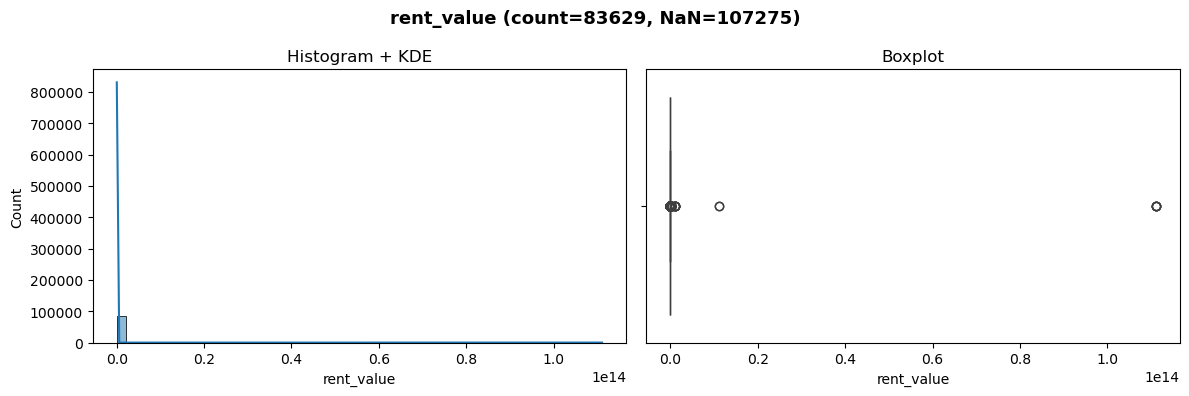

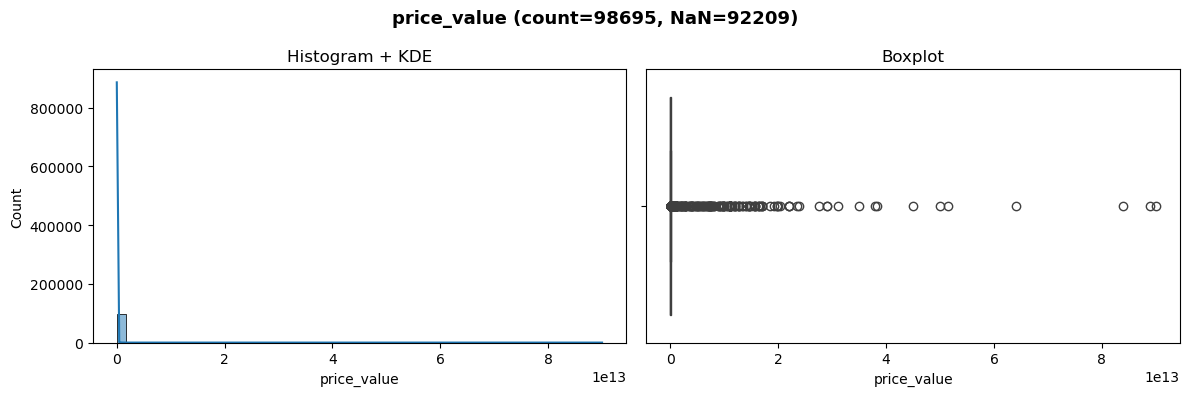

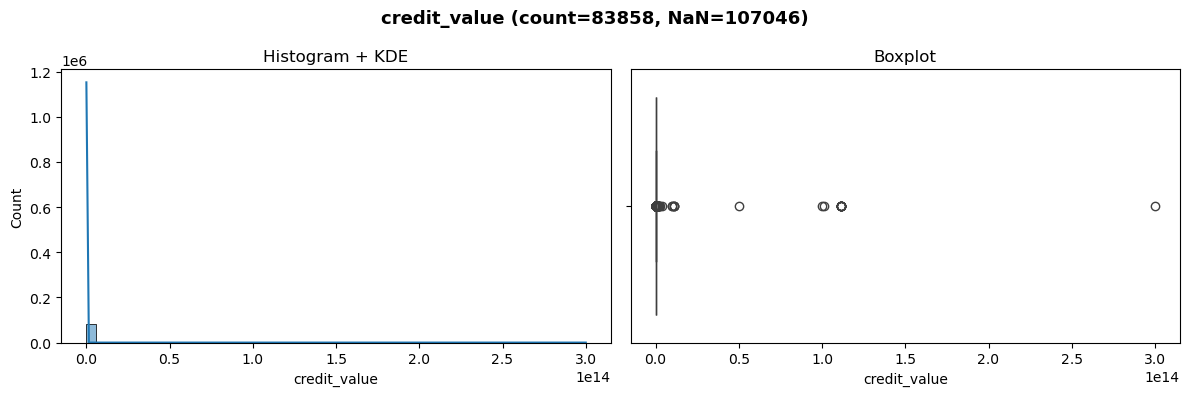

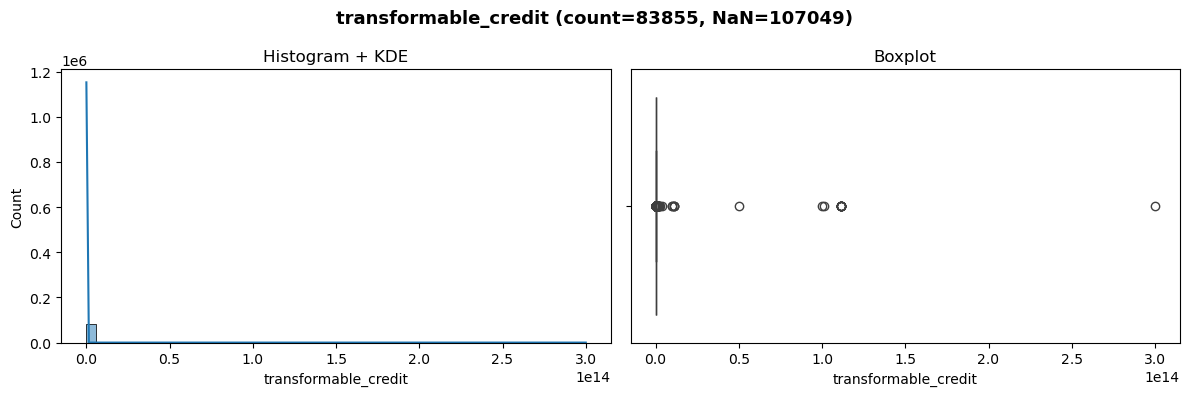

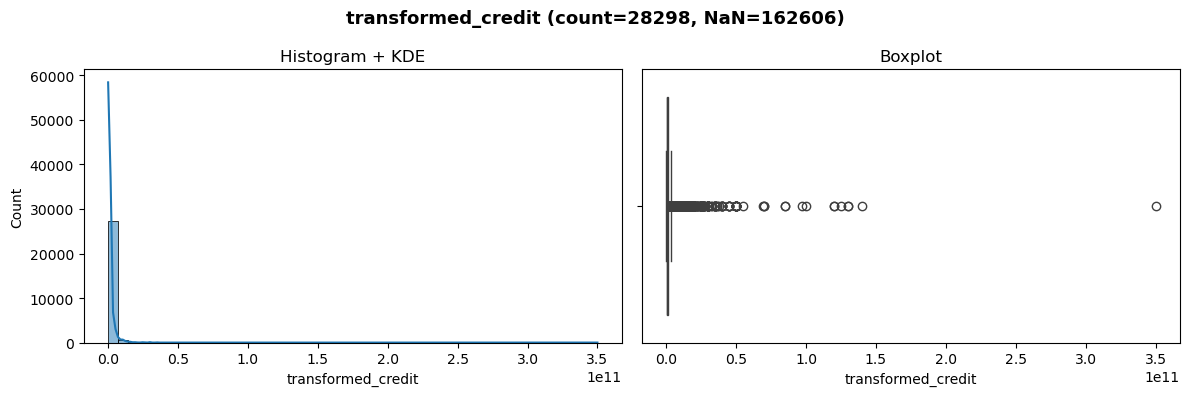

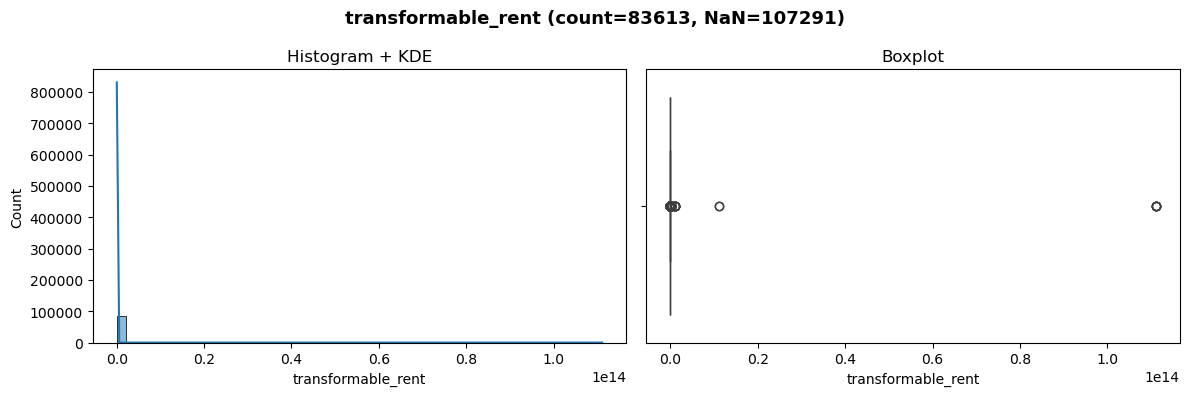

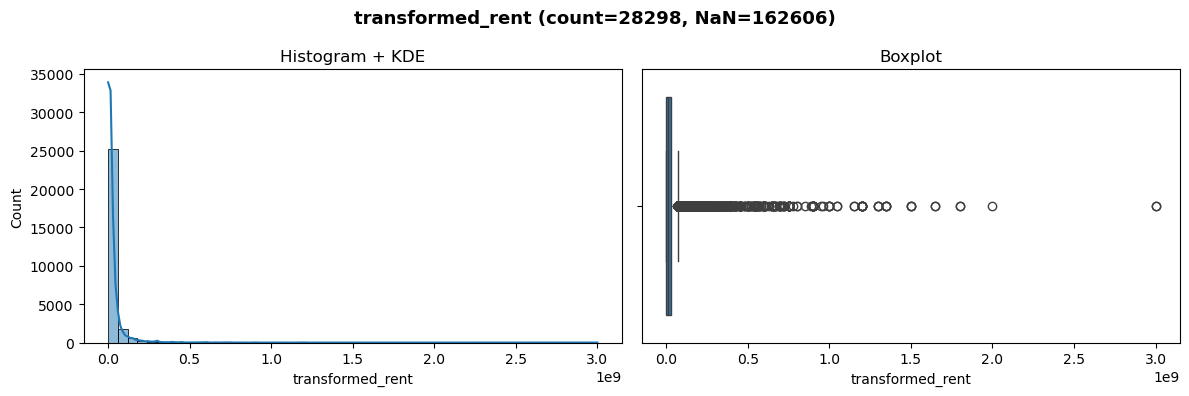

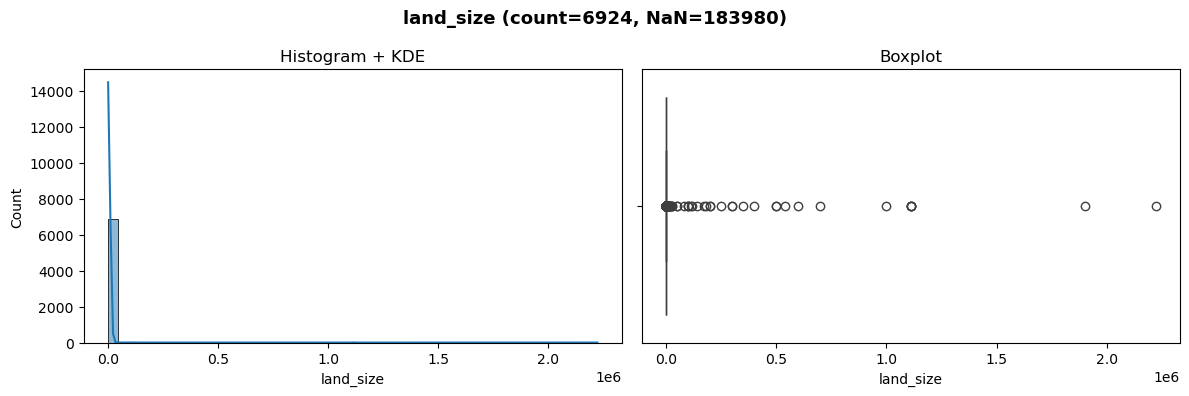

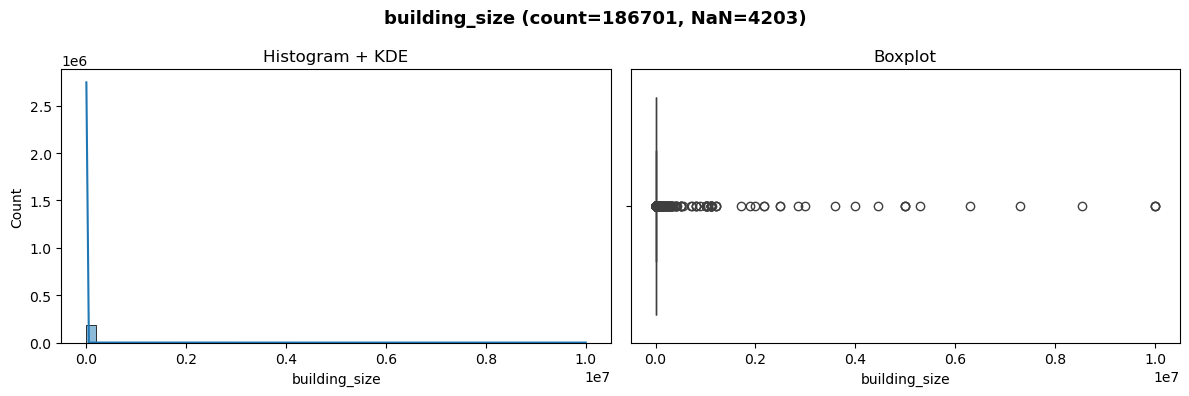

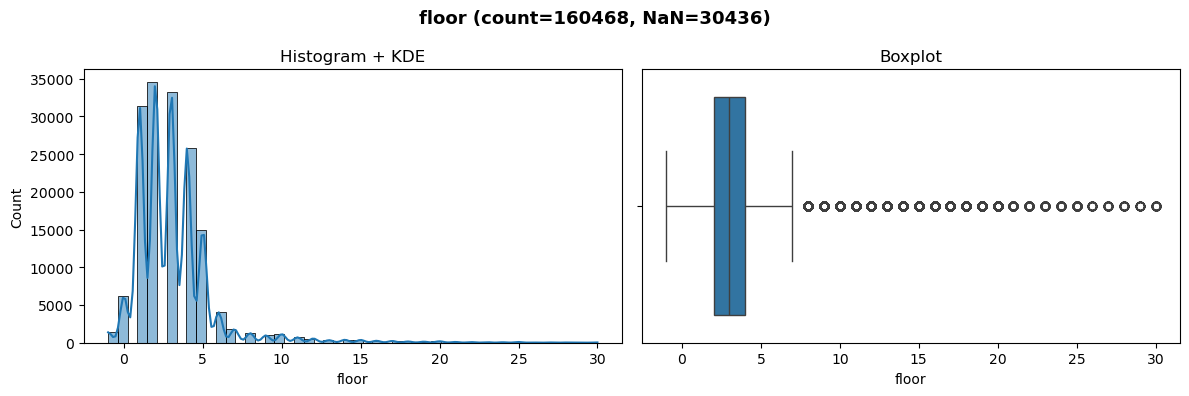

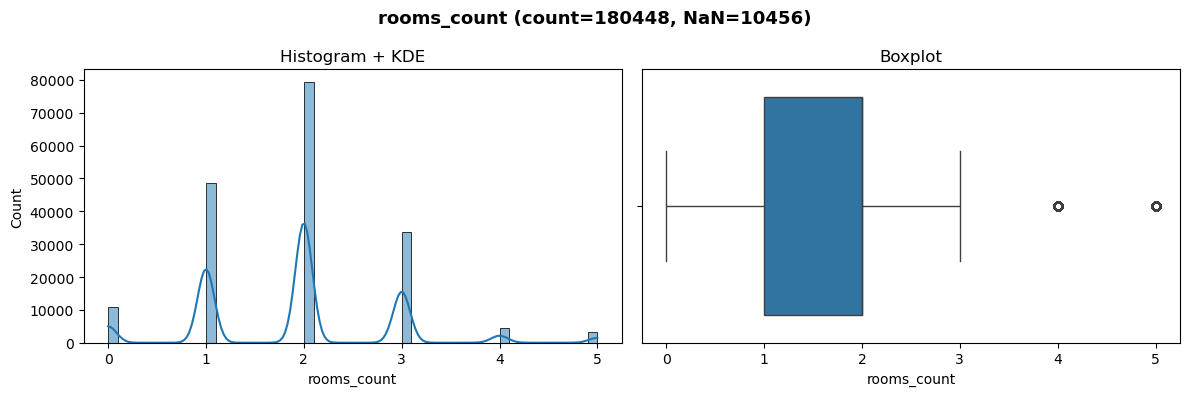

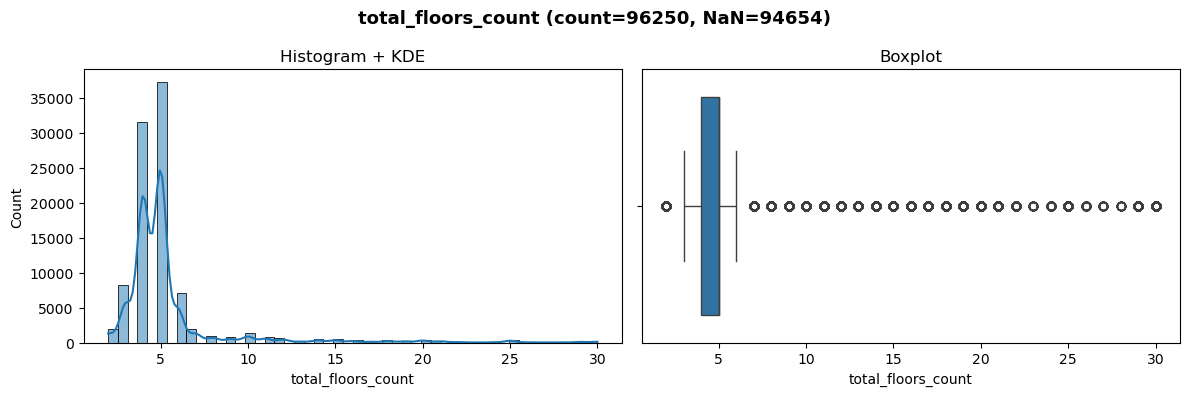

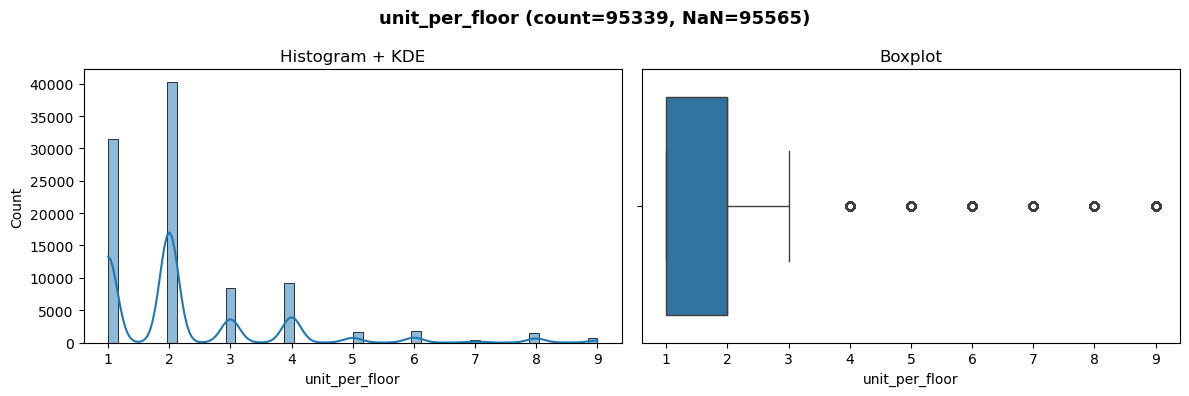

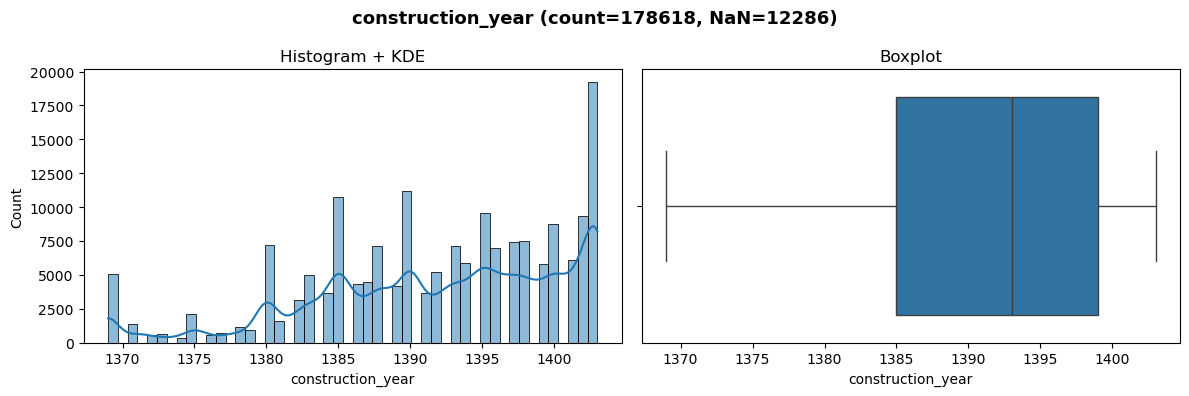

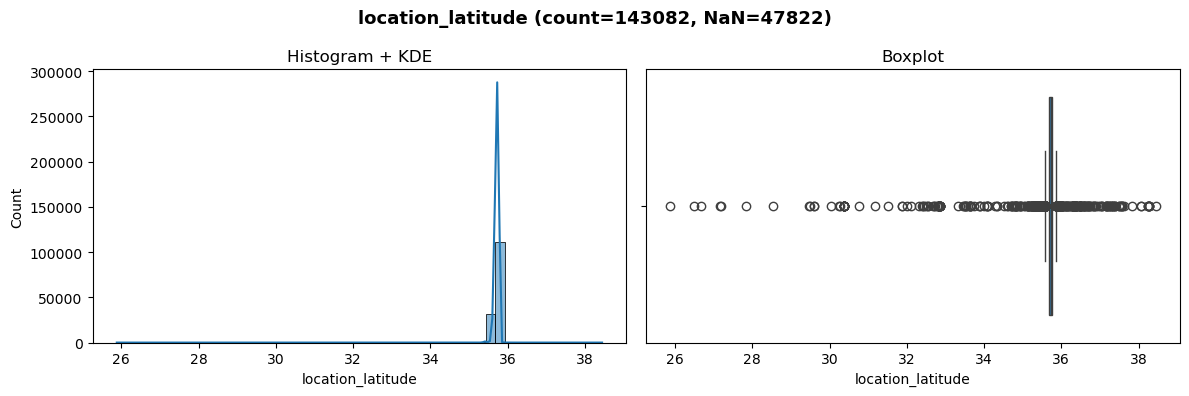

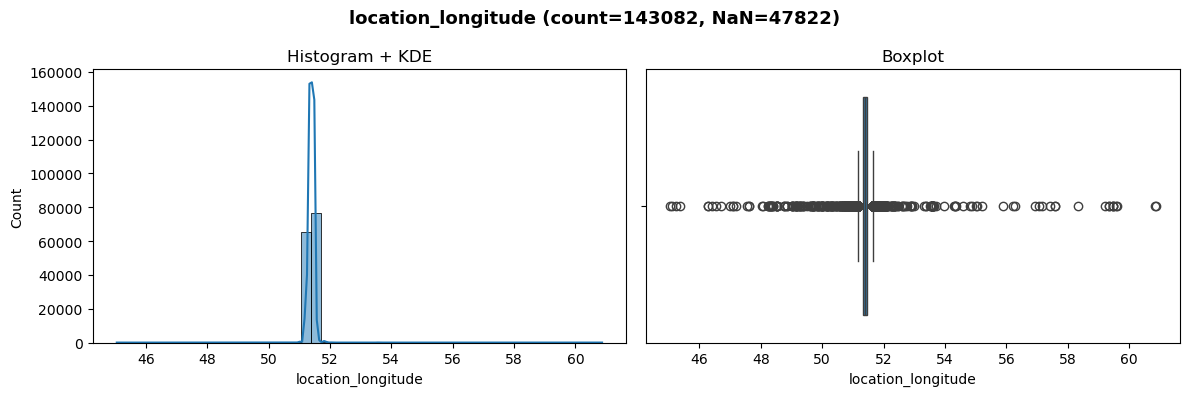

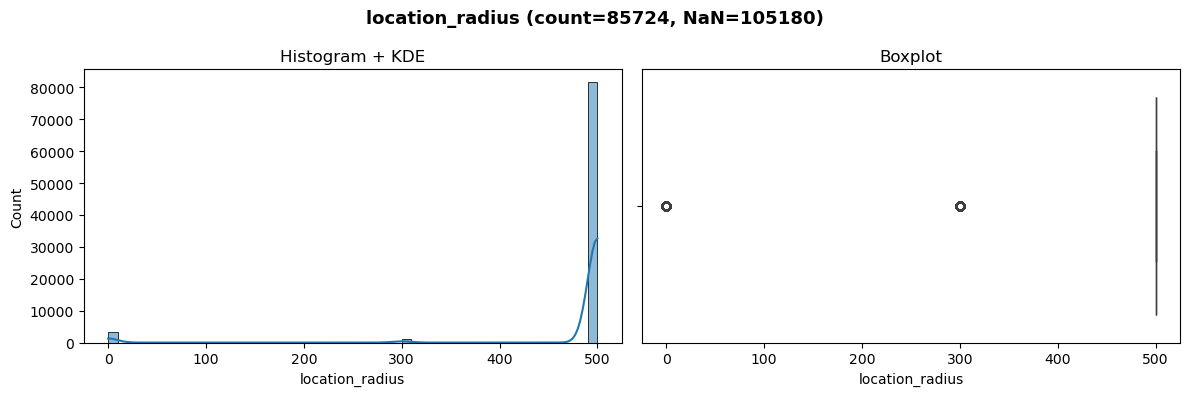

In [47]:
plot_numeric_distributions(df, numeric_cols[:])


| حالت                                       | معنی                                 | اقدام                                                 |
| ------------------------------------------ | ------------------------------------ | ----------------------------------------------------- |
| داده جمع شده سمت چپ و دم بلند سمت راست     | توزیع **چوله به راست**               | از `median` یا `group_median` برای پر کردن استفاده کن |
| مقدارهای پرت (در boxplot نقاط دور از بقیه) | **Outlier** یا داده‌ی اشتباه         | حذف یا تصحیح قبل از پرکردن                            |
| دو قله‌ای (bimodal)                        | داده‌های چندگروهی (مثلاً دو نوع ملک) | بهتره group-based پر بشه (`by=cat2_slug`)             |
| توزیع متقارن                               | داده نرمال                           | می‌تونی `mean` استفاده کنی                            |


In [48]:
for col in numeric_cols:
    print("\n" + "="*70)
    inspect_col(df, col)



================  rent_value  ================
Type: float64 | rows: 190,904 | uniques: 647
NaN: 107,275  (56.19%)

Numeric summary:
count    8.362900e+04
mean     7.076894e+09
std      8.608935e+11
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
25%      1.000000e+05
50%      1.000000e+07
75%      3.000000e+07
95%      1.250000e+08
99%      4.000000e+08
max      1.111111e+14
Name: rent_value, dtype: float64

Zero count: 18,070 | Negative count: 0

IQR outliers:
Q1: 1e+05 | Q3: 3e+07 | IQR: 2.99e+07
Lower fence: -4.475e+07 | Upper fence: 7.485e+07
Below lower: 0 | Above upper: 7,717 | Outlier%: 9.23%

💡 Fill suggestion: group_median (مثلاً by='cat2_slug' یا 'cat3_slug') یا حداقل median


================  price_value  ================
Type: float64 | rows: 190,904 | uniques: 5,877
NaN: 92,209  (48.30%)

Numeric summary:
count    9.869500e+04
mean     3.529477e+10
std      7.640652e+11
min      0.000000e+00
1%       1.079400e+07
5%       1.500000e+09
25%      3.50000

In [49]:
def check_price_distribution(df):
    thresholds = [3e10, 5e10, 1e11, 3e11, 1e12]  # 30B, 50B, 100B, 300B, 1000B
    total = df["price_value"].notna().sum()
    print(f"📊 تعداد کل مقادیر غیرخالی: {total:,}\n")
    for t in thresholds:
        count = (df["price_value"] > t).sum()
        pct = count / total * 100 if total else 0
        print(f"> {t/1e9:,.0f} میلیارد تومان → {count:,} مورد ({pct:.2f}%)")


In [50]:
check_price_distribution(df)


📊 تعداد کل مقادیر غیرخالی: 98,695

> 30 میلیارد تومان → 9,469 مورد (9.59%)
> 50 میلیارد تومان → 5,015 مورد (5.08%)
> 100 میلیارد تومان → 2,118 مورد (2.15%)
> 300 میلیارد تومان → 527 مورد (0.53%)
> 1,000 میلیارد تومان → 154 مورد (0.16%)


In [51]:
for cat in df["cat2_slug"].unique():
    print(f"\n🏷️ {cat}:")
    check_price_distribution(df[df["cat2_slug"] == cat])


🏷️ residential-sell:
📊 تعداد کل مقادیر غیرخالی: 93,529

> 30 میلیارد تومان → 8,548 مورد (9.14%)
> 50 میلیارد تومان → 4,459 مورد (4.77%)
> 100 میلیارد تومان → 1,811 مورد (1.94%)
> 300 میلیارد تومان → 429 مورد (0.46%)
> 1,000 میلیارد تومان → 146 مورد (0.16%)

🏷️ residential-rent:
📊 تعداد کل مقادیر غیرخالی: 1

> 30 میلیارد تومان → 0 مورد (0.00%)
> 50 میلیارد تومان → 0 مورد (0.00%)
> 100 میلیارد تومان → 0 مورد (0.00%)
> 300 میلیارد تومان → 0 مورد (0.00%)
> 1,000 میلیارد تومان → 0 مورد (0.00%)

🏷️ commercial-rent:
📊 تعداد کل مقادیر غیرخالی: 4

> 30 میلیارد تومان → 0 مورد (0.00%)
> 50 میلیارد تومان → 0 مورد (0.00%)
> 100 میلیارد تومان → 0 مورد (0.00%)
> 300 میلیارد تومان → 0 مورد (0.00%)
> 1,000 میلیارد تومان → 0 مورد (0.00%)

🏷️ commercial-sell:
📊 تعداد کل مقادیر غیرخالی: 4,969

> 30 میلیارد تومان → 903 مورد (18.17%)
> 50 میلیارد تومان → 546 مورد (10.99%)
> 100 میلیارد تومان → 304 مورد (6.12%)
> 300 میلیارد تومان → 97 مورد (1.95%)
> 1,000 میلیارد تومان → 8 مورد (0.16%)

🏷️ real-estate-serv

In [52]:
import pandas as pd

def check_price_distribution(df):
    thresholds = [3e10, 5e10, 1e11, 3e11, 1e12]  # 30B, 50B, 100B, 300B, 1000B
    total = df["price_value"].notna().sum()
    print(f"📊 تعداد کل مقادیر غیرخالی: {total:,}\n")
    for t in thresholds:
        count = (df["price_value"] > t).sum()
        pct = count / total * 100 if total else 0
        print(f"> {t/1e9:,.0f} میلیارد تومان → {count:,} مورد ({pct:.2f}%)")

# بررسی کلی
print("======= بررسی کلی price_value =======")
check_price_distribution(df)

# بررسی به تفکیک نوع آگهی
for cat in df["cat2_slug"].unique():
    print(f"\n🏷️ {cat}:")
    check_price_distribution(df[df["cat2_slug"] == cat])


======= بررسی کلی price_value =======
📊 تعداد کل مقادیر غیرخالی: 98,695

> 30 میلیارد تومان → 9,469 مورد (9.59%)
> 50 میلیارد تومان → 5,015 مورد (5.08%)
> 100 میلیارد تومان → 2,118 مورد (2.15%)
> 300 میلیارد تومان → 527 مورد (0.53%)
> 1,000 میلیارد تومان → 154 مورد (0.16%)

🏷️ residential-sell:
📊 تعداد کل مقادیر غیرخالی: 93,529

> 30 میلیارد تومان → 8,548 مورد (9.14%)
> 50 میلیارد تومان → 4,459 مورد (4.77%)
> 100 میلیارد تومان → 1,811 مورد (1.94%)
> 300 میلیارد تومان → 429 مورد (0.46%)
> 1,000 میلیارد تومان → 146 مورد (0.16%)

🏷️ residential-rent:
📊 تعداد کل مقادیر غیرخالی: 1

> 30 میلیارد تومان → 0 مورد (0.00%)
> 50 میلیارد تومان → 0 مورد (0.00%)
> 100 میلیارد تومان → 0 مورد (0.00%)
> 300 میلیارد تومان → 0 مورد (0.00%)
> 1,000 میلیارد تومان → 0 مورد (0.00%)

🏷️ commercial-rent:
📊 تعداد کل مقادیر غیرخالی: 4

> 30 میلیارد تومان → 0 مورد (0.00%)
> 50 میلیارد تومان → 0 مورد (0.00%)
> 100 میلیارد تومان → 0 مورد (0.00%)
> 300 میلیارد تومان → 0 مورد (0.00%)
> 1,000 میلیارد تومان → 0 مورد (0.

#### مرحله ۱: اصلاح مقادیر اشتباه (غیرواقعی)

In [53]:
# کپی برای اطمینان (اختیاری)
df_clean = df.copy()

# حذف قیمت‌های صفر یا منفی (قطعاً اشتباه)
df_clean.loc[df_clean["price_value"] <= 0, "price_value"] = np.nan

# حذف قیمت‌های غیرواقعی (بالای ۱۰۰۰ میلیارد تومان)
df_clean.loc[df_clean["price_value"] > 1e12, "price_value"] = np.nan

print("📊 بعد از اصلاح مقادیر غیرواقعی:")
print(df_clean["price_value"].describe())
print(f"تعداد NaN بعد از اصلاح: {df_clean['price_value'].isna().sum()}")

📊 بعد از اصلاح مقادیر غیرواقعی:
count    9.852000e+04
mean     1.563493e+10
std      3.960094e+10
min      1.000000e+00
25%      3.500000e+09
50%      7.000000e+09
75%      1.380000e+10
max      1.000000e+12
Name: price_value, dtype: float64
تعداد NaN بعد از اصلاح: 92384


#### مرحله ۲: پر کردن مقادیر NaN با میانه‌ی گروهی (group median)

In [54]:
# پر کردن امن با میانه هر دسته (cat2_slug)
df_clean["price_value"] = df_clean.groupby("cat2_slug")["price_value"].transform(
    lambda x: x.fillna(x.median())
)

print("✅ پر کردن NaNها انجام شد.")
print(df_clean["price_value"].describe())

✅ پر کردن NaNها انجام شد.
count    1.909040e+05
mean     9.563760e+09
std      2.915809e+10
min      1.000000e+00
25%      3.550000e+09
50%      3.550000e+09
75%      7.500000e+09
max      1.000000e+12
Name: price_value, dtype: float64


#### مرحله ۳: بررسی نهایی (قبل/بعد از پر کردن)

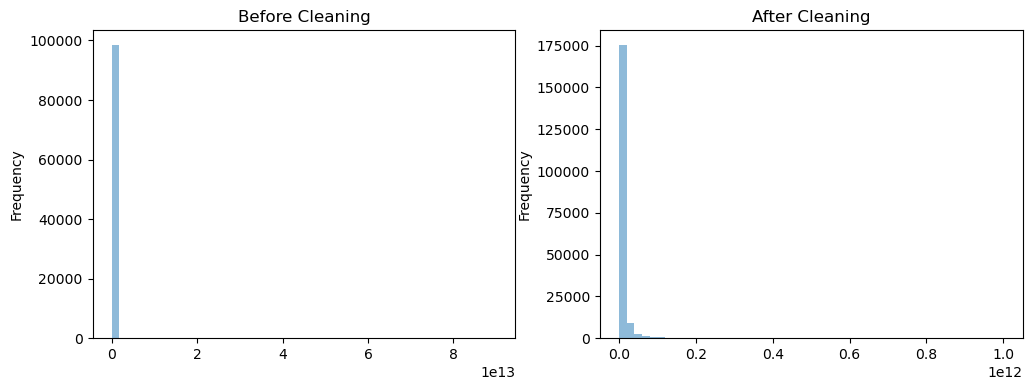

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# قبل از پر کردن
df["price_value"].plot(kind="hist", bins=50, alpha=0.5, ax=ax[0], title="Before Cleaning")
# بعد از پر کردن
df_clean["price_value"].plot(kind="hist", bins=50, alpha=0.5, ax=ax[1], title="After Cleaning")

plt.show()

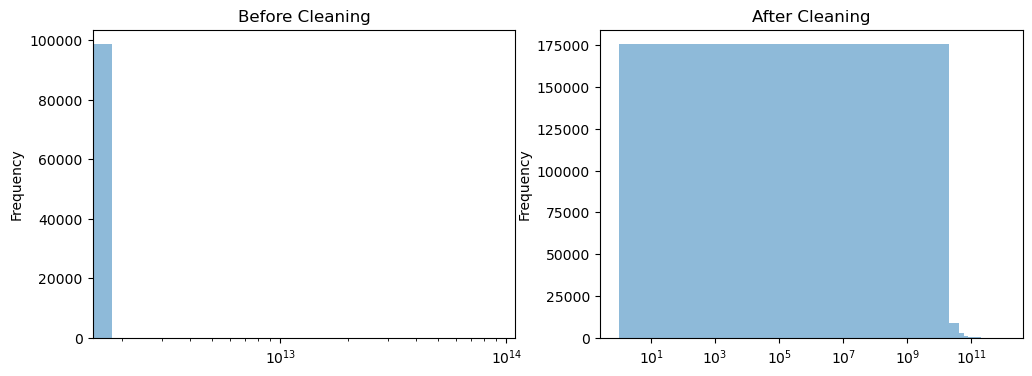

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df["price_value"].plot(kind="hist", bins=50, alpha=0.5, ax=ax[0], title="Before Cleaning", logx=True)
df_clean["price_value"].plot(kind="hist", bins=50, alpha=0.5, ax=ax[1], title="After Cleaning", logx=True)

plt.show()

In [58]:
df.groupby("cat2_slug")["price_value"].apply(lambda x: x.notna().sum()).to_frame("filled_values")


,filled_values
cat2_slug,
commercial-rent,4
commercial-sell,4969
real-estate-services,191
residential-rent,1
residential-sell,93529
temporary-rent,1


In [60]:
summary = (
    df_clean.groupby("cat2_slug")[["price_value", "rent_value", "credit_value"]]
    .agg(["count", lambda x: x.notna().sum()])
)

summary.columns = ["_".join(col).strip() for col in summary.columns.values]
summary = summary.rename(
    columns={
        "price_value_<lambda_0>": "price_filled",
        "rent_value_<lambda_0>": "rent_filled",
        "credit_value_<lambda_0>": "credit_filled",
        "price_value_count": "price_total",
        "rent_value_count": "rent_total",
        "credit_value_count": "credit_total",
    }
)
summary["price_fill_ratio"] = (summary["price_filled"] / summary["price_total"] * 100).round(2)
summary["rent_fill_ratio"] = (summary["rent_filled"] / summary["rent_total"] * 100).round(2)
summary["credit_fill_ratio"] = (summary["credit_filled"] / summary["credit_total"] * 100).round(2)

print(summary)


                      price_total  price_filled  rent_total  rent_filled  \
cat2_slug                                                                  
commercial-rent             16549         16549       16351        16351   
commercial-sell              6140          6140           2            2   
real-estate-services         4167          4167           0            0   
residential-rent            67722         67722       67275        67275   
residential-sell            94541         94541           0            0   
temporary-rent               1785          1785           1            1   

                      credit_total  credit_filled  price_fill_ratio  \
cat2_slug                                                             
commercial-rent              16369          16369             100.0   
commercial-sell                  2              2             100.0   
real-estate-services             0              0             100.0   
residential-rent             67486  

In [61]:
print(df["rent_value"].isna().sum(), "→ قبل از")
print(df_clean["rent_value"].isna().sum(), "→ بعد از")

print(df["credit_value"].isna().sum(), "→ قبل از")
print(df_clean["credit_value"].isna().sum(), "→ بعد از")


107275 → قبل از
107275 → بعد از
107046 → قبل از
107046 → بعد از


#### ۱. بررسی فقط ردیف‌هایی که پر شدن

(یعنی قبلاً NaN بودن و الان مقدار دارن)

In [62]:
# پیدا کردن ردیف‌هایی که price_value قبلاً NaN بوده و حالا پر شده
filled_rows = df[df["price_value"].isna()] 
filled_now = df_clean.loc[df["price_value"].isna() & df_clean["price_value"].notna(), 
                          ["cat2_slug", "price_value"]]

print(f"🔍 تعداد مقادیر پرشده: {len(filled_now)}")
display(filled_now.head(10))


🔍 تعداد مقادیر پرشده: 92209


,cat2_slug,price_value
1,residential-rent,3.550000e+09
2,commercial-rent,7.590000e+07
4,residential-rent,3.550000e+09
7,residential-rent,3.550000e+09
8,residential-rent,3.550000e+09
10,residential-rent,3.550000e+09
11,residential-rent,3.550000e+09
12,residential-rent,3.550000e+09
15,residential-rent,3.550000e+09
16,commercial-rent,7.590000e+07


#### ۳. خلاصه درصدی از مقدارهای پرشده در هر گروه

In [63]:
fill_ratio = (
    df_clean.groupby("cat2_slug")["price_value"]
    .apply(lambda x: (x == x.median()).sum())
    .to_frame("filled_like_median")
)

print(fill_ratio)


                      filled_like_median
cat2_slug                               
commercial-rent                    16545
commercial-sell                     1245
real-estate-services                3978
residential-rent                   67722
residential-sell                    1520
temporary-rent                      1785


مراحل دقیق (خلاصه)

کپی دیتافریم (برای ایمنی).

پاک‌سازی بدیهی: اعداد ≤۰ ⇒ NaN.

آستانه‌های پرت را به‌صورت تطبیقی بساز:

اگر محله داده‌ی کافی دارد (≥30 آگهی اجاره) ⇒ IQR Fence محله

وگرنه فالبک به IQR نوع آگهی (cat2_slug)

و اگر آن‌هم کم بود ⇒ IQR کل دیتاست

علاوه بر این‌ها یک سقف مطلق محافظ (Absolute Max) هم بگذار (پیش‌فرض 200,000,000) تا اشتباهات فاحش را بگیرد.

علامت‌گذاری پرت‌ها بر اساس فنس‌های بالا (نه حذف کورکورانه).

مقدارهای پرت و غیرواقعی ⇒ NaN.

پر کردن NaNها با میانهٔ محله (اگر ≥10 رکورد)، وگرنه فالبک به میانهٔ نوع آگهی.

گزارش نهایی: چند تا رکورد با هر روش پر/پاک شد و وضعیت اعداد «۱۰۰ میلیون» چه شد.

In [65]:
# =====[ 0) پارامترهای قابل تنظیم ]=====
NEIGH_MIN_FOR_FENCE = 30   # کمینه رکورد اجاره در محله برای محاسبه‌ی فنس
NEIGH_MIN_FOR_FILL  = 10   # کمینه رکورد برای پر کردن با میانه‌ی محله
ABSOLUTE_MAX_RENT   = 200_000_000  # سقف مطلق محافظ (200 میلیون)
COL = "rent_value"

# =====[ 1) کپی دیتافریم ]=====
df_clean = df.copy()

# =====[ 2) پاک‌سازی بدیهی ]=====
# صفر و منفی → NaN
df_clean.loc[df_clean[COL] <= 0, COL] = np.nan

# =====[ 3) ساخت فنس‌های تطبیقی (IQR) ]=====
def iqr_fence(series: pd.Series):
    s = series.dropna()
    if s.empty:
        return (None, None)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower = max(q1 - 1.5*iqr, 0)  # اجاره زیر صفر بی‌معنی است
    upper = q3 + 1.5*iqr
    return (lower, upper)

# فنس محله (اگر داده کافی دارد)
neigh_counts = df_clean[df_clean["cat2_slug"].str.contains("rent", na=False)].groupby("neighborhood_slug")[COL].count()
eligible_neigh = set(neigh_counts[neigh_counts >= NEIGH_MIN_FOR_FENCE].index)

neigh_fences = {}
for nbh in eligible_neigh:
    lower, upper = iqr_fence(df_clean.loc[df_clean["neighborhood_slug"]==nbh, COL])
    neigh_fences[nbh] = (lower, upper)

# فنس نوع آگهی (cat2_slug) برای فالبک
cat2_fences = {}
for cat in df_clean["cat2_slug"].unique():
    s = df_clean.loc[df_clean["cat2_slug"]==cat, COL]
    lower, upper = iqr_fence(s)
    cat2_fences[cat] = (lower, upper)

# فنس سراسری (آخرین فالبک)
global_lower, global_upper = iqr_fence(df_clean[COL])

# =====[ 4) تعیین پرت برای هر سطر (تطبیقی) ]=====
def adaptive_is_outlier(row):
    val = row[COL]
    if pd.isna(val):
        return False
    # سقف مطلق محافظ
    if val > ABSOLUTE_MAX_RENT:
        return True
    # محله اگر فنس دارد
    nbh = row.get("neighborhood_slug", None)
    if nbh in neigh_fences and neigh_fences[nbh][1] is not None:
        _, up = neigh_fences[nbh]
        return val > up
    # فالبک: نوع آگهی
    cat = row.get("cat2_slug", None)
    if cat in cat2_fences and cat2_fences[cat][1] is not None:
        _, up = cat2_fences[cat]
        return val > up
    # فالبک نهایی: فنس سراسری
    if global_upper is not None:
        return val > global_upper
    return False

mask_outlier = df_clean.apply(adaptive_is_outlier, axis=1)

# =====[ 5) پرت‌ها و غیرواقعی‌ها را NaN کن ]=====
before_na = df_clean[COL].isna().sum()
df_clean.loc[mask_outlier, COL] = np.nan
after_na = df_clean[COL].isna().sum()

if global_upper is not None:
    print(f"📈 فنس سراسری بالا (اطلاع): {global_upper:,.0f}")
else:
    print("📈 فنس سراسری بالا (اطلاع): None")

print(f"🔒 سقف مطلق محافظ: {ABSOLUTE_MAX_RENT:,.0f}")


# =====[ 6) پرکردن تطبیقی: میانه محله و فالبک نوع آگهی ]=====
# 6-الف) میانه محله برای محله‌های با داده‌ی کافی
neigh_medians = (
    df_clean.groupby("neighborhood_slug")[COL]
    .agg(["median", "count"])
)
eligible_fill_neigh = neigh_medians.query(f"count >= {NEIGH_MIN_FOR_FILL}")["median"].to_dict()

def fill_with_neigh(row):
    if pd.isna(row[COL]):
        nbh = row["neighborhood_slug"]
        if nbh in eligible_fill_neigh and pd.notna(eligible_fill_neigh[nbh]):
            return eligible_fill_neigh[nbh]
    return row[COL]

df_clean[COL] = df_clean.apply(fill_with_neigh, axis=1)

# 6-ب) برای باقی مانده‌ها: میانه نوع آگهی
cat2_medians = df_clean.groupby("cat2_slug")[COL].median().to_dict()
df_clean[COL] = df_clean.apply(
    lambda r: cat2_medians.get(r["cat2_slug"], np.nan) if pd.isna(r[COL]) else r[COL],
    axis=1
)

# =====[ 7) گزارش نهایی ]=====
print("\n✅ پر کردن NaN تکمیل شد.")
print(df_clean[COL].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))
print("NaN باقی‌مانده:", df_clean[COL].isna().sum())

📈 فنس سراسری بالا (اطلاع): 78,275,000
🔒 سقف مطلق محافظ: 200,000,000

✅ پر کردن NaN تکمیل شد.
count    1.909040e+05
mean     2.084255e+07
std      2.201095e+07
min      1.000000e+00
1%       1.000000e+05
5%       2.500000e+06
25%      8.000000e+06
50%      1.500000e+07
75%      2.500000e+07
95%      6.000000e+07
99%      1.050000e+08
max      2.000000e+08
Name: rent_value, dtype: float64
NaN باقی‌مانده: 0


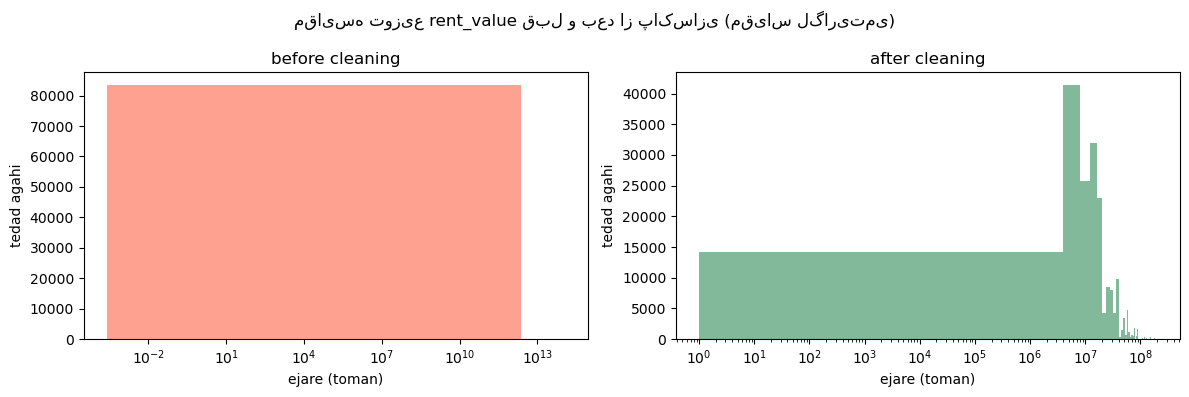

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# حالت قبل از تمیزسازی (از df اولیه)
df["rent_value"].plot(
    kind="hist", bins=50, alpha=0.6, ax=ax[0],
    title="before cleaning", logx=True, color="tomato"
)

# حالت بعد از تمیزسازی (df_clean)
df_clean["rent_value"].plot(
    kind="hist", bins=50, alpha=0.6, ax=ax[1],
    title="after cleaning", logx=True, color="seagreen"
)

for a in ax:
    a.set_xlabel("ejare (toman)")
    a.set_ylabel("tedad agahi")

plt.suptitle("مقایسه توزیع rent_value قبل و بعد از پاکسازی (مقیاس لگاریتمی)", fontsize=12)
plt.tight_layout()
plt.show()


تفسیر مورد انتظار:

در نمودار سمت چپ (قبل از پاکسازی)، توزیع احتمالاً به‌شدت فشرده و کشیده است (به‌خاطر مقادیر پرت مثل ۱۰¹⁴).

در نمودار سمت راست (بعد از پاکسازی)، توزیع نرم و خوش‌فرم‌تر میشه، پیک اصلی حدود ۵ تا ۳۰ میلیون دیده میشه، و مقیاس لگاریتمی نشون میده داده‌ها از ۱۰۰ هزار تا حدود ۱۰۰ میلیون پخش شدن بدون شکستگی یا دم عجیب.

In [69]:
COL = "credit_value"
NEIGH_MIN_FOR_FENCE = 30
NEIGH_MIN_FOR_FILL  = 10
ABSOLUTE_MAX_CREDIT = 10_000_000_000  # 10 میلیارد تومان

# 1️⃣ پاک‌سازی بدیهی
df_clean.loc[df_clean[COL] <= 0, COL] = np.nan

# 2️⃣ محاسبه IQR تطبیقی
def iqr_fence(series):
    s = series.dropna()
    if s.empty:
        return (None, None)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower = max(q1 - 1.5*iqr, 0)
    upper = q3 + 1.5*iqr
    return (lower, upper)

# فنس محله
neigh_counts = df_clean[df_clean["cat2_slug"].str.contains("rent", na=False)].groupby("neighborhood_slug")[COL].count()
eligible_neigh = set(neigh_counts[neigh_counts >= NEIGH_MIN_FOR_FENCE].index)

neigh_fences = {
    nbh: iqr_fence(df_clean.loc[df_clean["neighborhood_slug"]==nbh, COL])
    for nbh in eligible_neigh
}

# فنس نوع آگهی
cat2_fences = {
    cat: iqr_fence(df_clean.loc[df_clean["cat2_slug"]==cat, COL])
    for cat in df_clean["cat2_slug"].unique()
}

# فنس کلی
global_lower, global_upper = iqr_fence(df_clean[COL])

# 3️⃣ تشخیص پرت‌ها
def adaptive_is_outlier(row):
    val = row[COL]
    if pd.isna(val):
        return False
    if val > ABSOLUTE_MAX_CREDIT:
        return True
    nbh = row["neighborhood_slug"]
    cat = row["cat2_slug"]
    if nbh in neigh_fences and neigh_fences[nbh][1] is not None:
        _, up = neigh_fences[nbh]
        if val > up: return True
    if cat in cat2_fences and cat2_fences[cat][1] is not None:
        _, up = cat2_fences[cat]
        if val > up: return True
    if global_upper is not None and val > global_upper:
        return True
    return False

mask_outlier = df_clean.apply(adaptive_is_outlier, axis=1)
df_clean.loc[mask_outlier, COL] = np.nan

print(f"⚠️ تبدیل به NaN (پرت/غیرواقعی): {mask_outlier.sum():,}")
print(f"📈 فنس سراسری بالا (اطلاع): {global_upper:,.0f}")
print(f"🔒 سقف مطلق محافظ: {ABSOLUTE_MAX_CREDIT:,.0f}")

# 4️⃣ پر کردن تطبیقی
neigh_medians = (
    df_clean.groupby("neighborhood_slug")[COL]
    .agg(["median", "count"])
)
eligible_fill_neigh = neigh_medians.query(f"count >= {NEIGH_MIN_FOR_FILL}")["median"].to_dict()

def fill_with_neigh(row):
    if pd.isna(row[COL]):
        nbh = row["neighborhood_slug"]
        if nbh in eligible_fill_neigh and pd.notna(eligible_fill_neigh[nbh]):
            return eligible_fill_neigh[nbh]
    return row[COL]

df_clean[COL] = df_clean.apply(fill_with_neigh, axis=1)

# فالبک نوع آگهی
cat2_medians = df_clean.groupby("cat2_slug")[COL].median().to_dict()
df_clean[COL] = df_clean.apply(
    lambda r: cat2_medians.get(r["cat2_slug"], np.nan) if pd.isna(r[COL]) else r[COL],
    axis=1
)

# گزارش نهایی
print("\n✅ پر کردن NaN تکمیل شد.")
print(df_clean[COL].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))
print("NaN باقی‌مانده:", df_clean[COL].isna().sum())


⚠️ تبدیل به NaN (پرت/غیرواقعی): 9,470
📈 فنس سراسری بالا (اطلاع): 2,300,000,000
🔒 سقف مطلق محافظ: 10,000,000,000

✅ پر کردن NaN تکمیل شد.
count    1.909040e+05
mean     6.015733e+08
std      3.745969e+08
min      1.000000e+00
1%       1.000000e+07
5%       1.500000e+08
25%      3.200000e+08
50%      5.000000e+08
75%      8.000000e+08
95%      1.300000e+09
99%      2.000000e+09
max      2.300000e+09
Name: credit_value, dtype: float64
NaN باقی‌مانده: 0


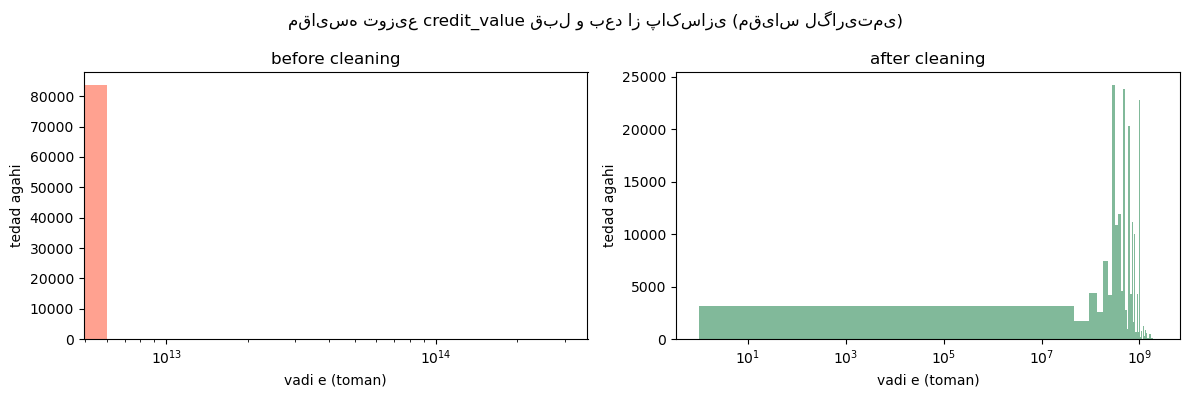

In [70]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# حالت قبل از پاکسازی
df["credit_value"].plot(
    kind="hist",
    bins=50,
    alpha=0.6,
    ax=ax[0],
    title="before cleaning",
    color="tomato",
    logx=True
)

# حالت بعد از پاکسازی
df_clean["credit_value"].plot(
    kind="hist",
    bins=50,
    alpha=0.6,
    ax=ax[1],
    title="after cleaning",
    color="seagreen",
    logx=True
)

for a in ax:
    a.set_xlabel("vadi e (toman)")
    a.set_ylabel("tedad agahi")

plt.suptitle("مقایسه توزیع credit_value قبل و بعد از پاکسازی (مقیاس لگاریتمی)", fontsize=12)
plt.tight_layout()
plt.show()


# در این زمان متوجه شدم price value به صورت اشتباه پر شده است و مجدد کد را تغییر دادم !

In [71]:
# 0) اگر df همون نسخه‌ی قبل از پرکردن باشه، از همون به‌عنوان مرجع استفاده می‌کنیم
#    و ستون price_value در df_clean را به حالت قبل برمی‌گردانیم.
df_clean = df_clean.copy()
df_clean["price_value"] = df["price_value"]  # بازگردانی به حالت اولیه

# 1) فقط ردیف‌های "sell" مجازند price_value داشته باشند؛ برای بقیه NaN
sell_mask = df_clean["cat2_slug"].str.contains("sell", na=False)
df_clean.loc[~sell_mask, "price_value"] = np.nan

# 2) پاک‌سازی بدیهی در فروش‌ها: صفر/منفی و مقادیر غیرواقعی خیلی بزرگ
df_clean.loc[sell_mask & (df_clean["price_value"] <= 0), "price_value"] = np.nan
df_clean.loc[sell_mask & (df_clean["price_value"] > 1e12), "price_value"] = np.nan  # >1000 میلیارد → اشتباه

# 3) فنس تطبیقی IQR بر اساس نوع ملک (cat3_slug) فقط داخل فروش‌ها
def iqr_fence(s):
    s = s.dropna()
    if s.empty:
        return (None, None)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return max(q1 - 1.5*iqr, 0), q3 + 1.5*iqr

fences_cat3 = {}
for c3, sub in df_clean.loc[sell_mask].groupby("cat3_slug")["price_value"]:
    fences_cat3[c3] = iqr_fence(sub)

# اعمال فنس بالایی برای حذف پرت‌های فروش به‌صورت نوع‌ملکی
upper_by_cat3 = df_clean["cat3_slug"].map(lambda k: fences_cat3.get(k, (None,None))[1])
df_clean.loc[sell_mask & df_clean["price_value"].notna() & (df_clean["price_value"] > upper_by_cat3), "price_value"] = np.nan

# 4) پر کردن امن:
#    اول با میانه‌ی (cat3_slug, neighborhood_slug) اگر حداقل 20 نمونه دارد،
#    بعد با میانه‌ی cat3_slug، و در نهایت با میانه‌ی cat2_slug (sell).
MIN_PAIR = 20

pair_stats = (
    df_clean.loc[sell_mask]
            .groupby(["cat3_slug", "neighborhood_slug"])["price_value"]
            .agg(["median", "count"])
)
pair_medians = pair_stats.query(f"count >= {MIN_PAIR}")["median"].to_dict()

def fill_pairwise(row):
    if sell_mask[row.name] and pd.isna(row["price_value"]):
        key = (row["cat3_slug"], row["neighborhood_slug"])
        if key in pair_medians and pd.notna(pair_medians[key]):
            return pair_medians[key]
    return row["price_value"]

df_clean["price_value"] = df_clean.apply(fill_pairwise, axis=1)

# فالبک 1: میانه‌ی cat3_slug
cat3_median = df_clean.loc[sell_mask].groupby("cat3_slug")["price_value"].median().to_dict()
df_clean.loc[sell_mask, "price_value"] = df_clean.loc[sell_mask].apply(
    lambda r: cat3_median.get(r["cat3_slug"], np.nan) if pd.isna(r["price_value"]) else r["price_value"],
    axis=1
)

# فالبک 2: میانه‌ی cat2_slug (فقط فروش)
cat2_median_sell = df_clean.loc[sell_mask].groupby("cat2_slug")["price_value"].median().to_dict()
df_clean.loc[sell_mask, "price_value"] = df_clean.loc[sell_mask].apply(
    lambda r: cat2_median_sell.get(r["cat2_slug"], np.nan) if pd.isna(r["price_value"]) else r["price_value"],
    axis=1
)

# 5) چک نهایی: اطمینان از اینکه برای rent چیزی پر نشده
check = (
    df_clean.groupby("cat2_slug")["price_value"]
            .apply(lambda x: x.notna().sum())
            .to_frame("price_notna")
)
print("📊 تعداد price_value غیرخالی به تفکیک cat2_slug:\n", check)

# 6) کیفیت پرکردن در فروش‌ها
print("\n📈 خلاصه‌ی آماری price_value فقط در sell بعد از کلین:")
print(df_clean.loc[sell_mask, "price_value"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

📊 تعداد price_value غیرخالی به تفکیک cat2_slug:
                       price_notna
cat2_slug                        
commercial-rent                 0
commercial-sell              6140
real-estate-services            0
residential-rent                0
residential-sell            94541
temporary-rent                  0

📈 خلاصه‌ی آماری price_value فقط در sell بعد از کلین:
count    1.006810e+05
mean     9.797878e+09
std      1.104153e+10
min      1.000000e+00
1%       1.111111e+07
5%       1.500000e+09
25%      3.550000e+09
50%      7.000000e+09
75%      1.300000e+10
95%      2.298000e+10
99%      5.700000e+10
max      1.470000e+11
Name: price_value, dtype: float64


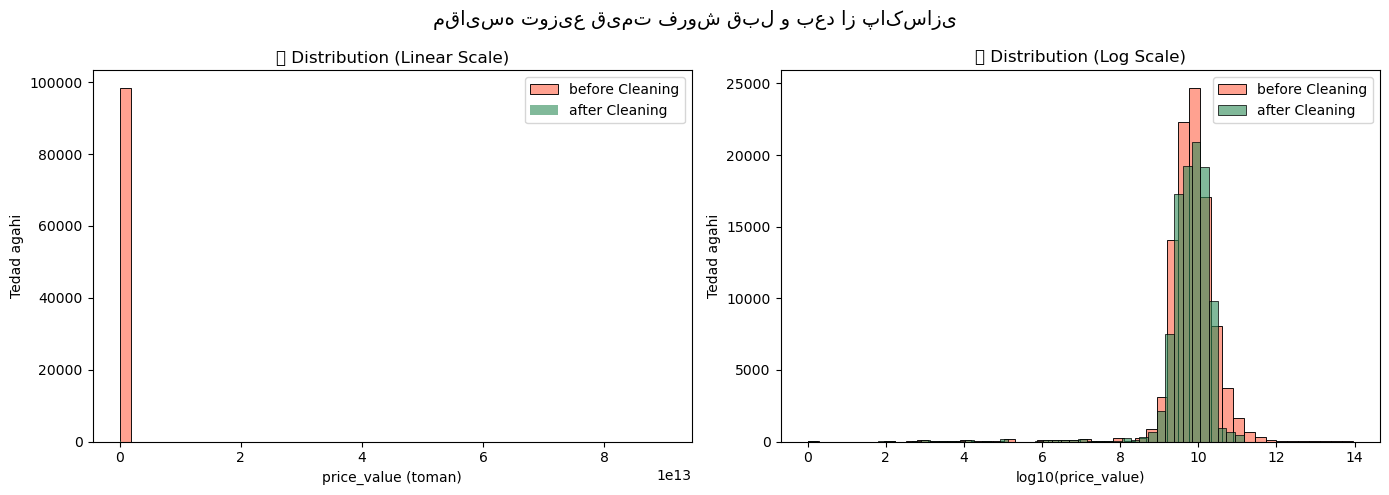

In [73]:
# 🎯 فقط داده‌های فروش
mask_sell = df_clean["cat2_slug"].str.contains("sell", na=False)

# برای مقایسه قبل و بعد
before = df.loc[mask_sell, "price_value"]
after = df_clean.loc[mask_sell, "price_value"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔹 1) نمودار معمولی (Linear Scale)
sns.histplot(before, bins=50, ax=axes[0], color="tomato", alpha=0.6, label="before Cleaning")
sns.histplot(after, bins=50, ax=axes[0], color="seagreen", alpha=0.6, label="after Cleaning")
axes[0].set_title("📊 Distribution (Linear Scale)", fontsize=12)
axes[0].set_xlabel("price_value (toman)")
axes[0].set_ylabel("Tedad agahi")
axes[0].legend()

# 🔹 2) نمودار لگاریتمی (Log Scale)
sns.histplot(np.log10(before[before > 0]), bins=50, ax=axes[1], color="tomato", alpha=0.6, label="before Cleaning")
sns.histplot(np.log10(after[after > 0]), bins=50, ax=axes[1], color="seagreen", alpha=0.6, label="after Cleaning")
axes[1].set_title("📈 Distribution (Log Scale)", fontsize=12)
axes[1].set_xlabel("log10(price_value)")
axes[1].set_ylabel("Tedad agahi")
axes[1].legend()

plt.suptitle("مقایسه توزیع قیمت فروش قبل و بعد از پاک‌سازی", fontsize=14)
plt.tight_layout()
plt.show()

In [75]:
for col in numeric_cols:
    print("\n" + "="*70)
    inspect_col(df_clean, col)



================  rent_value  ================
Type: float64 | rows: 190,904 | uniques: 470
NaN: 0  (0.00%)

Numeric summary:
count    1.909040e+05
mean     2.084255e+07
std      2.201095e+07
min      1.000000e+00
1%       1.000000e+05
5%       2.500000e+06
25%      8.000000e+06
50%      1.500000e+07
75%      2.500000e+07
95%      6.000000e+07
99%      1.050000e+08
max      2.000000e+08
Name: rent_value, dtype: float64

Zero count: 0 | Negative count: 0

IQR outliers:
Q1: 8e+06 | Q3: 2.5e+07 | IQR: 1.7e+07
Lower fence: -1.75e+07 | Upper fence: 5.05e+07
Below lower: 0 | Above upper: 15,547 | Outlier%: 8.14%

💡 Fill suggestion: group_median (مثلاً by='cat2_slug' یا 'cat3_slug') یا حداقل median


================  price_value  ================
Type: float64 | rows: 190,904 | uniques: 4,874
NaN: 90,223  (47.26%)

Numeric summary:
count    1.006810e+05
mean     9.797878e+09
std      1.104153e+10
min      1.000000e+00
1%       1.111111e+07
5%       1.500000e+09
25%      3.550000e+09
50%   

In [76]:
col = "unit_per_floor"

# 1) نرمال‌سازی مقدار
# اگر هنوز object/متنی بود:
if df_clean[col].dtype == "object":
    # 'more_than_8' -> 9 , 'unselect' -> NaN , و تبدیل به عدد
    df_clean[col] = (df_clean[col]
                     .replace({"more_than_8": 9, "unselect": np.nan})
                     .apply(pd.to_numeric, errors="coerce"))

# رنج منطقی
df_clean.loc[(df_clean[col] < 1) | (df_clean[col] > 9), col] = np.nan

# 2) ایمپیوت تطبیقی: (cat3_slug, total_floors_count) سپس cat3_slug
pair = (df_clean
        .groupby(["cat3_slug","total_floors_count"])[col]
        .agg(["median","count"]))

pair_med = pair.query("count >= 20")["median"].to_dict()

def fill_unit(row):
    if pd.isna(row[col]):
        key = (row["cat3_slug"], row["total_floors_count"])
        if key in pair_med and pd.notna(pair_med[key]):
            return pair_med[key]
    return row[col]

df_clean[col] = df_clean.apply(fill_unit, axis=1)

cat3_med = df_clean.groupby("cat3_slug")[col].median().to_dict()
df_clean[col] = df_clean.apply(lambda r: cat3_med.get(r["cat3_slug"], np.nan) if pd.isna(r[col]) else r[col], axis=1)

# 3) گردکردن و تبدیل به Int64 (با NaN)
df_clean[col] = df_clean[col].round().astype("Int64")

print("✅ unit_per_floor تمیز شد. نمونه:", df_clean[col].value_counts(dropna=False).head(10))

✅ unit_per_floor تمیز شد. نمونه: unit_per_floor
2       92821
1       39086
<NA>    34761
4        9303
3        8628
6        1916
5        1815
8        1480
9         733
7         361
Name: count, dtype: Int64


In [77]:
LAT_MIN, LAT_MAX = 35.40, 35.95
LON_MIN, LON_MAX = 51.00, 51.80

lat_col, lon_col = "location_latitude", "location_longitude"

# 1) خارج از باکس => NaN
df_clean.loc[~df_clean[lat_col].between(LAT_MIN, LAT_MAX), lat_col] = np.nan
df_clean.loc[~df_clean[lon_col].between(LON_MIN, LON_MAX), lon_col] = np.nan

# 2) اگر یکی NaN شد، هر دو NaN
one_nan = df_clean[lat_col].isna() ^ df_clean[lon_col].isna()
df_clean.loc[one_nan, [lat_col, lon_col]] = np.nan

# 3) ایمپیوت با میانه‌ی محله (اگر ≥20)
nbh_geo = (df_clean.groupby("neighborhood_slug")[[lat_col, lon_col]]
                  .agg(["median","count"]))
# دیکشنری‌ها فقط برای محله‌های با داده کافی
nbh_lat = nbh_geo[lat_col].query("count >= 20")["median"].to_dict()
nbh_lon = nbh_geo[lon_col].query("count >= 20")["median"].to_dict()

def fill_geo(row):
    if pd.isna(row[lat_col]) and pd.isna(row[lon_col]):
        n = row["neighborhood_slug"]
        if (n in nbh_lat) and (n in nbh_lon):
            return pd.Series([nbh_lat[n], nbh_lon[n]])
    return pd.Series([row[lat_col], row[lon_col]])

df_clean[[lat_col, lon_col]] = df_clean.apply(fill_geo, axis=1)

print("✅ geo after clean → NaN counts:",
      df_clean[lat_col].isna().sum(), df_clean[lon_col].isna().sum())


✅ geo after clean → NaN counts: 32 32


In [78]:
col = "floor"

# 1️⃣ اصلاح مقادیر غیرواقعی
df_clean.loc[df_clean[col] < -1, col] = np.nan   # فقط زیرزمین -1 مجازه
df_clean.loc[df_clean[col] > 50, col] = np.nan   # برج‌های بیشتر از 50 طبقه نادر

# 2️⃣ حذف تناقض‌ها (طبقه بیشتر از کل طبقات)
mask_invalid = (df_clean["total_floors_count"].notna()) & (df_clean[col] > df_clean["total_floors_count"])
df_clean.loc[mask_invalid, col] = np.nan

# 3️⃣ پر کردن با میانه‌ی گروهی
group_medians = (
    df_clean.groupby(["cat3_slug","total_floors_count"])[col]
    .transform(lambda x: x.fillna(x.median()))
)
df_clean[col] = df_clean[col].fillna(group_medians)

# فالبک: میانه در سطح cat3_slug
df_clean[col] = df_clean.groupby("cat3_slug")[col].transform(lambda x: x.fillna(x.median()))

# 4️⃣ گرد کردن و تبدیل نوع داده
df_clean[col] = df_clean[col].round().astype("Int64")

# 5️⃣ گزارش سریع
print("✅ floor تمیز شد.")
print(df_clean[col].describe())
print("NaN باقی‌مانده:", df_clean[col].isna().sum())


✅ floor تمیز شد.
count    161309.0
mean     3.126056
std      2.711519
min          -1.0
25%           2.0
50%           3.0
75%           4.0
max          30.0
Name: floor, dtype: Float64
NaN باقی‌مانده: 29595


In [79]:
col = "total_floors_count"

# 1️⃣ اصلاح مقادیر پرت و غیرواقعی
df_clean.loc[df_clean[col] < 1, col] = np.nan
df_clean.loc[df_clean[col] > 60, col] = np.nan

# 2️⃣ حذف تناقض: اگر total_floors < floor → NaN
mask_invalid = (df_clean["floor"].notna()) & (df_clean[col].notna()) & (df_clean["floor"] > df_clean[col])
df_clean.loc[mask_invalid, col] = np.nan

# 3️⃣ پر کردن با میانه گروهی (cat3_slug)
group_medians = (
    df_clean.groupby("cat3_slug")[col]
    .transform(lambda x: x.fillna(x.median()))
)
df_clean[col] = df_clean[col].fillna(group_medians)

# 4️⃣ فالبک نهایی: با کل میانه دیتاست
df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 5️⃣ گرد کردن و تبدیل نوع داده
df_clean[col] = df_clean[col].round().astype("Int64")

# 6️⃣ گزارش خلاصه
print("✅ total_floors_count تمیز شد.")
print(df_clean[col].describe())
print("NaN باقی‌مانده:", df_clean[col].isna().sum())


✅ total_floors_count تمیز شد.
count    190904.0
mean     5.081984
std      2.481883
min           2.0
25%           4.0
50%           5.0
75%           5.0
max          30.0
Name: total_floors_count, dtype: Float64
NaN باقی‌مانده: 0


In [80]:
df_clean["rooms_count"].dropna().unique()

array([1., 3., 2., 4., 0., 5.])

In [81]:
col = "rooms_count"

# 1️⃣ مقدار 0 → NaN (هیچ ملکی اتاق 0 نداره)
df_clean.loc[df_clean[col] == 0, col] = np.nan

# 2️⃣ پر کردن با میانه هر گروه cat3_slug
group_medians = df_clean.groupby("cat3_slug")[col].transform(lambda x: x.fillna(x.median()))
df_clean[col] = df_clean[col].fillna(group_medians)

# 3️⃣ فالبک نهایی: با میانه کل
df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 4️⃣ گرد کردن و تبدیل به Int64
df_clean[col] = df_clean[col].round().astype("Int64")

# 5️⃣ گزارش خلاصه
print("✅ rooms_count تمیز شد.")
print(df_clean[col].describe())
print("NaN باقی‌مانده:", df_clean[col].isna().sum())
print("🔢 توزیع نهایی:")
print(df_clean[col].value_counts(dropna=False))


✅ rooms_count تمیز شد.
count    190904.0
mean     1.984626
std      0.850242
min           1.0
25%           1.0
50%           2.0
75%           2.0
max           5.0
Name: rooms_count, dtype: Float64
NaN باقی‌مانده: 0
🔢 توزیع نهایی:
rooms_count
2    92412
1    56236
3    34423
4     4621
5     3212
Name: count, dtype: Int64


In [82]:
col = "building_size"

# 1️⃣ مقدارهای غیرواقعی → NaN
df_clean.loc[(df_clean[col] < 20) | (df_clean[col] > 1500), col] = np.nan

# 2️⃣ پرکردن با میانه‌ی محله در صورت کافی بودن داده
neigh_medians = df_clean.groupby("neighborhood_slug")[col].transform(
    lambda x: x.fillna(x.median() if x.count() >= 20 else np.nan)
)
df_clean[col] = df_clean[col].fillna(neigh_medians)

# 3️⃣ فالبک: میانه دسته ملک (cat2_slug)
cat_medians = df_clean.groupby("cat2_slug")[col].transform(lambda x: x.fillna(x.median()))
df_clean[col] = df_clean[col].fillna(cat_medians)

# 4️⃣ گرد کردن نهایی و گزارش
df_clean[col] = df_clean[col].round(0)
print("✅ building_size تمیز شد.")
print(df_clean[col].describe())
print("NaN باقی‌مانده:", df_clean[col].isna().sum())


✅ building_size تمیز شد.
count    190904.000000
mean        118.694396
std         121.216764
min          20.000000
25%          64.000000
50%          90.000000
75%         130.000000
max        1500.000000
Name: building_size, dtype: float64
NaN باقی‌مانده: 0


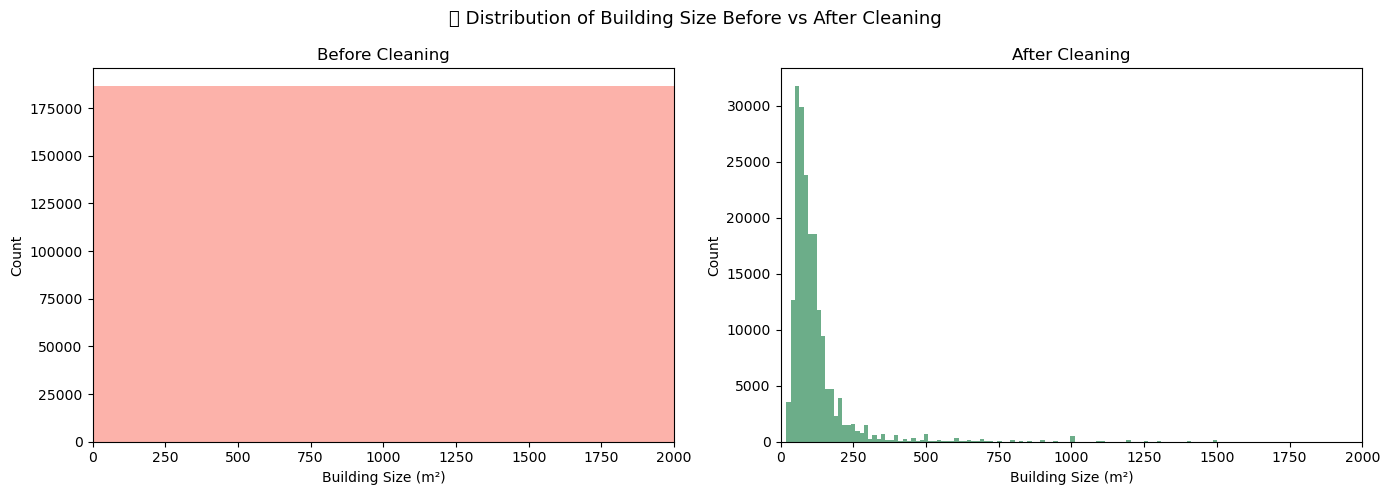

In [83]:
col = "building_size"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# قبل از تمیزسازی (داده خام)
df["building_size"].plot(kind="hist", bins=100, alpha=0.6, color="salmon", ax=axes[0])
axes[0].set_title("Before Cleaning")
axes[0].set_xlabel("Building Size (m²)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 2000)  # محدود به بازه منطقی

# بعد از تمیزسازی
df_clean["building_size"].plot(kind="hist", bins=100, alpha=0.7, color="seagreen", ax=axes[1])
axes[1].set_title("After Cleaning")
axes[1].set_xlabel("Building Size (m²)")
axes[1].set_ylabel("Count")
axes[1].set_xlim(0, 2000)

plt.suptitle("📊 Distribution of Building Size Before vs After Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

NaN بعد از پاکسازی اولیه: 184,084
ردیف‌های پر شده با نسبت building_size × 1.5: 90,745
✅ land_size نهایی:
count    190904.000000
mean        149.461902
std         136.452820
min          20.000000
1%           60.000000
5%           75.000000
25%         120.000000
50%         120.000000
75%         132.000000
95%         300.000000
99%         750.000000
max        5000.000000
Name: land_size, dtype: float64
NaN باقی‌مانده: 0


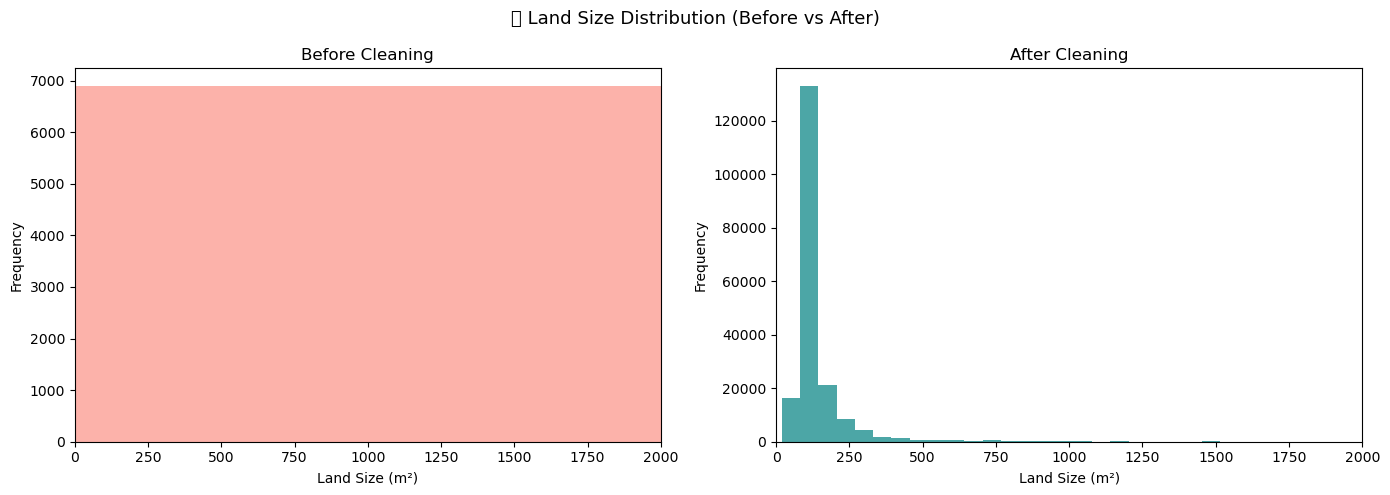

In [85]:
col = "land_size"

# 1️⃣ برگردوندن ستون به حالت خام (از df اصلی)
df_clean[col] = df[col]

# 2️⃣ حذف مقادیر پرت و غیرواقعی (کمتر از ۲۰ یا بیشتر از ۵۰۰۰ متر)
df_clean.loc[(df_clean[col] < 20) | (df_clean[col] > 5000), col] = np.nan
print(f"NaN بعد از پاکسازی اولیه: {df_clean[col].isna().sum():,}")

# 3️⃣ پر کردن هوشمند با building_size برای املاک مسکونی فروشی
mask_ratio = (
    (df_clean["cat2_slug"] == "residential-sell") &
    (df_clean[col].isna()) &
    (df_clean["building_size"].notna())
)
RATIO = 1.5  # نسبت میانگین زمین به بنا
df_clean.loc[mask_ratio, col] = df_clean.loc[mask_ratio, "building_size"] * RATIO
print(f"ردیف‌های پر شده با نسبت building_size × {RATIO}: {mask_ratio.sum():,}")

# 4️⃣ دوباره چک محدودیت‌ها بعد از نسبت
df_clean.loc[(df_clean[col] < 20) | (df_clean[col] > 5000), col] = np.nan

# 5️⃣ پر کردن با میانه‌ی (cat3_slug, neighborhood_slug)
pair = (
    df_clean.groupby(["cat3_slug","neighborhood_slug"])[col]
    .agg(["median","count"])
)
pair_med = pair.query("count >= 20")["median"].to_dict()

def fill_pair(row):
    if pd.isna(row[col]):
        key = (row["cat3_slug"], row["neighborhood_slug"])
        if key in pair_med and pd.notna(pair_med[key]):
            return pair_med[key]
    return row[col]

df_clean[col] = df_clean.apply(fill_pair, axis=1)

# 6️⃣ fallback با cat2_slug
cat2_med = df_clean.groupby("cat2_slug")[col].median().to_dict()
df_clean[col] = df_clean.apply(
    lambda r: cat2_med.get(r["cat2_slug"], np.nan) if pd.isna(r[col]) else r[col],
    axis=1
)

# 7️⃣ fallback نهایی با شهر (city_slug)
city_med = df_clean.groupby("city_slug")[col].median().to_dict()
df_clean[col] = df_clean.apply(
    lambda r: city_med.get(r["city_slug"], np.nan) if pd.isna(r[col]) else r[col],
    axis=1
)

# 8️⃣ گردکردن نهایی
df_clean[col] = df_clean[col].round(0)

print("✅ land_size نهایی:")
print(df_clean[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print("NaN باقی‌مانده:", df_clean[col].isna().sum())

# 9️⃣ رسم هیستوگرام قبل/بعد
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[col].plot(kind="hist", bins=80, alpha=0.6, color="salmon", ax=axes[0])
axes[0].set_title("Before Cleaning")
axes[0].set_xlabel("Land Size (m²)")
axes[0].set_xlim(0, 2000)

df_clean[col].plot(kind="hist", bins=80, alpha=0.7, color="teal", ax=axes[1])
axes[1].set_title("After Cleaning")
axes[1].set_xlabel("Land Size (m²)")
axes[1].set_xlim(0, 2000)

plt.suptitle("🏡 Land Size Distribution (Before vs After)", fontsize=13)
plt.tight_layout()
plt.show()

In [86]:
# انتخاب ستون‌های عددی
num_cols = df_clean.select_dtypes(include=["number"]).columns

# شمارش NaN در هر ستون
nan_report = (
    df_clean[num_cols]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "NaN_count"})
)
nan_report["NaN_percent"] = (nan_report["NaN_count"] / len(df_clean) * 100).round(2)

# مرتب‌سازی بر اساس درصد NaN
nan_report = nan_report.sort_values(by="NaN_percent", ascending=False).reset_index(drop=True)

print("📊 خلاصه‌ی ستون‌های عددی و وضعیت NaN:\n")
display(nan_report)

# تعداد ستون‌هایی که کاملاً پر شده‌اند
filled_count = (nan_report["NaN_count"] == 0).sum()
total_num = len(nan_report)
print(f"✅ از {total_num} ستون عددی، {filled_count} تا (یعنی {filled_count/total_num:.0%}) کاملاً پر شده‌اند.")


📊 خلاصه‌ی ستون‌های عددی و وضعیت NaN:



,column,NaN_count,NaN_percent
0,transformed_credit,162606,85.18
1,transformed_rent,162606,85.18
2,transformable_rent,107291,56.20
3,transformable_credit,107049,56.07
4,location_radius,105180,55.10
5,price_value,90223,47.26
6,unit_per_floor,34761,18.21
7,floor,29595,15.50
8,construction_year,12286,6.44
9,location_longitude,32,0.02


✅ از 17 ستون عددی، 6 تا (یعنی 35%) کاملاً پر شده‌اند.


In [87]:
num_cols = df_clean.select_dtypes(include=["number"]).columns
df_num = df_clean[num_cols]

print(f"tedad soton adadi: {len(num_cols)}")
print(num_cols.tolist())

tedad soton adadi: 17
['rent_value', 'price_value', 'credit_value', 'transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent', 'land_size', 'building_size', 'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor', 'construction_year', 'location_latitude', 'location_longitude', 'location_radius']


In [88]:
df_num_reduced = df_num.loc[:, df_num.isna().mean() < 0.5]
print("✅ ستون‌های نگه‌داشته شده برای heatmap:", df_num_reduced.columns.tolist())

✅ ستون‌های نگه‌داشته شده برای heatmap: ['rent_value', 'price_value', 'credit_value', 'land_size', 'building_size', 'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor', 'construction_year', 'location_latitude', 'location_longitude']


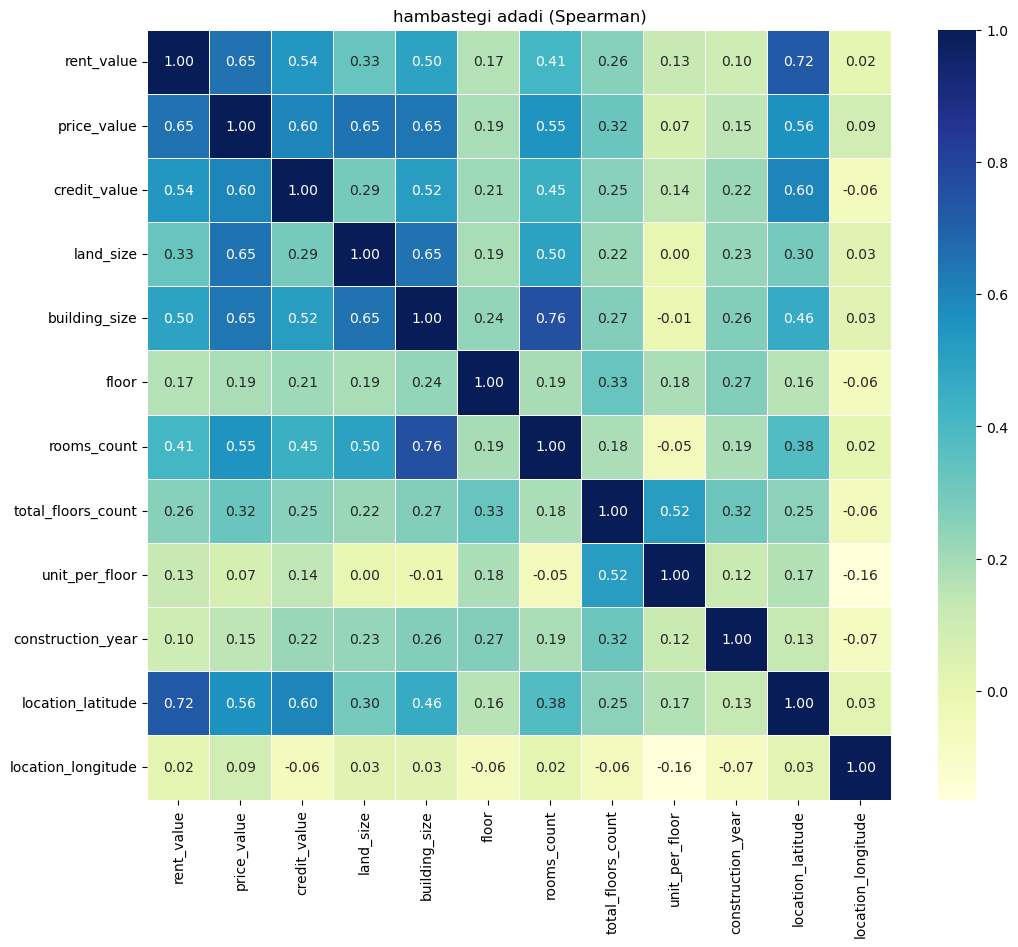

In [90]:
corr = df_num_reduced.corr(method='spearman')  # Spearman بهتره چون داده‌ها نرمال نیستن

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("hambastegi adadi (Spearman)")
plt.show()

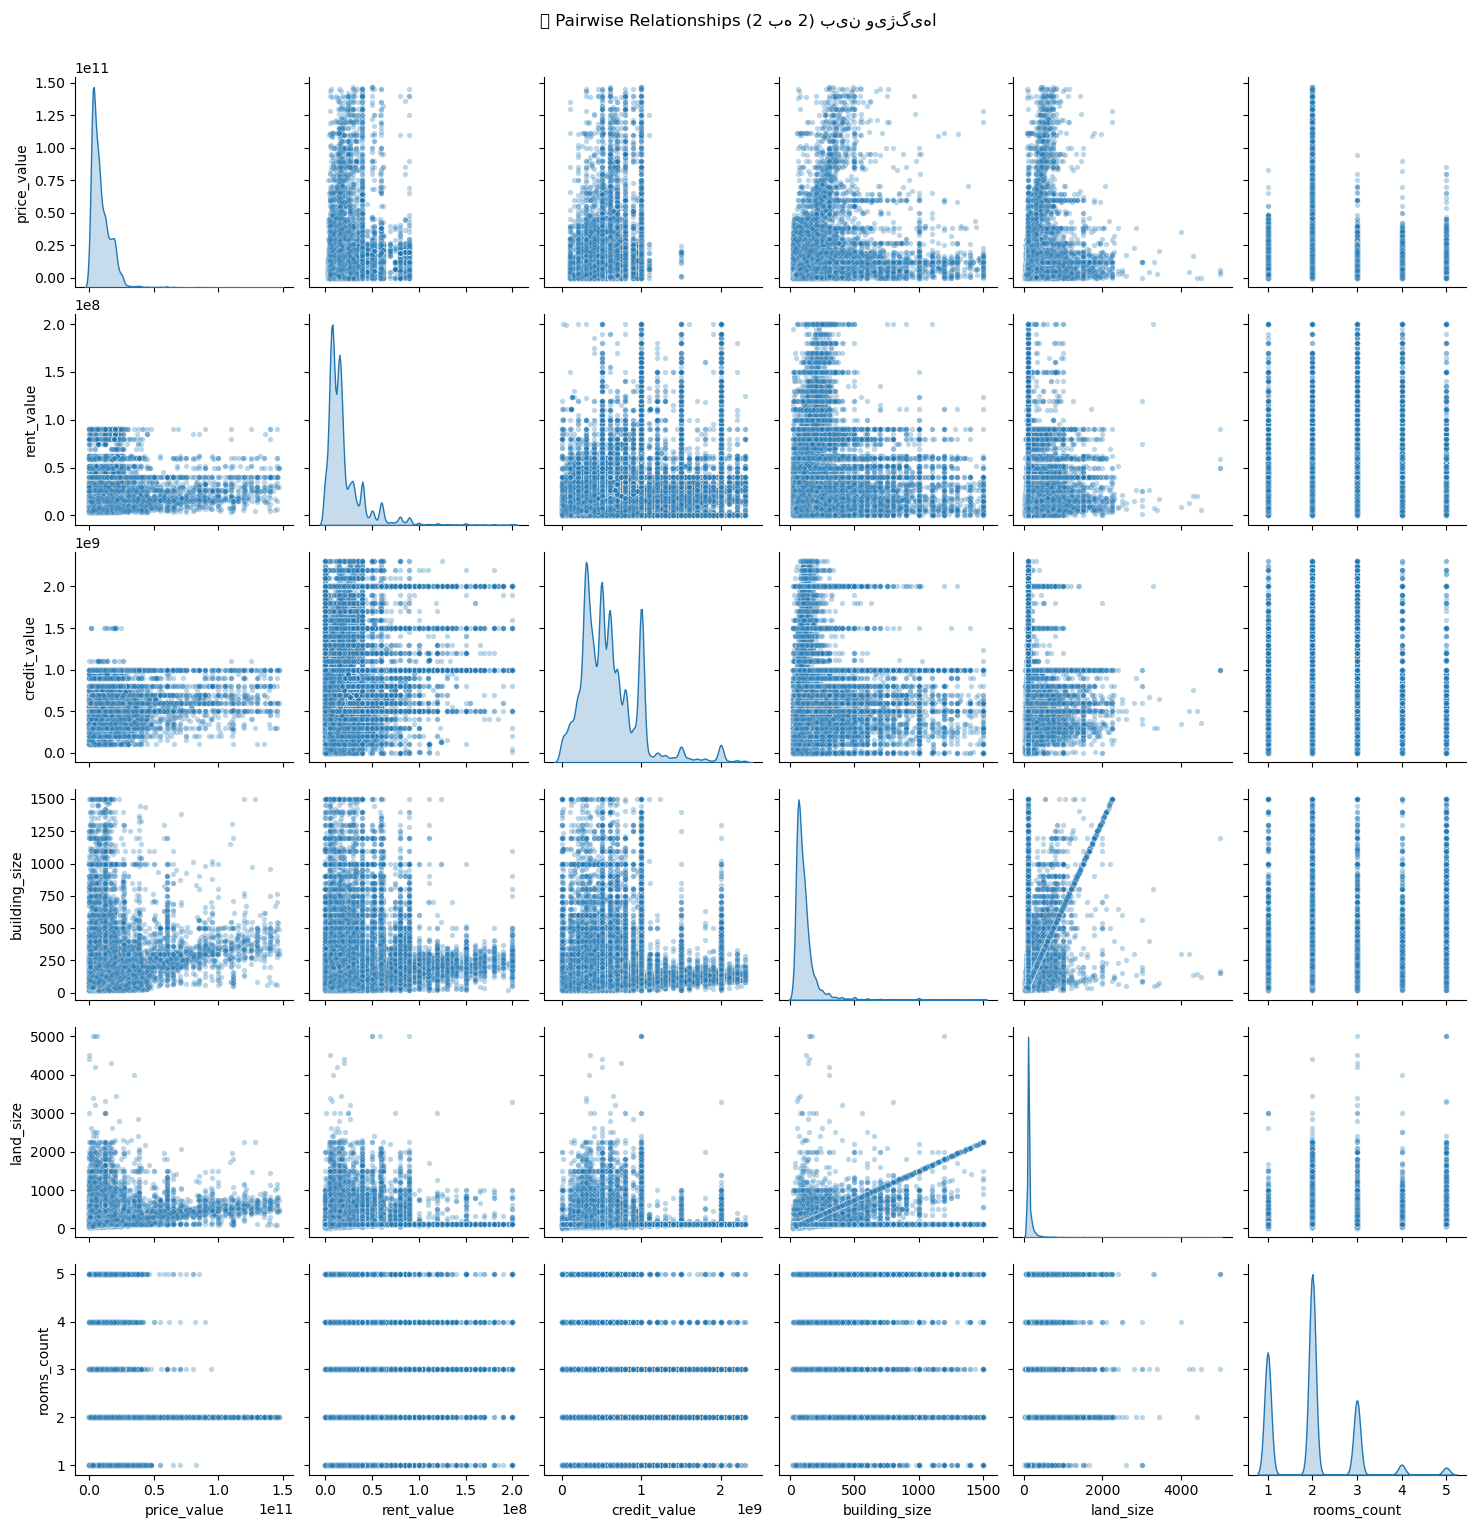

In [91]:
cols = ["price_value", "rent_value", "credit_value", "building_size", "land_size", "rooms_count"]

sns.pairplot(df_clean[cols], diag_kind="kde", plot_kws={"alpha": 0.3, "s": 15})
plt.suptitle("📊 Pairwise Relationships (2 به 2) بین ویژگی‌ها", y=1.02)
plt.show()

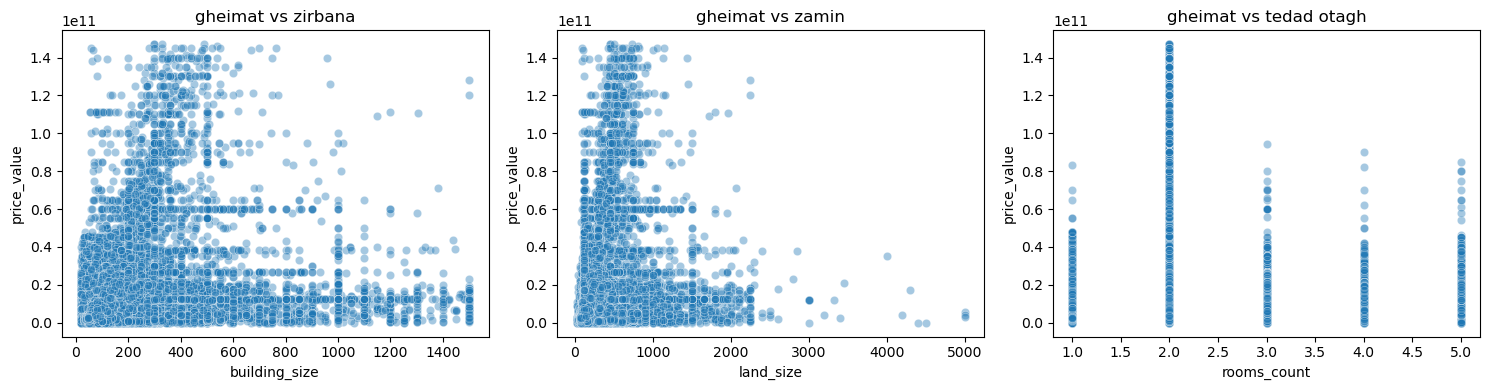

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df_clean, x="building_size", y="price_value", alpha=0.4, ax=axes[0])
sns.scatterplot(data=df_clean, x="land_size", y="price_value", alpha=0.4, ax=axes[1])
sns.scatterplot(data=df_clean, x="rooms_count", y="price_value", alpha=0.4, ax=axes[2])

axes[0].set_title("gheimat vs zirbana")
axes[1].set_title("gheimat vs zamin")
axes[2].set_title("gheimat vs tedad otagh")
plt.tight_layout()
plt.show()

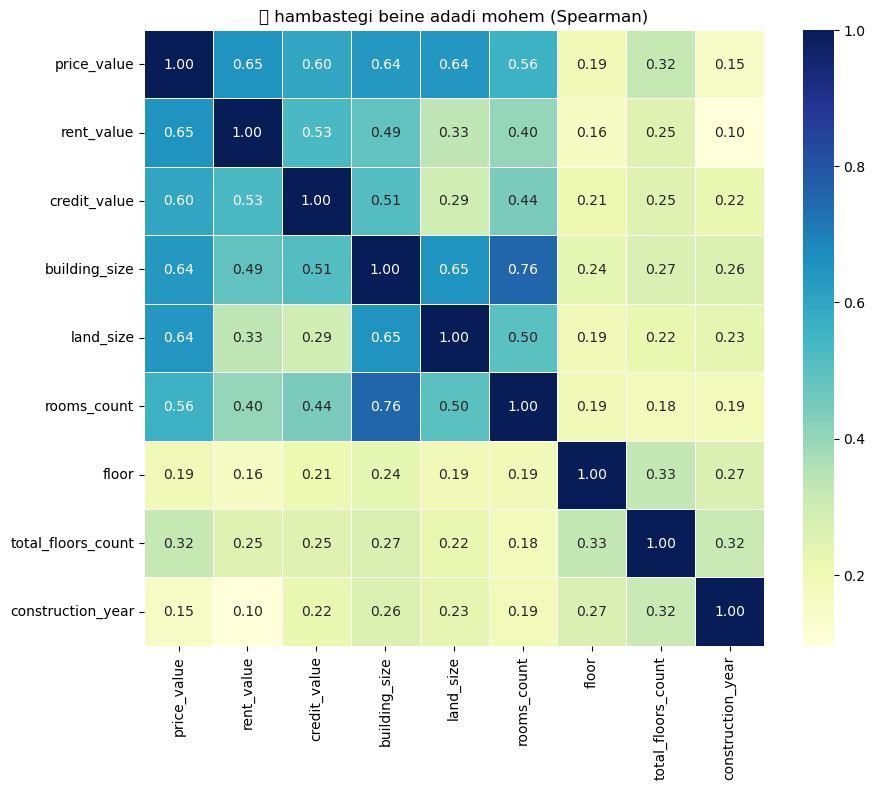

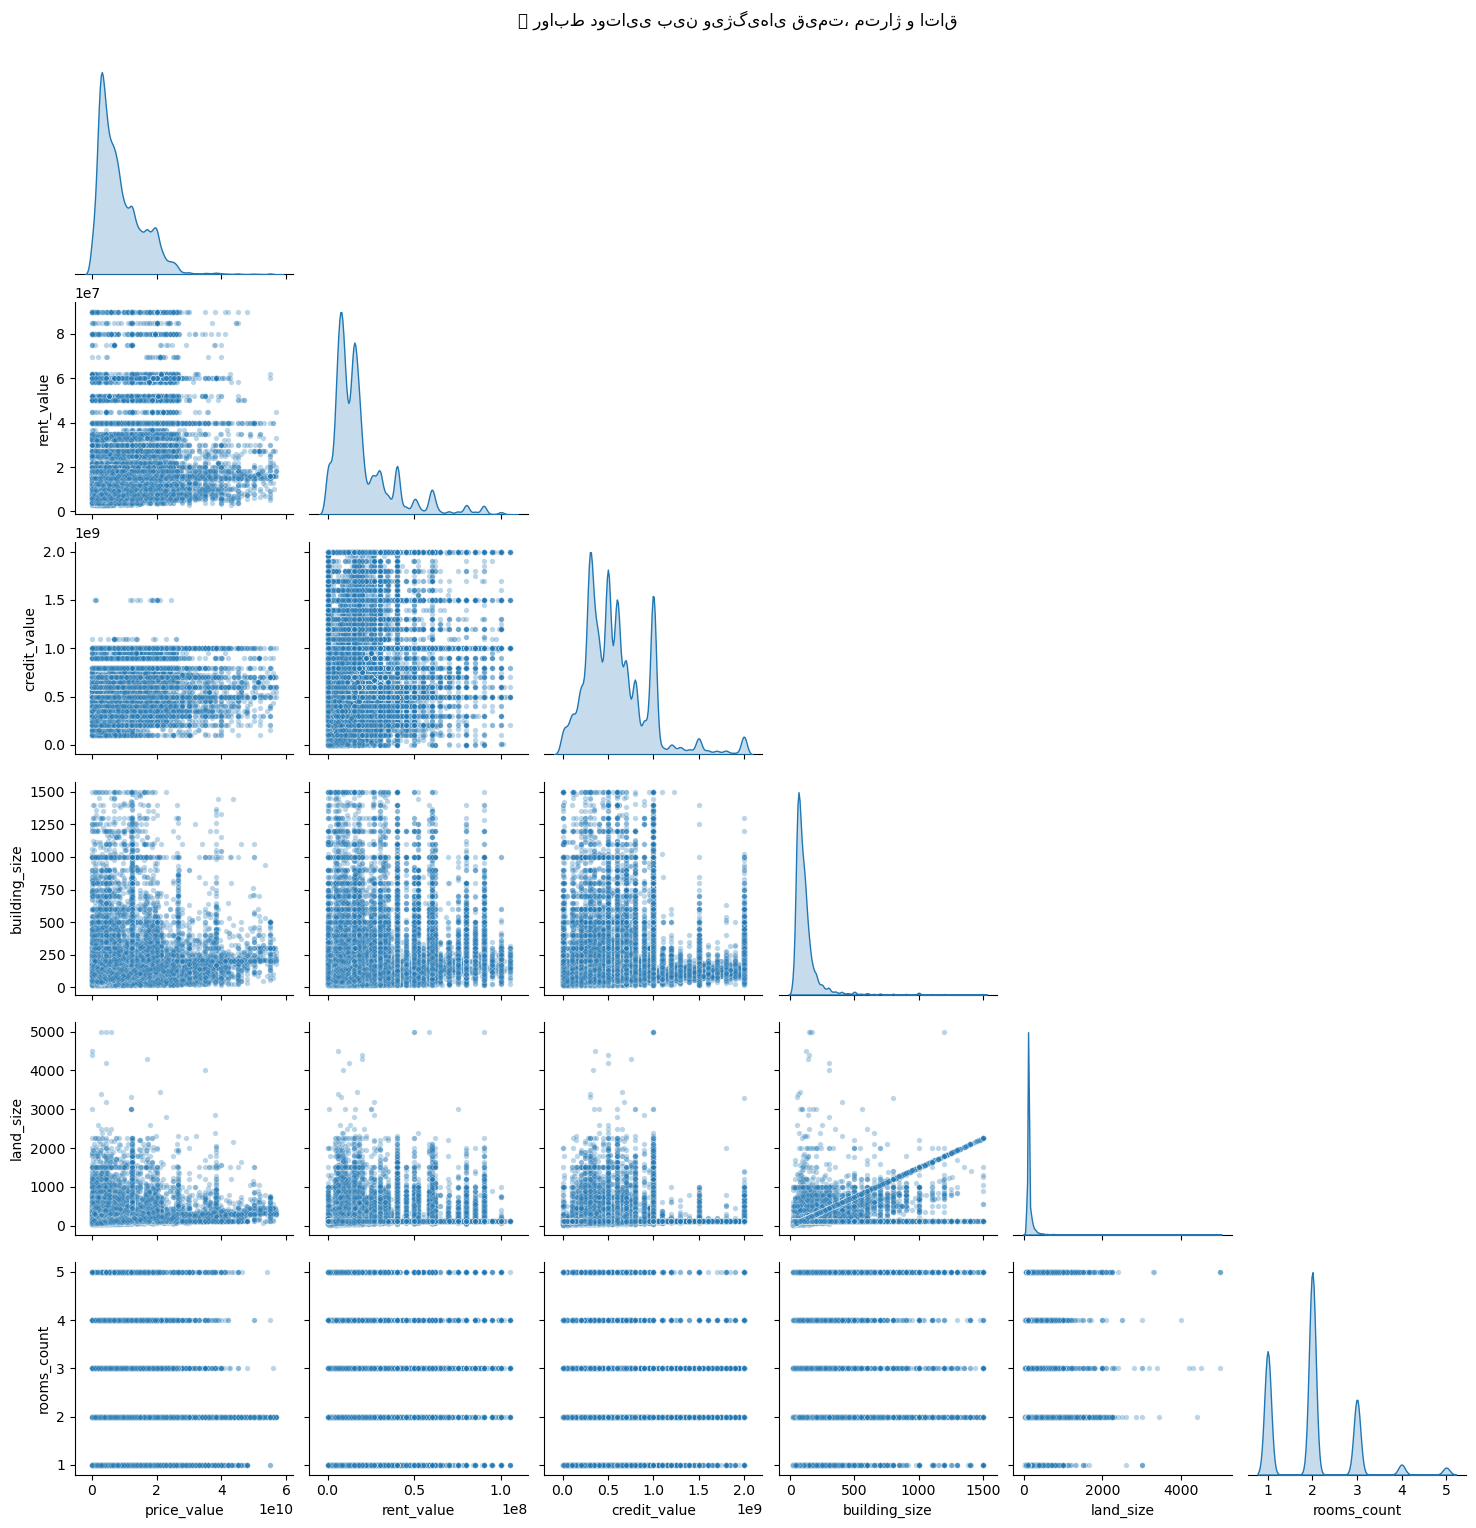

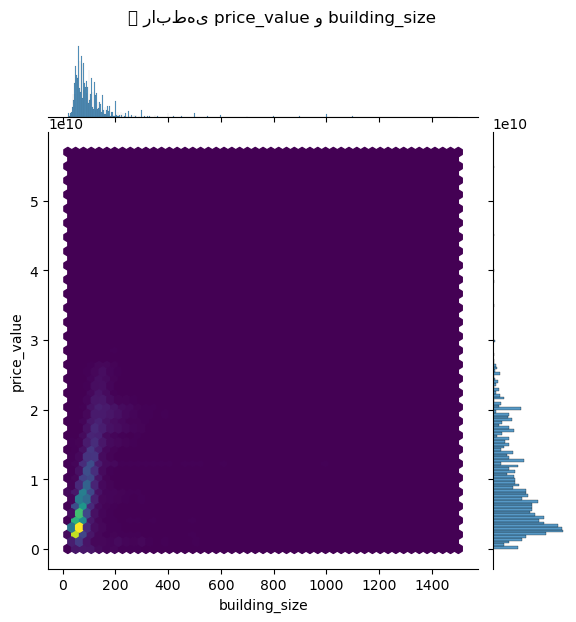

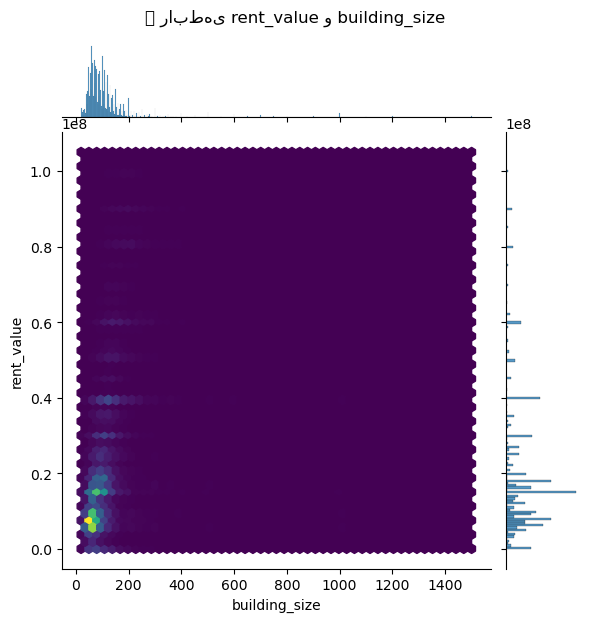

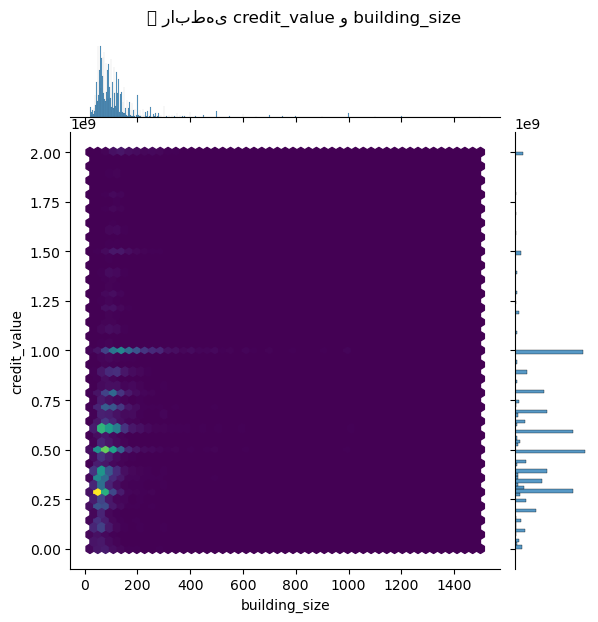

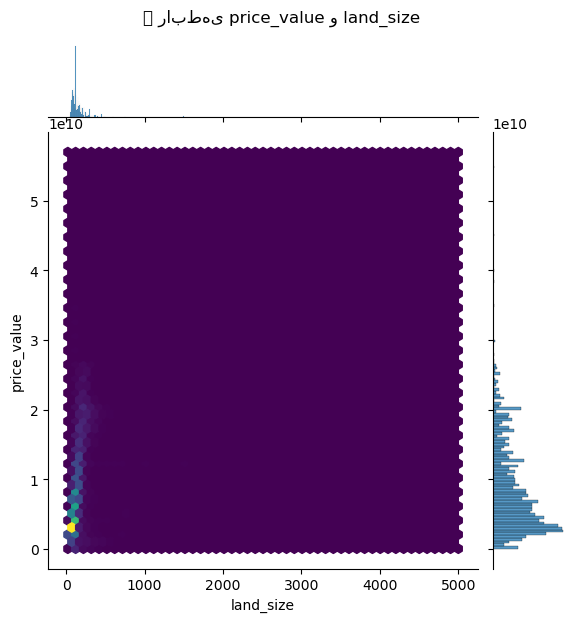

In [93]:
# ۱️⃣ انتخاب ویژگی‌های عددی مهم برای تحلیل
key_cols = [
    "price_value", "rent_value", "credit_value",
    "building_size", "land_size", "rooms_count",
    "floor", "total_floors_count", "construction_year"
]

df_num = df_clean[key_cols].copy()

# حذف مقادیر پرت خیلی زیاد برای خوانایی
for c in ["price_value", "rent_value", "credit_value"]:
    upper = df_num[c].quantile(0.99)
    df_num.loc[df_num[c] > upper, c] = np.nan

# ----------------------------------------------------------------
# 🔥 ۲️⃣ Heatmap — ماتریس همبستگی بین همه‌ی ویژگی‌های عددی مهم
plt.figure(figsize=(10,8))
corr = df_num.corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("🔥 hambastegi beine adadi mohem (Spearman)")
plt.show()

# ----------------------------------------------------------------
# 🌈 ۳️⃣ Pairplot — بررسی روابط ۲به۲ بین ویژگی‌های کلیدی
sns.pairplot(
    df_num[["price_value","rent_value","credit_value","building_size","land_size","rooms_count"]],
    diag_kind="kde", corner=True, plot_kws={"alpha":0.3, "s":15}
)
plt.suptitle("📊 روابط دوتایی بین ویژگی‌های قیمت، متراژ و اتاق", y=1.02)
plt.show()

# ----------------------------------------------------------------
# 🎯 ۴️⃣ Jointplots — تمرکز روی روابط کلیدی قیمت/رهن/اجاره با متراژ
pairs = [
    ("price_value", "building_size"),
    ("rent_value", "building_size"),
    ("credit_value", "building_size"),
    ("price_value", "land_size")
]

for x, y in pairs:
    sns.jointplot(data=df_num, x=y, y=x, kind="hex", cmap="viridis")
    plt.suptitle(f"📈 رابطه‌ی {x} و {y}", y=1.03)
    plt.show()

## به دلیل آنکه ستون های ترنسفورم ها بر اساس فرمول های ریاضی نوشته شده اند و فرمول ها در دسترس نیستند تصمیم بر آن شد که این 2 ستون حذف گردند و بجای آن اگر بخواهیم از این ستون ها استفاده کنیم بایستی که خودمان فرمول محاسباتی ریاضی آن را حساب کنیم 

In [97]:
cols_drop = ["transformable_credit","transformed_credit","transformable_rent","transformed_rent"]
kept = [c for c in cols_drop if c in df_clean.columns]
df_clean = df_clean.drop(columns=kept)
print("🗑️ حذف شد:", kept)


🗑️ حذف شد: ['transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent']


In [99]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190904 entries, 0 to 190903
Data columns (total 40 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                190904 non-null  object 
 1   cat3_slug                190904 non-null  object 
 2   city_slug                190904 non-null  object 
 3   neighborhood_slug        190904 non-null  object 
 4   created_at_month         190904 non-null  object 
 5   user_type                79819 non-null   object 
 6   description              190904 non-null  object 
 7   title                    190898 non-null  object 
 8   rent_mode                84241 non-null   object 
 9   rent_value               190904 non-null  float64
 10  rent_type                35426 non-null   object 
 11  price_mode               99451 non-null   object 
 12  price_value              100681 non-null  float64
 13  credit_mode              84241 non-null   object 
 14  cred

In [100]:
# 1️⃣ تعداد سطر و ستون
print("📏 شکل داده‌ها:")
print(f"df:        {df.shape}")
print(f"df_clean:  {df_clean.shape}")
print("-" * 40)

# 2️⃣ بررسی تفاوت ستون‌ها
orig_cols = set(df.columns)
clean_cols = set(df_clean.columns)

removed_cols = sorted(list(orig_cols - clean_cols))
added_cols   = sorted(list(clean_cols - orig_cols))
same_cols    = sorted(list(orig_cols & clean_cols))

print(f"🧹 ستون‌های حذف‌شده ({len(removed_cols)}):")
print(removed_cols if removed_cols else "❌ هیچ‌کدام حذف نشده‌اند")

print(f"\n✨ ستون‌های اضافه‌شده ({len(added_cols)}):")
print(added_cols if added_cols else "❌ هیچ‌کدام اضافه نشده‌اند")

print(f"\n📋 ستون‌های مشترک ({len(same_cols)}): {same_cols[:10]}{' ...' if len(same_cols)>10 else ''}")
print("-" * 40)

# 3️⃣ بررسی تعداد سطرهای متفاوت (درصورت حذف ردیف)
if len(df) != len(df_clean):
    print(f"⚠️ تفاوت در تعداد ردیف‌ها: df({len(df)}) → df_clean({len(df_clean)})")
else:
    print("✅ تعداد ردیف‌ها تغییری نکرده.")

# 4️⃣ بررسی نوع داده‌ها در ستون‌های مشترک
diff_types = []
for c in same_cols:
    if df[c].dtype != df_clean[c].dtype:
        diff_types.append((c, df[c].dtype, df_clean[c].dtype))

if diff_types:
    print("\n🔄 تغییر نوع داده در ستون‌ها:")
    for c, t1, t2 in diff_types:
        print(f" - {c}: {t1} → {t2}")
else:
    print("\n✅ هیچ تغییر نوع داده‌ای در ستون‌های مشترک وجود ندارد.")


📏 شکل داده‌ها:
df:        (190904, 44)
df_clean:  (190904, 40)
----------------------------------------
🧹 ستون‌های حذف‌شده (4):
['transformable_credit', 'transformable_rent', 'transformed_credit', 'transformed_rent']

✨ ستون‌های اضافه‌شده (0):
❌ هیچ‌کدام اضافه نشده‌اند

📋 ستون‌های مشترک (40): ['building_direction', 'building_size', 'cat2_slug', 'cat3_slug', 'city_slug', 'construction_year', 'created_at_month', 'credit_mode', 'credit_value', 'deed_type'] ...
----------------------------------------
✅ تعداد ردیف‌ها تغییری نکرده.

🔄 تغییر نوع داده در ستون‌ها:
 - floor: float64 → Int64
 - rooms_count: float64 → Int64
 - total_floors_count: float64 → Int64
 - unit_per_floor: float64 → Int64


In [101]:
df_old = pd.read_csv(r"C:\Users\kourosh\Desktop\daqiqe Project\1\tehran.csv")

In [102]:
# 1️⃣ تعداد سطر و ستون
print("📏 شکل داده‌ها:")
print(f"df:        {df.shape}")
print(f"df_clean:  {df_clean.shape}")
print("-" * 40)

# 2️⃣ بررسی تفاوت ستون‌ها
orig_cols = set(df_old.columns)
clean_cols = set(df_clean.columns)

removed_cols = sorted(list(orig_cols - clean_cols))
added_cols   = sorted(list(clean_cols - orig_cols))
same_cols    = sorted(list(orig_cols & clean_cols))

print(f"🧹 ستون‌های حذف‌شده ({len(removed_cols)}):")
print(removed_cols if removed_cols else "❌ هیچ‌کدام حذف نشده‌اند")

print(f"\n✨ ستون‌های اضافه‌شده ({len(added_cols)}):")
print(added_cols if added_cols else "❌ هیچ‌کدام اضافه نشده‌اند")

print(f"\n📋 ستون‌های مشترک ({len(same_cols)}): {same_cols[:10]}{' ...' if len(same_cols)>10 else ''}")
print("-" * 40)

# 3️⃣ بررسی تعداد سطرهای متفاوت (درصورت حذف ردیف)
if len(df) != len(df_clean):
    print(f"⚠️ تفاوت در تعداد ردیف‌ها: df({len(df)}) → df_clean({len(df_clean)})")
else:
    print("✅ تعداد ردیف‌ها تغییری نکرده.")

# 4️⃣ بررسی نوع داده‌ها در ستون‌های مشترک
diff_types = []
for c in same_cols:
    if df[c].dtype != df_clean[c].dtype:
        diff_types.append((c, df[c].dtype, df_clean[c].dtype))

if diff_types:
    print("\n🔄 تغییر نوع داده در ستون‌ها:")
    for c, t1, t2 in diff_types:
        print(f" - {c}: {t1} → {t2}")
else:
    print("\n✅ هیچ تغییر نوع داده‌ای در ستون‌های مشترک وجود ندارد.")


📏 شکل داده‌ها:
df:        (190904, 44)
df_clean:  (190904, 40)
----------------------------------------
🧹 ستون‌های حذف‌شده (20):
['cost_per_extra_person', 'extra_person_capacity', 'has_barbecue', 'has_electricity', 'has_gas', 'has_jacuzzi', 'has_pool', 'has_sauna', 'has_security_guard', 'has_water', 'property_type', 'regular_person_capacity', 'rent_price_at_weekends', 'rent_price_on_regular_days', 'rent_price_on_special_days', 'rent_to_single', 'transformable_credit', 'transformable_rent', 'transformed_credit', 'transformed_rent']

✨ ستون‌های اضافه‌شده (0):
❌ هیچ‌کدام اضافه نشده‌اند

📋 ستون‌های مشترک (40): ['building_direction', 'building_size', 'cat2_slug', 'cat3_slug', 'city_slug', 'construction_year', 'created_at_month', 'credit_mode', 'credit_value', 'deed_type'] ...
----------------------------------------
✅ تعداد ردیف‌ها تغییری نکرده.

🔄 تغییر نوع داده در ستون‌ها:
 - floor: float64 → Int64
 - rooms_count: float64 → Int64
 - total_floors_count: float64 → Int64
 - unit_per_floor: f

In [98]:
df_clean.to_csv("cleaned_full_numeric.csv", index=False)

In [103]:
df_clean.to_pickle("cleaned_full_numeric.pkl")

In [105]:
df_clean.head(10)

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,is_rebuilt,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,building_direction,floor_material,location_latitude,location_longitude,location_radius
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,agency,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,30000000.0,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,35.773281,51.442539,500.0
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,fixed,26000000.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
2,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,fixed,95000000.0,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,35.791080,51.426540,NaN
3,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,agency,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,12000000.0,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
4,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,agency,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر ب...,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ار...,free,27000000.0,...,True,NaN,NaN,NaN,squat_seat,south,NaN,35.733952,51.380608,500.0
5,residential-sell,plot-old,tehran,shahrak-naft-district5,2024-07-01 00:00:00,NaN,۷۰۰ متر باغ ۱۰۰ ساله،\nواقع در روستای زیبای رن...,تهاتر یا فروش باغی زیبا در روستای زیبای رندان,NaN,15000000.0,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,35.890186,51.280197,NaN
6,residential-sell,apartment-sell,tehran,kamraniyeh,2024-11-01 00:00:00,NaN,سازه‌ایی‌بااصالت‌همجوارسفارت\nدربهترین‌فرعی‌بر...,کامرانیه‌شمالی‌ویوابدی۴۰۰متر۳جهت‌نور,NaN,85000000.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,35.806137,51.462595,NaN
7,residential-rent,house-villa-rent,tehran,shemiran-no,2024-08-01 00:00:00,NaN,سوییت 48متر یک خوابه سرویس کامل شمالی نورگیر ع...,سوییت 48متر یک خوابه,fixed,7000000.0,...,False,water_heater,heater,water_cooler,squat,north,carpet,35.751793,51.500717,NaN
8,residential-rent,apartment-rent,tehran,majidiyeh,2024-11-01 00:00:00,agency,60 متر آپارتمان \n\nیک خوابه \n\nطبقه دوم \n\n...,60 متر یک خوابه,fixed,15000000.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,35.735909,51.464397,500.0
9,residential-sell,apartment-sell,tehran,tohid,2024-10-01 00:00:00,NaN,این واحد بدلیل نیاز مالی زیر قیمت بفروش میرسد ...,۱۱۰ متر * کلید نخورده * ستارخان,NaN,14000000.0,...,False,package,shoofaj,water_cooler,squat_seat,south,stone,35.705175,51.372757,NaN


---

## Stage C — Non-numeric Column Imputation

# پر کردن ستون های غیرعددی و حرفی و پر کردن بر اساس BOOL و یا پر کردن بر اساس ستون های مشترک

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_pickle(r"C:\Users\kourosh\Desktop\daqiqe Project\اصلاح clean\cleaned_full_numeric.pkl")

In [4]:
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,is_rebuilt,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,building_direction,floor_material,location_latitude,location_longitude,location_radius
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,agency,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,30000000.0,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,35.773281,51.442539,500.0
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,fixed,26000000.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
2,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,fixed,95000000.0,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,35.791080,51.426540,NaN
3,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,agency,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,12000000.0,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
4,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,agency,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر ب...,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ار...,free,27000000.0,...,True,NaN,NaN,NaN,squat_seat,south,NaN,35.733952,51.380608,500.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190904 entries, 0 to 190903
Data columns (total 40 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                190904 non-null  object 
 1   cat3_slug                190904 non-null  object 
 2   city_slug                190904 non-null  object 
 3   neighborhood_slug        190904 non-null  object 
 4   created_at_month         190904 non-null  object 
 5   user_type                79819 non-null   object 
 6   description              190904 non-null  object 
 7   title                    190898 non-null  object 
 8   rent_mode                84241 non-null   object 
 9   rent_value               190904 non-null  float64
 10  rent_type                35426 non-null   object 
 11  price_mode               99451 non-null   object 
 12  price_value              100681 non-null  float64
 13  credit_mode              84241 non-null   object 
 14  cred

In [6]:
# خلاصه از انواع داده
df.dtypes.value_counts()

# لیست ستون‌های غیر عددی
object_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("🧩 ستون‌های object:", len(object_cols))
print(object_cols)


🧩 ستون‌های object: 21
['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month', 'user_type', 'description', 'title', 'rent_mode', 'rent_type', 'price_mode', 'credit_mode', 'rent_credit_transform', 'transformable_price', 'deed_type', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'building_direction', 'floor_material']


In [7]:
df_copy = df.copy()  # همان دیتای تمیزِ عددی-شده‌تان
non_num_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

print("تعداد ستون‌های غیرعددی:", len(non_num_cols))
non_num_cols


تعداد ستون‌های غیرعددی: 27


['cat2_slug',
 'cat3_slug',
 'city_slug',
 'neighborhood_slug',
 'created_at_month',
 'user_type',
 'description',
 'title',
 'rent_mode',
 'rent_type',
 'price_mode',
 'credit_mode',
 'rent_credit_transform',
 'transformable_price',
 'deed_type',
 'has_business_deed',
 'has_balcony',
 'has_elevator',
 'has_warehouse',
 'has_parking',
 'is_rebuilt',
 'has_warm_water_provider',
 'has_heating_system',
 'has_cooling_system',
 'has_restroom',
 'building_direction',
 'floor_material']

In [8]:
def show_unique_summary(df, cols, max_display=15, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    summary = {}
    for c in cols:
        if c in exclude_cols:
            continue
        
        total = len(df)
        n_missing = df[c].isna().sum()
        missing_percent = round((n_missing / total) * 100, 2)

        uniq_vals = df[c].dropna().unique()
        n_unique = len(uniq_vals)
        examples = uniq_vals[:max_display]

        summary[c] = {
            "تعداد_مقادیر_یکتا": n_unique,
            "درصد_مقادیر_خالی": missing_percent,
            "تعداد_کل_ردیف‌ها": total,
            "تعداد_مقادیر_خالی": n_missing,
            "نمونه_مقادیر": examples
        }
    return summary


# ✳️ استفاده:
exclude_cols = ["description", "title"]  # این دو تا رو فعلاً کنار می‌گذاریم
non_num_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

summary_nonnum = show_unique_summary(df, non_num_cols, exclude_cols=exclude_cols)

# نمایش خلاصه
for col, info in summary_nonnum.items():
    print(f"\n🔹 {col}")
    print(f"تعداد مقادیر یکتا: {info['تعداد_مقادیر_یکتا']}")
    print(f"درصد مقادیر خالی: {info['درصد_مقادیر_خالی']}%  ({info['تعداد_مقادیر_خالی']} از {info['تعداد_کل_ردیف‌ها']})")
    print("نمونه‌ها:", list(info['نمونه_مقادیر']))


🔹 cat2_slug
تعداد مقادیر یکتا: 6
درصد مقادیر خالی: 0.0%  (0 از 190904)
نمونه‌ها: ['residential-sell', 'residential-rent', 'commercial-rent', 'commercial-sell', 'real-estate-services', 'temporary-rent']

🔹 cat3_slug
تعداد مقادیر یکتا: 16
درصد مقادیر خالی: 0.0%  (0 از 190904)
نمونه‌ها: ['apartment-sell', 'apartment-rent', 'office-rent', 'plot-old', 'house-villa-rent', 'shop-rent', 'shop-sell', 'industry-agriculture-business-rent', 'office-sell', 'presell', 'house-villa-sell', 'suite-apartment', 'villa', 'industry-agriculture-business-sell', 'partnership']

🔹 city_slug
تعداد مقادیر یکتا: 1
درصد مقادیر خالی: 0.0%  (0 از 190904)
نمونه‌ها: ['tehran']

🔹 neighborhood_slug
تعداد مقادیر یکتا: 346
درصد مقادیر خالی: 0.0%  (0 از 190904)
نمونه‌ها: ['gholhak', 'tohid', 'elahiyeh', 'dardasht', 'gisha', 'shahrak-naft-district5', 'kamraniyeh', 'shemiran-no', 'majidiyeh', 'west-tehranpars', 'tehran-kerman', 'abouzar', 'ekhtiyariyeh', 'fallah', 'jordan']

🔹 created_at_month
تعداد مقادیر یکتا: 34
درصد مق

In [9]:
summary_list = []
for col, info in summary_nonnum.items():
    summary_list.append({
        "ستون": col,
        "تعداد_یکتا": info["تعداد_مقادیر_یکتا"],
        "درصد_خالی": info["درصد_مقادیر_خالی"],
        "تعداد_خالی": info["تعداد_مقادیر_خالی"],
        "نمونه_مقادیر": ", ".join(map(str, info["نمونه_مقادیر"]))
    })

df_summary = pd.DataFrame(summary_list).sort_values("درصد_خالی", ascending=False)
df_summary.head(20)  # فقط ۲۰ تای اول رو ببین


,ستون,تعداد_یکتا,درصد_خالی,تعداد_خالی,نمونه_مقادیر
13,has_business_deed,2,97.43,186004,"True, False"
7,rent_type,2,81.44,155478,"rent_credit, full_credit"
12,deed_type,5,69.16,132030,"single_page, other, written_agreement, multi_p..."
5,user_type,2,58.19,111085,"agency, personal"
11,transformable_price,2,55.89,106704,"False, True"
10,rent_credit_transform,2,55.87,106662,"False, True"
6,rent_mode,3,55.87,106663,"fixed, free, negotiable"
9,credit_mode,3,55.87,106663,"fixed, free, negotiable"
23,building_direction,5,54.92,104849,"south, north, west, east, unselect"
19,has_warm_water_provider,4,52.01,99297,"water_heater, package, powerhouse, unselect"


In [10]:
df_summary.to_csv("non_numeric_unique_summary_with_missing.csv", index=False)

In [11]:
# ✅ بکاپ از دیتافریم اصلی قبل از هر نوع پر کردن
df_backup = df.copy()
print("✅ نسخه‌ی پشتیبان گرفته شد (df_backup)")


✅ نسخه‌ی پشتیبان گرفته شد (df_backup)


---
<div dir="rtl">
    بعدا برای قسمت classification مجدد از دیتای کل استفاده میشود و قسمت user_type پر نمشود
    </div>

---
<div dir="rtl">

۱. ابتدا یک نسخه پشتیبان از ستون user_type ذخیره می‌شود تا داده‌های اولیه حفظ شود.  
۲. سطرهایی که user_type آن‌ها مقدار ندارد (خالی یا NaN) شناسایی می‌شوند.  
۳. اگر مقدار cat2_slug شامل residential باشد، مقدار user_type برای آن سطر personal تعیین می‌شود؛ اگر commercial یا real-estate باشد، مقدار agency قرار داده می‌شود.  
۴. سطرهایی که هنوز user_type ندارند، با رایج‌ترین مقدار این ستون نسبت به هر cat2_slug کامل می‌شوند.  
۵. اگر پس از همه مراحل هنوز user_type خالی باقی بود، مقدار personal برای آن گذاشته می‌شود.  
۶. در انتها تعداد هر کدام از مقادیر user_type برای بررسی خروجی نمایش داده می‌شود.

</div>

In [12]:
# --- پر کردن ستون user_type به‌صورت هوشمند و سریع ---

df["user_type_backup"] = df["user_type"].copy()

# 1️⃣ شناسایی سطرهای خالی
mask_missing = df["user_type"].isna()

# 2️⃣ قواعد منطقی بر اساس cat2_slug
mask_residential = df["cat2_slug"].str.contains("residential", na=False)
mask_commercial  = df["cat2_slug"].str.contains("commercial|real-estate", na=False)

# 3️⃣ ابتدا بر اساس قواعد منطقی پر کن
df.loc[mask_missing & mask_residential, "user_type"] = "personal"
df.loc[mask_missing & mask_commercial,  "user_type"] = "agency"

# 4️⃣ برای باقیمانده‌ها (که هیچ‌کدوم از بالا نبودند) از mode گروهی استفاده کن
mode_map_user = (
    df.dropna(subset=["user_type"])
      .groupby("cat2_slug")["user_type"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df.loc[df["user_type"].isna(), "user_type"] = df.loc[df["user_type"].isna(), "cat2_slug"].map(mode_map_user)

# 5️⃣ fallback نهایی
df["user_type"] = df["user_type"].fillna("personal")

# ✅ گزارش نهایی
print("✅ user_type پر شد (هوشمند + mode cat2_slug + fallback='personal')")
print(df["user_type"].value_counts(dropna=False))


✅ user_type پر شد (هوشمند + mode cat2_slug + fallback='personal')
user_type
personal    96093
agency      94811
Name: count, dtype: int64


---
<div dir="rtl">

۱. ابتدا یک نسخهٔ پشتیبان از ستون rent_mode ذخیره می‌شود تا داده‌های اولیه از دست نرود و امکان بررسی وضعیت قبل و بعد اصلاح وجود داشته باشد.
۲. برای هر دسته‌بندی cat3_slug، پرتکرارترین مقدار rent_mode (mode) استخراج می‌شود. این باعث می‌شود برای خانه‌های همان دسته، از رایج‌ترین حالت اجاره استفاده کنیم و داده‌ها واقعی‌تر شوند.
۳. ردیف‌هایی که نوع آگهی فروش هستند یا از قبل مقدار rent_mode دارند، کنار گذاشته می‌شوند و فقط ردیف‌های فاقد مقدار و غیر فروش برای مقداردهی انتخاب می‌شوند. با این کار مطمئن می‌شویم داده‌های تاییدشده‌ قبلی یا آگهی فروش تغییر نمی‌کنند.
۴. برای هر ردیف انتخاب‌شده، مقدار rent_mode بر اساس mode همان دسته cat3_slug قرار داده می‌شود تا جایگذاری به‌صورت هوشمند و مبتنی بر رفتار داده باشد.
۵. اگر پس از همه این مراحل، باز هم مقدار خالی وجود داشت (در دسته‌هایی که هیچ mode معتبر ندارند)، مقدار پیش‌فرض fixed برای آن ثبت می‌شود تا هیچ ردیفی خالی نماند.
۶. در انتها، تعداد مقادیر تهی باقی‌مانده محاسبه و نمایش داده می‌شود تا کیفیت و صحت عملیات تکمیل بخوبی بررسی شود.

این روش به کمک ترکیب منطق دسته‌بندی، داده پرتکرار هر دسته و مقدار پیش‌فرض، کیفیت و منطق داده‌های rent_mode را تا جای ممکن حفظ می‌کند و اساسی‌ترین خطاهای ناشی از داده‌های ناقص را رفع می‌کند.
</div>


In [13]:
# پشتیبان از ستون اصلی
df["rent_mode_backup"] = df["rent_mode"].copy()

# 1️⃣ استخراج mode برای هر cat3_slug
# یعنی ببینیم برای هر دسته cat3_slug بیشترین مقدار rent_mode چی بوده
mode_map_mode = (
    df.dropna(subset=["rent_mode"])
      .groupby("cat3_slug")["rent_mode"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "fixed")
)

# 2️⃣ شرط‌ها
mask_sell = df["cat2_slug"].str.contains("sell", na=False)   # نباید تغییر کند
mask_has_value = df["rent_mode"].notna()                     # از قبل مقدار دارد
mask_to_fill = ~(mask_sell | mask_has_value)                 # فقط بقیه پر شوند

# 3️⃣ اعمال mode بر اساس cat3_slug
df.loc[mask_to_fill, "rent_mode"] = df.loc[mask_to_fill, "cat3_slug"].map(mode_map_mode)

# 4️⃣ مقدار پیش‌فرض (fallback) برای ردیف‌هایی که هیچ mode ندارند
df["rent_mode"] = df["rent_mode"].fillna("fixed")

# ✅ گزارش نهایی
print("✅ rent_mode پر شد با mode در سطح cat3_slug و fallback = fixed")
print("تعداد خالی باقی‌مانده:", df["rent_mode"].isna().sum())

✅ rent_mode پر شد با mode در سطح cat3_slug و fallback = fixed
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا یک نسخه‌ی پشتیبان از ستون rent_type ذخیره می‌شود تا داده اولیه همیشه قابل بازگشت باشد و بتوان قبل و بعد اصلاحات را مقایسه کرد.
۲. برای هر دسته cat3_slug، پرکاربردترین مقدار rent_type (یعنی mode) محاسبه می‌شود. این کار باعث می‌شود اگر دسته‌ای الگوی مشخصی دارد، از همان مقدار رایج استفاده کنیم تا داده‌ها واقعی‌تر و منسجم‌تر شوند.
۳. ردیف‌هایی که دسته فروش (sell) هستند یا از قبل مقدار rent_type دارند، بدون تغییر باقی می‌مانند تا اطلاعات تاییدشده یا خاصیت آگهی حفظ شود و جابجایی اشتباهی رخ ندهد.
۴. فقط ردیف‌هایی که هم دسته فروش نیستند و هم قبلاً مقدار ندارند، بر اساس mode هر گروه cat3_slug تکمیل می‌شوند. این مرحله هوشمند است و بهترین مقدار را برای هر آگهی انتخاب می‌کند.
۵. اگر بعد از این مراحل هنوز مقداری تهی وجود داشته باشد (مثلاً دیتای کافی برای محاسبه mode نباشد)، مقدار پیش‌فرض rent_credit به این ردیف‌ها داده می‌شود تا کامل بودن داده تضمین شود.
۶. در پایان، تعداد باقیمانده‌های تهی نمایش داده می‌شود و از موفقیت عملیات اطمینان حاصل می‌شود.

</div>


In [14]:

# نسخه‌ی پشتیبان
df["rent_type_backup"] = df["rent_type"].copy()

# 1️⃣ استخراج mode هر گروه cat3_slug
# برای هر دسته از cat3_slug، پرکاربردترین مقدار rent_type را پیدا می‌کنیم
mode_map = (
    df.dropna(subset=["rent_type"])  # فقط ردیف‌هایی که مقدار دارند
      .groupby("cat3_slug")["rent_type"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "rent_credit")
)

# 2️⃣ شرط ۱: اگر cat2_slug شامل "sell" است، مقدار فعلی حفظ شود (نباید چیزی جایگزین شود)
mask_sell = df["cat2_slug"].str.contains("sell", na=False)

# 3️⃣ شرط ۲: اگر مقدار rent_type از قبل وجود دارد، همان حفظ شود
mask_has_value = df["rent_type"].notna()

# 4️⃣ حالا فقط برای ردیف‌هایی که نه "sell" هستند و نه مقدار دارند، مقداردهی کن
mask_to_fill = ~(mask_sell | mask_has_value)

# 5️⃣ اعمال مقدار mode بر اساس cat3_slug
df.loc[mask_to_fill, "rent_type"] = df.loc[mask_to_fill, "cat3_slug"].map(mode_map)

# 6️⃣ اگر جایی هنوز خالی ماند (مثلاً هیچ mode نداشت)، fallback = "rent_credit"
df["rent_type"] = df["rent_type"].fillna("rent_credit")

# ✅ گزارش نهایی
print("✅ rent_type پر شد با mode در سطح cat3_slug و fallback = rent_credit")
print("تعداد خالی باقی‌مانده:", df["rent_type"].isna().sum())


✅ rent_type پر شد با mode در سطح cat3_slug و fallback = rent_credit
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا یک نسخه‌ی پشتیبان از ستون price_mode تهیه می‌شود تا داده‌های اولیه قابل بازگشت باشد.
۲. فقط برای آگهی‌های فروش (cat2_slug شامل sell)، برای هر گروه cat3_slug پرتکرارترین مقدار price_mode (mode) محاسبه می‌شود. این کار باعث می‌شود مقدار ردیف‌های خالی بر اساس الگوی رایج همان گروه تکمیل شود و داده‌ها منسجم‌تر باشند.
۳. با تعیین mask، فقط ردیف‌هایی را که مربوط به فروش هستند جدا می‌کنیم.
۴. بین فروش‌ها، فقط آن‌هایی که price_mode آن‌ها تهی است مشخص می‌شوند تا تغییر فقط برای ردیف‌هایی که واقعاً نیاز دارند انجام شود.
۵. برای این ردیف‌های انتخاب‌شده، مقدار price_mode بر اساس mode گروه cat3_slug قرار می‌گیرد تا داده بر اساس عادت و رایج‌ترین حالت هر گروه کامل شود.
۶. اگر پس از این مراحل هنوز بعضی ردیف‌های فروش قیمت خالی داشته باشند، مقدار پیش‌فرض fixed برایشان ثبت می‌شود تا هیچ خانه‌ای خالی نماند.
۷. در پایان تعداد مقادیر خالی باقی‌مانده گزارش می‌شود تا اطمینان حاصل کنیم مرحله تکمیل، موفق بوده است.

</div>


In [15]:
# --- پر کردن ستون price_mode (فقط برای فروش‌ها) ---

# 1️⃣ پشتیبان از ستون اصلی
df["price_mode_backup"] = df["price_mode"].copy()

# 2️⃣ محاسبه mode هر cat3_slug
mode_map_price = (
    df.loc[df["cat2_slug"].str.contains("sell", na=False) & df["price_mode"].notna()]
      .groupby("cat3_slug")["price_mode"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "fixed")
)

# 3️⃣ انتخاب فقط ردیف‌هایی که مربوط به فروش هستند
mask_sell = df["cat2_slug"].str.contains("sell", na=False)

# 4️⃣ بین فروش‌ها، فقط آن‌هایی که مقدارشان خالی است را پر کن
mask_missing = mask_sell & df["price_mode"].isna()

# 5️⃣ اعمال مقدار mode هر دسته
df.loc[mask_missing, "price_mode"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_price)

# 6️⃣ اگر جایی هنوز خالی ماند (در فروش‌ها)، fallback = "fixed"
df.loc[mask_sell, "price_mode"] = df.loc[mask_sell, "price_mode"].fillna("fixed")

# ✅ گزارش نهایی
print("✅ price_mode پر شد (فقط برای فروش‌ها) با mode cat3_slug و fallback = fixed")
print("تعداد خالی باقی‌مانده:", df["price_mode"].isna().sum())


✅ price_mode پر شد (فقط برای فروش‌ها) با mode cat3_slug و fallback = fixed
تعداد خالی باقی‌مانده: 90025


---
<div dir="rtl">

۱. ابتدا از ستون credit_mode یک نسخه‌ی پشتیبان تهیه می‌شود تا داده اولیه حفظ شود و امکان بازیابی یا مقایسه قبل و بعد وجود داشته باشد.
۲. برای هر دسته cat3_slug و فقط در میان آگهی‌های اجاره (rent)، بیشترین مقدار رخ‌داده (mode) در ستون credit_mode به‌دست می‌آید. این باعث می‌شود ردیف‌های خالی مطابق الگو و رایج‌ترین شیوه هر گروه تکمیل شوند.
۳. ردیف‌هایی که نوع آگهی آن‌ها rent است با یک mask جدا می‌شوند تا عملیات فقط روی آگهی‌های اجاره اعمال شود.
۴. سپس فقط آن ردیف‌های اجاره که مقدار credit_mode ندارند انتخاب می‌شوند، تا تغییر تنها برای داده‌های ناقص انجام پذیرد.
۵. این ردیف‌ها با مقدار رایج (mode) همان cat3_slug پر می‌شوند؛ یعنی اگر یک دسته معمولاً یک روش اعتبار خاص دارد، همان مقدار را می‌گیرند.
۶. اگر بعد از همه‌ی این مراحل بازهم مقداری خالی باقی بماند، مقدار پیش‌فرض fixed جایگزین می‌شود تا هیچ آگهی اجاره بدون مقدار اعتبار نماند.
۷. در انتها تعداد رکوردهای خالی باقی‌مانده گزارش می‌شود تا کیفیت تکمیل داده‌ها بررسی شود.

</div>


In [16]:
# --- پر کردن ستون credit_mode (فقط برای rent‌ها) ---

# 1️⃣ بکاپ از ستون اصلی
df["credit_mode_backup"] = df["credit_mode"].copy()

# 2️⃣ محاسبه mode هر cat3_slug فقط برای آگهی‌های rent
mode_map_credit = (
    df.loc[df["cat2_slug"].str.contains("rent", na=False) & df["credit_mode"].notna()]
      .groupby("cat3_slug")["credit_mode"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "fixed")
)

# 3️⃣ تعیین ردیف‌هایی که نوعشان rent است
mask_rent = df["cat2_slug"].str.contains("rent", na=False)

# 4️⃣ در میان rentها فقط ردیف‌هایی که مقدار ندارند را پر کن
mask_missing = mask_rent & df["credit_mode"].isna()

# 5️⃣ پر کردن با mode مربوط به هر cat3_slug
df.loc[mask_missing, "credit_mode"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_credit)

# 6️⃣ اگر هنوز مقدار خالی باقی ماند، fallback = "fixed"
df.loc[mask_rent, "credit_mode"] = df.loc[mask_rent, "credit_mode"].fillna("fixed")

# ✅ گزارش نهایی
print("✅ credit_mode پر شد با mode cat3_slug و fallback = fixed (فقط برای rentها)")
print("تعداد خالی باقی‌مانده:", df["credit_mode"].isna().sum())


✅ credit_mode پر شد با mode cat3_slug و fallback = fixed (فقط برای rentها)
تعداد خالی باقی‌مانده: 104846


---
<div dir="rtl">

۱. یک نسخه‌ی پشتیبان از ستون deed_type تهیه می‌شود تا داده‌های اولیه قابل بازگشت باشد و در صورت نیاز بتوان وضعیت قبل و بعد اصلاح را مقایسه کرد.
۲. مقدارهای “unselect” در ستون deed_type به NaN (مقدار تهی) تبدیل می‌شوند؛ این کار کمک می‌کند این گزینه به‌عنوان داده‌ی نامعتبر در نظر گرفته شود و بعداً به‌درستی با داده‌ی منطقی جایگزین گردد.
۳. برای هر دسته cat2_slug، رایج‌ترین مقدار (mode) ستون deed_type محاسبه می‌شود تا بتوانیم مقدار تهی هر گروه را بر اساس الگوی غالب آن گروه پر کنیم.
۴. ردیف‌هایی که مقدار deed_type ندارند (NaN هستند) مشخص می‌شوند تا فقط این ردیف‌ها اصلاح شوند.
۵. برای این ردیف‌های ناقص، مقدار deed_type از mode همان دسته cat2_slug جایگزین می‌شود و داده‌ها طبیعی‌تر و منسجم‌تر خواهند شد.
۶. اگر هنوز بعد از این مراحل ردیفی باقی بماند که مقدار deed_type آن تهی باشد، مقدار پیش‌فرض “single_page” به آن داده می‌شود تا هیچ خانه‌ی خالی باقی نماند.
۷. در پایان تعداد مقادیر خالی باقی‌مانده گزارش می‌شود تا کیفیت تکمیل داده‌ها به‌راحتی قابل بررسی باشد.

</div>


In [19]:
# --- پر کردن ستون deed_type به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["deed_type_backup"] = df["deed_type"].copy()

# 2️⃣ جایگزینی unselect با NaN
df["deed_type"] = df["deed_type"].replace("unselect", np.nan)

# 3️⃣ محاسبه mode برای هر cat2_slug
mode_map_deed = (
    df.dropna(subset=["deed_type"])
      .groupby("cat2_slug")["deed_type"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "single_page")
)

# 4️⃣ سطرهایی که مقدار deed_type ندارند
mask_missing = df["deed_type"].isna()

# 5️⃣ پر کردن بر اساس mode دسته cat2_slug
df.loc[mask_missing, "deed_type"] = df.loc[mask_missing, "cat2_slug"].map(mode_map_deed)

# 6️⃣ اگر هنوز مقدار خالی ماند → fallback = "single_page"
df["deed_type"] = df["deed_type"].fillna("single_page")

# ✅ گزارش نهایی
print("✅ deed_type پر شد با mode cat2_slug و fallback = single_page")
print("تعداد خالی باقی‌مانده:", df["deed_type"].isna().sum())


✅ deed_type پر شد با mode cat2_slug و fallback = single_page
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. یک نسخه پشتیبان از ستون has_business_deed ذخیره می‌شود تا داده اصلی قابل بازگشت باشد.
۲. برای آگهی‌های تجاری (commercial)، حالت رایج (mode) ستون has_business_deed محاسبه می‌شود؛ اگر هیچ mode وجود نداشت، مقدار False در نظر گرفته خواهد شد. این کار برای تعیین مقدار مناسب سطرهای تجاری فاقد مقدار انجام می‌شود.
۳. سطرهایی که مقدار has_business_deed ندارند (تهی هستند) و نوع آگهی آن‌ها commercial است، مقدار mode محاسبه‌شده را دریافت می‌کنند.
۴. سطرهایی که فاقد مقدار هستند اما commercial نیستند، مقدار False می‌گیرند. این مرحله باعث می‌شود فقط آگهی‌های تجاری مقدار رایج را بگیرند و سایر آگهی‌ها مقدار منطقی و ساده False را داشته باشند.
۵. در انتها تعداد موارد تهی باقی‌مانده گزارش می‌شود تا صحت انجام عملیات و تکمیل داده تأیید گردد.

</div>


In [20]:
# --- پر کردن ستون has_business_deed به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["has_business_deed_backup"] = df["has_business_deed"].copy()

# 2️⃣ محاسبه mode برای آگهی‌های commercial
mode_business = (
    df.loc[df["cat2_slug"].str.contains("commercial", na=False) & df["has_business_deed"].notna(), "has_business_deed"]
      .mode(dropna=True)
)

# اگر mode پیدا شد مقدارش را بگیر، وگرنه False
mode_val = mode_business.iloc[0] if not mode_business.empty else False

# 3️⃣ ماسک‌ها
mask_missing = df["has_business_deed"].isna()
mask_commercial = df["cat2_slug"].str.contains("commercial", na=False)

# 4️⃣ پر کردن: 
#    commercialها با mode پر شوند، بقیه False بگیرند
df.loc[mask_missing & mask_commercial, "has_business_deed"] = mode_val
df.loc[mask_missing & ~mask_commercial, "has_business_deed"] = False

# ✅ گزارش نهایی
print("✅ has_business_deed پر شد (برای commercial با mode و برای بقیه False)")
print("تعداد خالی باقی‌مانده:", df["has_business_deed"].isna().sum())


✅ has_business_deed پر شد (برای commercial با mode و برای بقیه False)
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. در ابتدا یک نسخه پشتیبان از ستون has_balcony ذخیره می‌شود تا داده‌ها اصلی محفوظ باشند و در صورت نیاز قابل بازگردانی باشد.
۲. برای هر دسته cat3_slug، رایج‌ترین مقدار (mode) ستون has_balcony محاسبه می‌شود تا بعداً برای هر گروه از این مقدار استفاده شود. مد هر گروه یعنی معمول‌ترین وضعیت داشتن بالکن در همان دسته.
۳. سطرهای خالی (که مقدار has_balcony ندارند) شناسایی می‌شوند تا فقط این موارد اصلاح شوند.
۴. این سطرها بر اساس mode محاسبه‌شده برای cat3_slug خود مقداردهی می‌شوند تا داده‌ها طبیعی‌تر و شبیه‌تر به واقعیت باشند.
۵. اگر هنوز مقداری خالی باقی بماند، مقدار پیش‌فرض False جایگزین می‌شود تا ستون کاملاً تکمیل شود و هیچ داده ناقصی نماند.
۶. در پایان تعداد مقادیر خالی گزارش می‌شود تا بررسی نهایی انجام گیرد.

</div>


In [21]:
# --- پر کردن ستون has_balcony به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["has_balcony_backup"] = df["has_balcony"].copy()

# 2️⃣ محاسبه mode هر cat3_slug
mode_map_balcony = (
    df.dropna(subset=["has_balcony"])
      .groupby("cat3_slug")["has_balcony"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else False)
)

# 3️⃣ شناسایی سطرهای خالی
mask_missing = df["has_balcony"].isna()

# 4️⃣ پر کردن بر اساس mode مربوط به cat3_slug
df.loc[mask_missing, "has_balcony"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_balcony)

# 5️⃣ اگر هنوز مقداری خالی ماند → fallback = False
df["has_balcony"] = df["has_balcony"].fillna(False)

# ✅ گزارش نهایی
print("✅ has_balcony پر شد (mode cat3_slug → fallback=False)")
print("تعداد خالی باقی‌مانده:", df["has_balcony"].isna().sum())


✅ has_balcony پر شد (mode cat3_slug → fallback=False)
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا یک نسخه پشتیبان از ستون has_elevator ذخیره می‌شود تا داده‌های اولیه همیشه در دسترس باشند.
۲. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون has_elevator بین مقادیر موجود محاسبه می‌شود. این کار باعث می‌شود مقادیر خالی بر اساس الگوی غالب هر گروه تکمیل شوند و ستون واقع‌بینانه‌تر باشد.
۳. ردیف‌هایی که مقدار has_elevator ندارند (خالی یا NaN) شناسایی می‌شوند تا فقط همین ردیف‌ها اصلاح شوند.
۴. برای این ردیف‌های خالی، مقدار mode همان cat3_slug ثبت می‌شود تا داده‌ها طبق رفتار معمول دسته خود کامل گردد.
۵. اگر بعد از این مراحل هنوز ردیفی باقی بماند که مقدار آسانسور آن مشخص نیست، به صورت پیش‌فرض مقدار True قرار داده می‌شود چون در بیشتر موارد آپارتمان‌ها آسانسور دارند.
۶. در انتها تعداد مقادیر تهی گزارش می‌شود تا دقت و کامل بودن مرحله بررسی گردد.

</div>


In [22]:
# --- پر کردن ستون has_elevator به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["has_elevator_backup"] = df["has_elevator"].copy()

# 2️⃣ محاسبه mode هر cat3_slug
mode_map_elevator = (
    df.dropna(subset=["has_elevator"])
      .groupby("cat3_slug")["has_elevator"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else True)
)

# 3️⃣ شناسایی سطرهای خالی
mask_missing = df["has_elevator"].isna()

# 4️⃣ پر کردن مقادیر خالی با mode مربوط به cat3_slug
df.loc[mask_missing, "has_elevator"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_elevator)

# 5️⃣ اگر هنوز خالی ماند، مقدار پیش‌فرض True (چون اکثر آپارتمان‌ها آسانسور دارند)
df["has_elevator"] = df["has_elevator"].fillna(True)

# ✅ گزارش نهایی
print("✅ has_elevator پر شد (mode cat3_slug → fallback=True)")
print("تعداد خالی باقی‌مانده:", df["has_elevator"].isna().sum())


✅ has_elevator پر شد (mode cat3_slug → fallback=True)
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا از ستون اصلی has_warehouse یک نسخه پشتیبان تهیه می‌شود تا داده‌های اولیه همیشه قابل بازگشت باشند.
۲. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون has_warehouse محاسبه می‌گردد. این مقدار مد نشان‌دهنده معمول‌ترین وضعیت داشتن انبار در هر دسته است و برای پر کردن داده‌های ناقص بسیار سودمند است.
۳. سطرهایی که مقدار has_warehouse ندارند (یعنی تهی یا NaN هستند) شناسایی می‌شوند.
۴. برای این سطرها، مقدار mode مربوط به همان cat3_slug ثبت می‌شود تا داده‌های ناقص بر اساس الگوهای مرسوم هر گروه تکمیل گردند.
۵. اگر بعد از همه مراحل هنوز مقدار خالی باقی بماند، مقدار پیش‌فرض False قرار می‌گیرد تا هیچ داده ناقصی باقی نماند.
۶. در پایان با گزارش تعداد سطرهای خالی می‌توان صحت و تکمیل فرآیند را بررسی کرد.

</div>


In [23]:
# --- پر کردن ستون has_warehouse به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["has_warehouse_backup"] = df["has_warehouse"].copy()

# 2️⃣ محاسبه mode هر cat3_slug برای has_warehouse
mode_map_warehouse = (
    df.dropna(subset=["has_warehouse"])
      .groupby("cat3_slug")["has_warehouse"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else False)
)

# 3️⃣ شناسایی ردیف‌های خالی
mask_missing = df["has_warehouse"].isna()

# 4️⃣ پر کردن مقادیر خالی با mode مربوط به cat3_slug
df.loc[mask_missing, "has_warehouse"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_warehouse)

# 5️⃣ اگر هنوز مقداری خالی ماند → fallback = False
df["has_warehouse"] = df["has_warehouse"].fillna(False)

# ✅ گزارش نهایی
print("✅ has_warehouse پر شد (mode cat3_slug → fallback=False)")
print("تعداد خالی باقی‌مانده:", df["has_warehouse"].isna().sum())


✅ has_warehouse پر شد (mode cat3_slug → fallback=False)
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا یک نسخه پشتیبان از ستون has_parking ذخیره می‌شود تا داده اصلی حفظ شود و امکان بازگشت به حالت قبل وجود داشته باشد.
۲. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون has_parking محاسبه می‌شود تا هنگام جایگذاری مقادیر خالی، از الگوی پرتکرار همان گروه استفاده شود. این کار باعث می‌شود داده‌ها طبیعی‌تر و منسجم‌تر باشند.
۳. سطرهایی که مقدار has_parking ندارند (تهی هستند) شناسایی می‌شوند تا فقط همین موارد اصلاح شوند.
۴. مقادیر خالی این سطرها، بر اساس mode هر دسته cat3_slug تکمیل می‌شوند و داده‌ها بر اساس رفتار رایج هر گروه کامل‌تر می‌شوند.
۵. اگر هنوز پس از مراحل بالا مقدار خالی وجود داشته باشد، مقدار پیش‌فرض False جایگزین می‌شود تا هیچ داده ناقصی در ستون باقی نماند.
۶. در پایان تعداد مقادیر خالی باقی‌مانده گزارش می‌شود تا اطمینان حاصل شود که ستون کاملاً تکمیل شده است.

</div>


In [24]:
# --- پر کردن ستون has_parking به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["has_parking_backup"] = df["has_parking"].copy()

# 2️⃣ محاسبه mode هر cat3_slug برای ستون has_parking
mode_map_parking = (
    df.dropna(subset=["has_parking"])
      .groupby("cat3_slug")["has_parking"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else False)
)

# 3️⃣ شناسایی سطرهایی که مقدارشان خالی است
mask_missing = df["has_parking"].isna()

# 4️⃣ پر کردن مقادیر خالی بر اساس mode مربوط به cat3_slug
df.loc[mask_missing, "has_parking"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_parking)

# 5️⃣ اگر هنوز مقدار خالی باقی ماند → fallback = False
df["has_parking"] = df["has_parking"].fillna(False)

# ✅ گزارش نهایی
print("✅ has_parking پر شد (mode cat3_slug → fallback=False)")
print("تعداد خالی باقی‌مانده:", df["has_parking"].isna().sum())


✅ has_parking پر شد (mode cat3_slug → fallback=False)
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا از ستون is_rebuilt یک نسخه پشتیبان تهیه می‌شود تا داده‌های اولیه همیشه قابل بازگشت باشد.
۲. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون is_rebuilt محاسبه می‌شود. این مقدار نشان‌دهنده غالب بودن وضعیت بازسازی در هر دسته است.
۳. سطرهایی که مقدار is_rebuilt ندارند (خالی هستند) شناسایی می‌شوند.
۴. مقدار این سطرها بر اساس mode مربوط به همان cat3_slug قرار داده می‌شود تا داده‌های گمشده با الگوی معقولی پر شوند.
۵. اگر پس از این مراحل هنوز مقداری خالی باقی بماند، مقدار پیش‌فرض False جایگزین می‌شود.
۶. در پایان تعداد مقادیر خالی گزارش می‌شود تا بتوان تکمیل داده‌ها را بررسی کرد.
</div>


In [25]:
# --- پر کردن ستون is_rebuilt به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["is_rebuilt_backup"] = df["is_rebuilt"].copy()

# 2️⃣ محاسبه mode برای هر cat3_slug
mode_map_rebuilt = (
    df.dropna(subset=["is_rebuilt"])
      .groupby("cat3_slug")["is_rebuilt"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else False)
)

# 3️⃣ شناسایی سطرهایی که مقدارشان خالی است
mask_missing = df["is_rebuilt"].isna()

# 4️⃣ پر کردن مقادیر خالی با mode مربوط به cat3_slug
df.loc[mask_missing, "is_rebuilt"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_rebuilt)

# 5️⃣ اگر هنوز مقدار خالی باقی ماند → fallback = False
df["is_rebuilt"] = df["is_rebuilt"].fillna(False)

# ✅ گزارش نهایی
print("✅ is_rebuilt پر شد (mode cat3_slug → fallback=False)")
print("تعداد خالی باقی‌مانده:", df["is_rebuilt"].isna().sum())


✅ is_rebuilt پر شد (mode cat3_slug → fallback=False)
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. یک نسخه پشتیبان از ستون has_warm_water_provider تهیه می‌شود تا داده اولیه محفوظ باشد.
۲. مقدارهای "unselect" در ستون has_warm_water_provider به NaN (خالی) تبدیل می‌شوند تا به شکل داده ناقص در نظر گرفته شوند و بعداً به‌درستی مقداردهی گردند.
۳. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون has_warm_water_provider محاسبه می‌شود تا هنگام جایگذاری مقادیر خالی از الگوی غالب همان گروه استفاده شود.
۴. سطرهایی که مقدار has_warm_water_provider ندارند (خالی هستند) شناسایی می‌شوند.
۵. این سطرهای خالی، بر اساس mode مربوط به cat3_slug خود مقداردهی می‌شوند.
۶. اگر پس از این مراحل هنوز مقداری خالی باقی بماند، مقدار پیش‌فرض "water_heater" جایگزین می‌شود.
۷. در پایان تعداد مقادیر خالی گزارش می‌شود تا تکمیل داده‌ها کنترل شود.
</div>


In [26]:
# --- پر کردن ستون has_warm_water_provider به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["has_warm_water_provider_backup"] = df["has_warm_water_provider"].copy()

# 2️⃣ جایگزینی unselect با NaN
df["has_warm_water_provider"] = df["has_warm_water_provider"].replace("unselect", np.nan)

# 3️⃣ محاسبه mode هر cat3_slug برای ستون has_warm_water_provider
mode_map_hw = (
    df.dropna(subset=["has_warm_water_provider"])
      .groupby("cat3_slug")["has_warm_water_provider"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "water_heater")
)

# 4️⃣ شناسایی سطرهای خالی
mask_missing = df["has_warm_water_provider"].isna()

# 5️⃣ پر کردن بر اساس mode دسته cat3_slug
df.loc[mask_missing, "has_warm_water_provider"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_hw)

# 6️⃣ اگر هنوز مقدار خالی باقی ماند → fallback = "water_heater"
df["has_warm_water_provider"] = df["has_warm_water_provider"].fillna("water_heater")

# ✅ گزارش نهایی
print("✅ has_warm_water_provider پر شد (mode cat3_slug → fallback='water_heater')")
print("تعداد خالی باقی‌مانده:", df["has_warm_water_provider"].isna().sum())


✅ has_warm_water_provider پر شد (mode cat3_slug → fallback='water_heater')
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا یک نسخه پشتیبان از ستون has_heating_system تهیه می‌شود تا داده اصلی قابل بازگشت باشد.
۲. مقدارهای 'unselect' در ستون has_heating_system به NaN (خالی) تبدیل می‌شوند تا به عنوان داده نامعتبر محسوب شوند و بعداً مقداردهی شوند.
۳. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون has_heating_system محاسبه می‌شود تا داده‌های ناقص بر اساس الگوی غالب هر گروه تکمیل شوند.
۴. سطرهایی که مقدار has_heating_system ندارند شناسایی می‌شوند تا فقط این موارد اصلاح شوند.
۵. جایگذاری مقادیر خالی با mode مربوط به cat3_slug انجام می‌شود.
۶. اگر پس از این مراحل هنوز مقدار خالی باقی ماند، مقدار پیش‌فرض "heater" جایگزین می‌شود.
۷. در پایان تعداد مقادیر خالی باقی‌مانده گزارش می‌شود تا تکمیل داده قابل بررسی باشد.
</div>


In [27]:
# --- پر کردن ستون has_heating_system به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["has_heating_system_backup"] = df["has_heating_system"].copy()

# 2️⃣ جایگزینی مقادیر 'unselect' با NaN
df["has_heating_system"] = df["has_heating_system"].replace("unselect", np.nan)

# 3️⃣ محاسبه mode برای هر cat3_slug
mode_map_heating = (
    df.dropna(subset=["has_heating_system"])
      .groupby("cat3_slug")["has_heating_system"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "heater")
)

# 4️⃣ شناسایی سطرهای خالی
mask_missing = df["has_heating_system"].isna()

# 5️⃣ پر کردن بر اساس mode مربوط به cat3_slug
df.loc[mask_missing, "has_heating_system"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_heating)

# 6️⃣ اگر هنوز مقدار خالی باقی ماند → fallback = "heater"
df["has_heating_system"] = df["has_heating_system"].fillna("heater")

# ✅ گزارش نهایی
print("✅ has_heating_system پر شد (mode cat3_slug → fallback='heater')")
print("تعداد خالی باقی‌مانده:", df["has_heating_system"].isna().sum())


✅ has_heating_system پر شد (mode cat3_slug → fallback='heater')
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا یک نسخه پشتیبان از ستون has_cooling_system ذخیره می‌شود تا داده‌های اولیه همیشه محفوظ باشد.
۲. مقدارهای 'unselect' در ستون has_cooling_system به NaN تبدیل می‌شوند؛ این کار باعث می‌شود این مقادیر به عنوان داده‌ی ناقص در نظر گرفته شوند و پس از آن به شکل مؤثرتری مقداردهی شوند.
۳. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون has_cooling_system محاسبه می‌شود تا داده‌های ناقص هر دسته با الگوی همان گروه کامل شوند.
۴. سطرهایی که مقدار has_cooling_system آن‌ها خالی است شناسایی می‌شوند تا فقط همین موارد اصلاح شوند.
۵. مقادیر خالی با mode مربوط به گروه cat3_slug جایگزین می‌شوند.
۶. اگر هنوز مقدار خالی باقی مانده باشد، مقدار پیش‌فرض "water_cooler" قرار داده می‌شود.
۷. در پایان تعداد مقادیر خالی باقی‌مانده گزارش می‌شود تا تکمیل داده‌ها قابل بررسی باشد.
</div>


In [28]:
# --- پر کردن ستون has_cooling_system به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["has_cooling_system_backup"] = df["has_cooling_system"].copy()

# 2️⃣ جایگزینی مقادیر 'unselect' با NaN
df["has_cooling_system"] = df["has_cooling_system"].replace("unselect", np.nan)

# 3️⃣ محاسبه mode برای هر cat3_slug
mode_map_cooling = (
    df.dropna(subset=["has_cooling_system"])
      .groupby("cat3_slug")["has_cooling_system"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "water_cooler")
)

# 4️⃣ شناسایی سطرهایی که مقدارشان خالی است
mask_missing = df["has_cooling_system"].isna()

# 5️⃣ پر کردن مقادیر خالی با mode مربوط به cat3_slug
df.loc[mask_missing, "has_cooling_system"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_cooling)

# 6️⃣ اگر هنوز مقدار خالی باقی ماند → fallback = "water_cooler"
df["has_cooling_system"] = df["has_cooling_system"].fillna("water_cooler")

# ✅ گزارش نهایی
print("✅ has_cooling_system پر شد (mode cat3_slug → fallback='water_cooler')")
print("تعداد خالی باقی‌مانده:", df["has_cooling_system"].isna().sum())


✅ has_cooling_system پر شد (mode cat3_slug → fallback='water_cooler')
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا یک نسخه پشتیبان از ستون has_restroom ذخیره می‌شود تا داده اولیه محفوظ باشد.
۲. مقدارهای 'unselect' در ستون has_restroom به NaN تبدیل می‌شوند تا این داده‌ها به عنوان ناقص شناخته شوند و برای مقداردهی آماده شوند.
۳. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون has_restroom محاسبه می‌شود تا داده‌های ناقص در هر دسته با الگوی غالب همان گروه کامل شوند.
۴. سطرهایی که مقدار has_restroom ندارند (خالی هستند) شناسایی می‌شوند.
۵. این سطرها با mode مربوط به cat3_slug تکمیل می‌شوند.
۶. اگر هنوز مقدار خالی باقی مانده باشد، مقدار پیش‌فرض "squat" قرار داده می‌شود.
۷. در پایان تعداد مقادیر خالی باقی‌مانده گزارش می‌شود تا تکمیل داده قابل بررسی باشد.
</div>


In [29]:
# --- پر کردن ستون has_restroom به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["has_restroom_backup"] = df["has_restroom"].copy()

# 2️⃣ جایگزینی مقادیر 'unselect' با NaN
df["has_restroom"] = df["has_restroom"].replace("unselect", np.nan)

# 3️⃣ محاسبه mode برای هر cat3_slug
mode_map_restroom = (
    df.dropna(subset=["has_restroom"])
      .groupby("cat3_slug")["has_restroom"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "squat")
)

# 4️⃣ سطرهایی که مقدارشان خالی است
mask_missing = df["has_restroom"].isna()

# 5️⃣ پر کردن مقادیر خالی با mode مربوط به cat3_slug
df.loc[mask_missing, "has_restroom"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_restroom)

# 6️⃣ اگر هنوز مقدار خالی باقی ماند → fallback = "squat"
df["has_restroom"] = df["has_restroom"].fillna("squat")

# ✅ گزارش نهایی
print("✅ has_restroom پر شد (mode cat3_slug → fallback='squat')")
print("تعداد خالی باقی‌مانده:", df["has_restroom"].isna().sum())


✅ has_restroom پر شد (mode cat3_slug → fallback='squat')
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا یک نسخه پشتیبان از ستون building_direction تهیه می‌شود تا داده‌ی اولیه محفوظ باشد و اگر نیاز شد قابل بازگشت باشد.
۲. مقادیر 'unselect' در ستون building_direction با NaN جایگزین می‌شوند تا به عنوان داده ناقص در نظر گرفته شوند و بعداً مقدارگذاری شوند.
۳. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون building_direction محاسبه می‌شود تا الگوهای غالب هر دسته در مقداردهی رعایت شوند.
۴. سطرهایی که building_direction آن‌ها هنوز خالی است شناسایی می‌شوند.
۵. مقادیر خالی این سطرها، بر اساس mode همان cat3_slug مقداردهی می‌شوند.
۶. اگر بعد از این مراحل هنوز داده‌ای خالی باقی بماند، مقدار پیش‌فرض "north" جایگزین می‌شود.
۷. در پایان تعداد مقادیر خالی باقی‌مانده گزارش می‌شود تا وضعیت تکمیل داده قابل بررسی باشد.
</div>


In [30]:
# --- پر کردن ستون building_direction به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["building_direction_backup"] = df["building_direction"].copy()

# 2️⃣ جایگزینی مقادیر 'unselect' با NaN
df["building_direction"] = df["building_direction"].replace("unselect", np.nan)

# 3️⃣ محاسبه mode برای هر cat3_slug
mode_map_direction = (
    df.dropna(subset=["building_direction"])
      .groupby("cat3_slug")["building_direction"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "north")
)

# 4️⃣ شناسایی سطرهای خالی
mask_missing = df["building_direction"].isna()

# 5️⃣ پر کردن مقادیر خالی بر اساس mode مربوط به cat3_slug
df.loc[mask_missing, "building_direction"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_direction)

# 6️⃣ اگر هنوز مقداری خالی ماند → fallback = "north"
df["building_direction"] = df["building_direction"].fillna("north")

# ✅ گزارش نهایی
print("✅ building_direction پر شد (mode cat3_slug → fallback='north')")
print("تعداد خالی باقی‌مانده:", df["building_direction"].isna().sum())


✅ building_direction پر شد (mode cat3_slug → fallback='north')
تعداد خالی باقی‌مانده: 0


---
<div dir="rtl">

۱. ابتدا یک نسخه پشتیبان از ستون floor_material ذخیره می‌شود تا داده اصلی محفوظ شود.
۲. مقدارهای 'unselect' در ستون floor_material به NaN تبدیل شده تا داده‌های ناقص به‌درستی قابل شناسایی و مقداردهی شوند.
۳. برای هر گروه cat3_slug، رایج‌ترین مقدار (mode) ستون floor_material محاسبه می‌شود تا مقادیر خالی هر گروه با الگوی غالب همان گروه تکمیل شود.
۴. سطرهایی که مقدار floor_material در آن‌ها خالی است شناسایی می‌شوند.
۵. این سطرهای خالی با mode مربوط به cat3_slug خود مقداردهی می‌شوند.
۶. اگر حتی پس از این مراحل هنوز مقادیر خالی باقی بمانند، مقدار پیش‌فرض "ceramic" جایگزین می‌شود.
۷. در پایان تعداد مقادیر خالی باقی‌مانده گزارش می‌شود تا وضعیت تکمیل داده مشخص باشد.
</div>


In [31]:
# --- پر کردن ستون floor_material به‌صورت بهینه و سریع ---

# 1️⃣ بکاپ از ستون اصلی
df["floor_material_backup"] = df["floor_material"].copy()

# 2️⃣ جایگزینی مقادیر 'unselect' با NaN
df["floor_material"] = df["floor_material"].replace("unselect", np.nan)

# 3️⃣ محاسبه mode برای هر cat3_slug
mode_map_floor = (
    df.dropna(subset=["floor_material"])
      .groupby("cat3_slug")["floor_material"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "ceramic")
)

# 4️⃣ سطرهایی که مقدارشان خالی است
mask_missing = df["floor_material"].isna()

# 5️⃣ پر کردن مقادیر خالی با mode مربوط به cat3_slug
df.loc[mask_missing, "floor_material"] = df.loc[mask_missing, "cat3_slug"].map(mode_map_floor)

# 6️⃣ اگر هنوز مقداری خالی ماند → fallback = "ceramic"
df["floor_material"] = df["floor_material"].fillna("ceramic")

# ✅ گزارش نهایی
print("✅ floor_material پر شد (mode cat3_slug → fallback='ceramic')")
print("تعداد خالی باقی‌مانده:", df["floor_material"].isna().sum())


✅ floor_material پر شد (mode cat3_slug → fallback='ceramic')
تعداد خالی باقی‌مانده: 0


In [32]:
# --- ساخت جدول خلاصه پر شدن مقادیر ---
summary_list = []

for col in df.columns:
    if col.endswith("_backup"):
        main_col = col.replace("_backup", "")
        before = df[col].isna().sum()
        after = df[main_col].isna().sum()
        total = len(df)
        summary_list.append({
            "ستون": main_col,
            "تعداد_NaN_قبل": before,
            "تعداد_NaN_بعد": after,
            "درصد_پر_شده": round(((before - after) / total) * 100, 2)
        })

df_fill_summary = pd.DataFrame(summary_list).sort_values("درصد_پر_شده", ascending=False)

print("📊 خلاصه پر شدن مقادیر غیرعددی:\n")
display(df_fill_summary)


📊 خلاصه پر شدن مقادیر غیرعددی:



,ستون,تعداد_NaN_قبل,تعداد_NaN_بعد,درصد_پر_شده
8,has_business_deed,186004,0,97.43
2,rent_type,155478,0,81.44
7,deed_type,132030,0,69.16
0,user_type,111085,0,58.19
6,transformable_price,106704,0,55.89
1,rent_mode,106663,0,55.87
18,building_direction,104849,0,54.92
14,has_warm_water_provider,99297,0,52.01
15,has_heating_system,97379,0,51.01
16,has_cooling_system,96359,0,50.48


In [33]:
# --- ذخیره دیتای نهایی ---
output_csv = "divar_tehran_nonnum_filled_final.csv"
output_parquet = "divar_tehran_nonnum_filled_final.parquet"

df.to_csv(output_csv, index=False)
df.to_parquet(output_parquet, index=False)

print("✅ فایل‌های نهایی ذخیره شدند:")
print(f"CSV: {output_csv}")
print(f"Parquet: {output_parquet}")


✅ فایل‌های نهایی ذخیره شدند:
CSV: divar_tehran_nonnum_filled_final.csv
Parquet: divar_tehran_nonnum_filled_final.parquet


In [34]:
# --- ذخیره دیتافریم نهایی به صورت Pickle ---

import pickle

output_pkl = "divar_tehran_nonnum_filled_final.pkl"

with open(output_pkl, "wb") as f:
    pickle.dump(df, f)

print(f"✅ فایل Pickle ذخیره شد با نام: {output_pkl}")
print("می‌تونی بعداً با این دستور دوباره لودش کنی:")
print("df = pickle.load(open('divar_tehran_nonnum_filled_final.pkl', 'rb'))")


✅ فایل Pickle ذخیره شد با نام: divar_tehran_nonnum_filled_final.pkl
می‌تونی بعداً با این دستور دوباره لودش کنی:
df = pickle.load(open('divar_tehran_nonnum_filled_final.pkl', 'rb'))


In [35]:
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,has_elevator_backup,has_warehouse_backup,has_parking_backup,is_rebuilt_backup,has_warm_water_provider_backup,has_heating_system_backup,has_cooling_system_backup,has_restroom_backup,building_direction_backup,floor_material_backup
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,agency,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,fixed,30000000.0,...,True,True,True,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,personal,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,fixed,26000000.0,...,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN
2,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,agency,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,fixed,95000000.0,...,True,False,True,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
3,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,agency,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,fixed,12000000.0,...,True,True,True,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,agency,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر ب...,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ار...,free,27000000.0,...,False,True,True,True,NaN,NaN,NaN,squat_seat,south,NaN


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190904 entries, 0 to 190903
Data columns (total 60 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   cat2_slug                       190904 non-null  object 
 1   cat3_slug                       190904 non-null  object 
 2   city_slug                       190904 non-null  object 
 3   neighborhood_slug               190904 non-null  object 
 4   created_at_month                190904 non-null  object 
 5   user_type                       190904 non-null  object 
 6   description                     190904 non-null  object 
 7   title                           190898 non-null  object 
 8   rent_mode                       190904 non-null  object 
 9   rent_value                      190904 non-null  float64
 10  rent_type                       190904 non-null  object 
 11  price_mode                      100879 non-null  object 
 12  price_value     

In [37]:
# --- حذف همه‌ی ستون‌های backup ---
backup_cols = [c for c in df.columns if c.endswith("_backup")]

print("📦 ستون‌های بکاپ که حذف می‌شن:")
print(backup_cols)

📦 ستون‌های بکاپ که حذف می‌شن:
['user_type_backup', 'rent_mode_backup', 'rent_type_backup', 'price_mode_backup', 'credit_mode_backup', 'rent_credit_transform_backup', 'transformable_price_backup', 'deed_type_backup', 'has_business_deed_backup', 'has_balcony_backup', 'has_elevator_backup', 'has_warehouse_backup', 'has_parking_backup', 'is_rebuilt_backup', 'has_warm_water_provider_backup', 'has_heating_system_backup', 'has_cooling_system_backup', 'has_restroom_backup', 'building_direction_backup', 'floor_material_backup']


In [38]:
df[backup_cols].to_pickle("divar_backup_columns.pkl")
print("💾 نسخه‌ی بکاپ از ستون‌های backup ذخیره شد (divar_backup_columns.pkl)")

💾 نسخه‌ی بکاپ از ستون‌های backup ذخیره شد (divar_backup_columns.pkl)


In [39]:
df = df.drop(columns=backup_cols)

print(f"✅ {len(backup_cols)} ستون بکاپ حذف شد. دیتافریم تمیز شد.")
print(f"تعداد ستون‌های باقی‌مانده: {df.shape[1]}")

✅ 20 ستون بکاپ حذف شد. دیتافریم تمیز شد.
تعداد ستون‌های باقی‌مانده: 40


In [40]:
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,is_rebuilt,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,building_direction,floor_material,location_latitude,location_longitude,location_radius
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,agency,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,fixed,30000000.0,...,True,package,shoofaj,water_cooler,squat_seat,south,ceramic,35.773281,51.442539,500.0
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,personal,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,fixed,26000000.0,...,False,package,shoofaj,water_cooler,squat_seat,south,ceramic,35.703865,51.373459,NaN
2,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,agency,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,fixed,95000000.0,...,False,water_heater,heater,water_cooler,squat,north,ceramic,35.791080,51.426540,NaN
3,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,agency,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,fixed,12000000.0,...,True,package,shoofaj,water_cooler,squat_seat,south,ceramic,35.729832,51.505466,500.0
4,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,agency,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر ب...,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ار...,free,27000000.0,...,True,package,shoofaj,water_cooler,squat_seat,south,ceramic,35.733952,51.380608,500.0


In [41]:
# --- ذخیره دیتافریم نهایی به صورت Pickle ---

import pickle

output_pkl = "divar_tehran_nonnum_filled_final.pkl"

with open(output_pkl, "wb") as f:
    pickle.dump(df, f)

print(f"✅ فایل Pickle ذخیره شد با نام: {output_pkl}")
print("می‌تونی بعداً با این دستور دوباره لودش کنی:")
print("df = pickle.load(open('divar_tehran_nonnum_filled_final.pkl', 'rb'))")


✅ فایل Pickle ذخیره شد با نام: divar_tehran_nonnum_filled_final.pkl
می‌تونی بعداً با این دستور دوباره لودش کنی:
df = pickle.load(open('divar_tehran_nonnum_filled_final.pkl', 'rb'))


In [42]:
# --- ذخیره دیتای نهایی ---
output_csv = "divar_tehran_nonnum_filled_final.csv"
output_parquet = "divar_tehran_nonnum_filled_final.parquet"

df.to_csv(output_csv, index=False)
df.to_parquet(output_parquet, index=False)

print("✅ فایل‌های نهایی ذخیره شدند:")
print(f"CSV: {output_csv}")
print(f"Parquet: {output_parquet}")


✅ فایل‌های نهایی ذخیره شدند:
CSV: divar_tehran_nonnum_filled_final.csv
Parquet: divar_tehran_nonnum_filled_final.parquet


In [43]:
df["user_type"].value_counts(dropna=False)


user_type
personal    96093
agency      94811
Name: count, dtype: int64